In [31]:
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits, get_sparse_operator, count_qubits
from quasisymmetries.mpo import build_qc_mpo_from_openfermion_molecule
from quasisymmetries.state_utils import significant_determinants
from quasisymmetries.sym import get_seniority_symmetries

directory = "./saved/hamiltonians/"
system = "N2frozen_corr"

is_n2 = True if system[:2] == 'N2' else False
        
filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)
n_qubits = count_qubits(H)
#Hs = get_sparse_operator(HQ, n_qubits)
print(fci_e)

#significant_determinants(fci_gs, 1e-2)

### saved rotation for h4corr hct_mod diagonal maximized May 15
from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm, get_ent, find_commuting_paulis
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
from openfermion import MolecularData, get_sparse_operator, jordan_wigner, count_qubits, FermionOperator, QubitOperator
import numpy as np
from quasisymmetries.op_utils import split_diagonal_paulis
import pickle
from openfermion import get_ground_state
from quasisymmetries import Clifford
from quasisymmetries.pt import complete_S_sorted_insertion


def separate_H(HQ, symmetries, n_qubits, verbose=False, verify=True):
    """
    Splits Pauli terms in HQ into commuting diagonal, commuting off-diagonal, and non-commuting Pauli terms after Clifford transformation
    Extends symmetries to lagrangian set using sorted insertion of commuting terms in HQ, rotated to diagonal frame

    Input:
    HQ: QubitOperator
    symmetries: list[QubitOperator]
    n_qubits: int

    Returns Z0, V0, V, Clifford_U
    """

    S_lag = complete_S_sorted_insertion(symmetries, HQ, n_qubits, target_rank=n_qubits)
    U = Clifford.from_symmetries(S_lag, n_qubits, synthesis_basis="Z", generator_mapping="positive_z")

    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    comm_paulis = find_commuting_paulis(HQ_mod, symmetries, verbose)
    comm_diag_paulis = find_commuting_paulis(HQ_mod, S_lag, verbose)
    Z0_c = sum(comm_diag_paulis)
    Z0_c.compress()
    Z0 = Z0_c + const
    V0 = sum(comm_paulis) - Z0_c
    V0.compress()
    V = HQ_mod - V0 - Z0_c
    V.compress()

    if verify:
        s = Z0 + V0 + V - HQ
        s.compress()
        s_mag = np.sum(np.abs(list(s.terms.values())))
        assert np.isclose(s_mag, 0, 1e-10), "separate_H error: Z0, V0, V Operators dont add up!! {}".format(s_mag)
    return Z0, V0, V, U

sym_idx_list = [0, 2, 4]

from quasisymmetries.benchmark import BenchmarkData
data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))

for sym_idx in sym_idx_list:
    print("Importing {} symmetries:".format(data[sym_idx].tag))
    symmetries = data[sym_idx].symmetries

    Z0, V0, V, U = separate_H(HQ, symmetries, n_qubits, False, True)

    print(l1norm(Z0, remove_const=True), l1norm(V0, remove_const=True), l1norm(V, remove_const=True))
# from quasisymmetries.metrics import permute_sym_to_start
# from quasisymmetries.op_utils import taper_hamiltonian, taper_symmetries

# syms = get_seniority_symmetries(n_qubits)
# HQ_tap_off = taper_symmetries(HQ, syms, [0]*len(syms), [0]*len(syms), n_qubits, True)

-107.62299159525651
Importing BS N/2 Comm symmetries:


/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_46786/2063609309.py:79: UserWarning: Loading legacy pickle data. Only load pickle files you trust; re-save the result as JSON when possible.
  data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))


24.16674867804045 4.733433979903635 8.690137909303544
Importing HCT N/2 Comm symmetries:
24.16674867804045 4.241025943141333 9.182545946065849
Importing SEN N/2 Comm symmetries:
24.16674867804045 1.9721029723492425 11.45146891685794


In [38]:
directory = "./saved/hamiltonians/"
system = "N2frozen_corr"

is_n2 = True if system[:2] == 'N2' else False
        
filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)

HQ.constant

np.complex128(-103.17627127494046+0j)

In [37]:
l1norm(V0 + V)

np.float64(13.423571889207182)

In [27]:
from quasisymmetries.benchmark import BenchmarkData
data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))

sym_idx_list = [0, 2, 4]
for sym_idx in sym_idx_list:
    print("Importing {} symmetries:".format(data[sym_idx].tag))
    symmetries = data[sym_idx].symmetries

    Z0, V0, V, U = separate_H(HQ, symmetries, n_qubits, True)

    print(l1norm(Z0, remove_const=True), l1norm(V0, remove_const=True), l1norm(V, remove_const=True))

/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_46786/3833813444.py:2: UserWarning: Loading legacy pickle data. Only load pickle files you trust; re-save the result as JSON when possible.
  data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))


Importing BS N/2 Comm symmetries:
517/1085 Terms in H found to commute with all symmetries.
105/1085 Terms in H found to commute with all symmetries.
51.73985277057645 8.08147841490903 7.760669125163075
Importing HCT N/2 Comm symmetries:
509/1085 Terms in H found to commute with all symmetries.
105/1085 Terms in H found to commute with all symmetries.
51.73985277057645 11.929676576313831 3.912470963758272
Importing SEN N/2 Comm symmetries:
189/1085 Terms in H found to commute with all symmetries.
105/1085 Terms in H found to commute with all symmetries.
51.73985277057645 1.5482033683919851 14.293944171680119


In [ ]:
list_syms = data[1].symmetries[:n_qubits//2]

l1norm(V0, remove_const=False)

Importing BS N Comm symmetries:


/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_46786/3737856123.py:2: UserWarning: Loading legacy pickle data. Only load pickle files you trust; re-save the result as JSON when possible.
  data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))


np.float64(11.929676576313831)

In [25]:
print("Importing {} symmetries:".format(data[4].tag))

Importing SEN N/2 Comm symmetries:


In [ ]:
### saved rotation for h4corr hct_mod diagonal maximized May 15
from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm, get_ent, find_commuting_paulis
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
from openfermion import MolecularData, get_sparse_operator, jordan_wigner, count_qubits, FermionOperator, QubitOperator
import numpy as np
from quasisymmetries.op_utils import split_diagonal_paulis
import pickle
from openfermion import get_ground_state
from quasisymmetries import Clifford
from quasisymmetries.pt import complete_S_sorted_insertion


def separate_H(HQ, symmetries, n_qubits, verbose=False, verify=True):
    """
    Splits Pauli terms in HQ into commuting diagonal, commuting off-diagonal, and non-commuting Pauli terms after Clifford transformation
    Extends symmetries to lagrangian set using sorted insertion of commuting terms in HQ, rotated to diagonal frame

    Input:
    HQ: QubitOperator
    symmetries: list[QubitOperator]
    n_qubits: int

    Returns Z0, V0, V, Clifford_U
    """

    S_lag = complete_S_sorted_insertion(symmetries, HQ, n_qubits, target_rank=n_qubits)
    U = Clifford.from_symmetries(S_lag, n_qubits, synthesis_basis="Z", generator_mapping="positive_z")

    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    comm_paulis = find_commuting_paulis(HQ_mod, symmetries, verbose)
    comm_diag_paulis = find_commuting_paulis(HQ_mod, S_lag, verbose)
    Z0 = const + sum(comm_diag_paulis)
    Z0.compress()
    V0 = sum(comm_paulis) - Z0
    V0.compress()
    V = HQ - V0 - Z0
    V.compress()

    return Z0, V0, V, U

    # if len(comm_paulis) == 0:
    #     Z0 = const
    #     V0 = 0
    #     V = HQ - Z0 - V0
    # else:
    #     H0 = sum(comm_paulis) + const
    #     V = HQ - H0

    #     #diagonal and non-diagonal commuting
    #     Z0, V0 = split_diagonal_paulis(H0)

    

from quasisymmetries.benchmark import BenchmarkData

directory = './saved/hamiltonians/'
system = 'H2O_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)

data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))
print("Importing {} symmetries:".format(data[1].tag))
list_syms = data[1].symmetries[:n_qubits//2]
print(syms)
from quasisymmetries.metrics import get_permuted_bipartite_entanglement

ent, H_perm, U, gs_rot = get_permuted_bipartite_entanglement(list_syms, HQ, n_qubits, fci_e, fci_gs, True, True, True, 'e', False)
#ent, H_perm = get_ent(syms, HQ, n_qubits, True, log_base='e')
z, v0, v = separate_H(HQ, list_syms, True)

print(l1norm(z, True), l1norm(v0), l1norm(v))

from quasisymmetries.metrics import get_sector_projectors
from scipy.sparse import identity
ey = identity(1<<n_qubits)

p = get_sector_projectors(list_syms, [[1, 1, 1, 1]], n_qubits)[0]
q = ey - p

ep = get_ground_state(p @ get_sparse_operator(z + v0, n_qubits).toarray() @ p)[0]
eq = np.linalg.eigh(q @ get_sparse_operator(z + v0, n_qubits).toarray() @ q)[0]
ep[0], eq[0]

In [33]:
from openfermion import QubitOperator
import numpy as np
o = [QubitOperator('Z1', -0.5), QubitOperator('Z0', 1)]
o_sorted = sorted(o, key=lambda x: np.sum(np.abs(list(x.terms.values()))), reverse=True)
o_sorted

[1 [Z0], -0.5 [Z1]]

In [20]:
from quasisymmetries.sym import  get_seniority_symmetries
from quasisymmetries.op_utils import permute_sym_to_start
from quasisymmetries.metrics import get_permuted_bipartite_entanglement

#syms = get_seniority_symmetries(n_qubits)
# HQ_trans, U, perm = permute_sym_to_start(HQ, hct_syms, n_qubits, return_clifford_perm=True, synthesis_basis="Z", generator_mapping="positive_z")
# for s in hct_syms:
#     print(s, U.transform(s))

res = get_permuted_bipartite_entanglement(hct_syms, HQ, n_qubits, fci_e, fci_gs, True, True, True, 'e', False, True, synthesis_basis='X', generator_mapping='row_reduced')
res_new = get_permuted_bipartite_entanglement(hct_syms, HQ, n_qubits, fci_e, fci_gs, True, True, True, 'e', False, True, synthesis_basis='Z', generator_mapping='positive_z')


1.0 [Z1 Z3 Z5 Z6 Z8 Z10 Z12 Z15] 1.0 [Z0]
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12 Z14] 1.0 [Z1]
1.0 [Z0 Z1 Z4 Z5 Z10 Z11 Z12 Z13] 1.0 [Z2]
1.0 [Z0 Z1 Z4 Z5 Z6 Z7 Z8 Z9] 1.0 [Z3]
1.0 [Z1 Z3 Z5 Z15] 1.0 [Z4]
1.0 [Z9 Z13] 1.0 [Z5]
1.0 [Z8 Z12] 1.0 [Z6]
1.0 [Z0 Z3 Z4 Z15] 1.0 [Z7]
1.0 [Z1] 1.0 [Z8]
1.0 [Z0] 1.0 [Z9]
1.0 [Z7 Z13] 1.0 [Z10]
1.0 [Z9] 1.0 [Z11]
1.0 [Z8] 1.0 [Z12]
1.0 [Z14] 1.0 [Z13]
1.0 [Z15] 1.0 [Z14]
1.0 [Z5] 1.0 [Z15]
Symmetries rotated to Z on qubits:  [1, 0, 2, 6, 7, 9, 8, 10, 3, 4, 11, 13, 12, 14, 15, 5]
Qubits permuted as:
0 -> 1
1 -> 0
2 -> 2
3 -> 8
4 -> 9
5 -> 15
6 -> 3
7 -> 4
8 -> 6
9 -> 5
10 -> 7
11 -> 10
12 -> 12
13 -> 11
14 -> 13
15 -> 14
Entropy of cuts (log base = e):
1 | 2 : 6.328271240362791e-14
2 | 3 : 2.4424906541753353e-15
3 | 4 : -7.54951656745115e-15
4 | 5 : -8.437694987151297e-15
5 | 6 : 0.06830330005501958
6 | 7 : 0.29963907485174385
7 | 8 : 0.4435392364913379
8 | 9 : 0.5531992438907027
9 | 10 : 0.5708036139777053
10 | 11 : 0.5801896293014034
11 | 12 : 0.5599938122

In [22]:
for s in hct_syms:
    print("\n", s)
    print(res[2].transform(s))
    print(res_new[2].transform(s))


 1.0 [Z1 Z3 Z5 Z6 Z8 Z10 Z12 Z15]
1.0 [Z0]
1.0 [Z0]

 1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12 Z14]
1.0 [Z1]
1.0 [Z1]

 1.0 [Z0 Z1 Z4 Z5 Z10 Z11 Z12 Z13]
1.0 [Z0 Z1 Z2]
1.0 [Z2]

 1.0 [Z0 Z1 Z4 Z5 Z6 Z7 Z8 Z9]
1.0 [Z0 Z1 Z2 Z3]
1.0 [Z3]

 1.0 [Z1 Z3 Z5 Z15]
1.0 [Z0 Z3 Z4]
1.0 [Z4]

 1.0 [Z9 Z13]
1.0 [Z5]
1.0 [Z5]

 1.0 [Z8 Z12]
1.0 [Z6]
1.0 [Z6]

 1.0 [Z0 Z3 Z4 Z15]
1.0 [Z1 Z2 Z3 Z4 Z7]
1.0 [Z7]

 1.0 [Z1]
1.0 [Z0 Z3 Z4 Z8]
1.0 [Z8]

 1.0 [Z0]
1.0 [Z1 Z2 Z3 Z4 Z7 Z8 Z9]
1.0 [Z9]

 1.0 [Z7 Z13]
1.0 [Z4 Z5 Z10]
1.0 [Z10]

 1.0 [Z9]
1.0 [Z5 Z11]
1.0 [Z11]

 1.0 [Z8]
1.0 [Z6 Z12]
1.0 [Z12]

 1.0 [Z14]
1.0 [Z13]
1.0 [Z13]

 1.0 [Z15]
1.0 [Z14]
1.0 [Z14]

 1.0 [Z5]
1.0 [Z15]
1.0 [Z15]


In [17]:
fci_e

np.float64(-75.01985479624443)

In [23]:
from quasisymmetries.clifford_symmetry_optimized import Clifford

clifford = Clifford.from_symmetries(
        syms[::-1],
        n_qubits=n_qubits,
        symmetry_qubits_first=True,
    )

clifford.factor_descriptions

from openfermion import QubitOperator
clifford.transform(QubitOperator('X3'))

1.0 [X5 Z8]

In [ ]:
('11111111110000', np.complex128(0.10655709443749704-0.6320603161132383j)),
('11111111001100', np.complex128(-0.06477260767047441+0.38420900171679456j)),
('11111100110011', np.complex128(-0.05902827847396776+0.35013560147098627j)),

In [12]:
from quasisymmetries.op_utils import taper_symmetries
HQ_tap = taper_symmetries(HQ, syms, [1]*len(syms), [1]*len(syms), n_qubits, True)
from openfermion import get_ground_state, get_sparse_operator
e, s = get_ground_state(get_sparse_operator(HQ_tap, n_qubits//2))
print(e)

from quasisymmetries.metrics import get_sector_projectors

p = get_sector_projectors(syms, [[-1]*len(syms)], n_qubits)[0]
php = p@ Hs @ p

ep, sp = get_ground_state(php)
print(ep)

Symmetries rotated to Z on qubits:  [0, 2, 4, 6, 8, 10, 12]
Qubits permuted as:
0 -> 0
1 -> 7
2 -> 1
3 -> 8
4 -> 2
5 -> 9
6 -> 3
7 -> 10
8 -> 4
9 -> 11
10 -> 5
11 -> 12
12 -> 6
13 -> 13
-49.52657540112814
-49.52657540112824


In [ ]:
### saved rotation for h4corr hct_mod diagonal maximized May 15
from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm, get_ent, find_commuting_paulis
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
from openfermion import MolecularData, get_sparse_operator, jordan_wigner, count_qubits, FermionOperator, QubitOperator
import numpy as np
from quasisymmetries.op_utils import split_diagonal_paulis
import pickle
from openfermion import get_ground_state

def separate_H(HQ, list_syms, verbose=False, verify=True):
    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    comm_paulis = find_commuting_paulis(HQ_mod, list_syms, verbose)
    if len(comm_paulis) == 0:
        Z0 = const
        V0 = 0
        V = HQ - Z0 - V0
    else:
        H0 = sum(comm_paulis) + const
        V = HQ - H0

        #diagonal and non-diagonal commuting
        Z0, V0 = split_diagonal_paulis(H0)

    return Z0, V0, V

from quasisymmetries.benchmark import BenchmarkData

directory = './saved/hamiltonians/'
system = 'H2O_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)

data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))
print("Importing {} symmetries:".format(data[1].tag))
list_syms = data[1].symmetries[:n_qubits//2]
print(syms)
from quasisymmetries.metrics import get_permuted_bipartite_entanglement

ent, H_perm, U, gs_rot = get_permuted_bipartite_entanglement(list_syms, HQ, n_qubits, fci_e, fci_gs, True, True, True, 'e', False)
#ent, H_perm = get_ent(syms, HQ, n_qubits, True, log_base='e')
z, v0, v = separate_H(HQ, list_syms, True)

print(l1norm(z, True), l1norm(v0), l1norm(v))

from quasisymmetries.metrics import get_sector_projectors
from scipy.sparse import identity
ey = identity(1<<n_qubits)

p = get_sector_projectors(list_syms, [[1, 1, 1, 1]], n_qubits)[0]
q = ey - p

ep = get_ground_state(p @ get_sparse_operator(z + v0, n_qubits).toarray() @ p)[0]
eq = np.linalg.eigh(q @ get_sparse_operator(z + v0, n_qubits).toarray() @ q)[0]
ep[0], eq[0]

Importing BS N Comm symmetries:
[1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13], 1.0 [Z4 Z5], 1.0 [Z6 Z7 Z12 Z13], 1.0 [Z5], 1.0 [Z0 Z5], 1.0 [Z1]]
Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 5, 2, 3]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 5
3 -> 6
4 -> 2
5 -> 4
6 -> 3
7 -> 7
8 -> 8
9 -> 9
10 -> 10
11 -> 11
12 -> 12
13 -> 13


KeyboardInterrupt: 

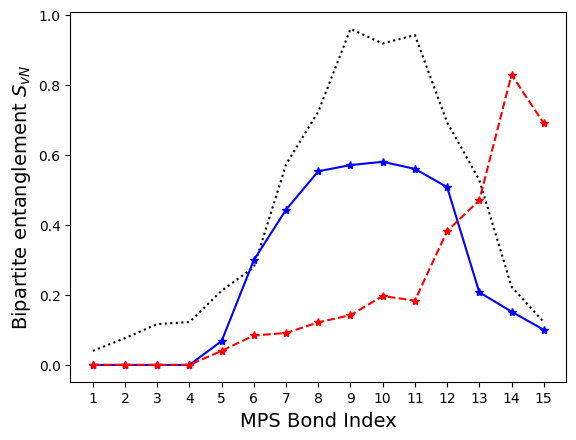

In [13]:
import numpy as np
#hct n

gs_ent = [np.float64(0.04016665527042831),
 np.float64(0.0765279961658846),
 np.float64(0.1164828894700309),
 np.float64(0.12244371912052122),
 np.float64(0.2120332860879524),
 np.float64(0.2786103634673266),
 np.float64(0.572750158659636),
 np.float64(0.7235261641637342),
 np.float64(0.9597285107238281),
 np.float64(0.9181478833098564),
 np.float64(0.9422869768433396),
 np.float64(0.6930623106091608),
 np.float64(0.5283006875300862),
 np.float64(0.2235034119199822),
 np.float64(0.12236014466224443)]

hct_ent = [
     -2.6645352591003863e-15,
-6.6613381477510055e-15,
-5.329070518200794e-15,
-7.105427357601078e-15,
0.06830330005501811,
0.2995298900734087,
0.44353923649133814,
0.5531992438907007,
0.5708036139777047,
0.5801896293014017,
0.5599938122903597,
0.5079068603677719,
0.20737699959718903,
0.1523498764736202,
0.10036561251401009
    ]

#bs n
bs_ent = [
     -4.884981308350724e-15,
-6.217248937900934e-15,
-5.329070518200794e-15,
-6.6613381477510055e-15,
0.040267767338502125,
0.08411981652013767,
0.09125082438872247,
0.12158412650556699,
0.14222721580388994,
0.1965762809674815,
0.18390123990471094,
0.3820629020155069,
0.4704099721489574,
0.8289362328895433,
0.6903029422198314
    ]

import matplotlib.pyplot as plt
x = list(range(1, 16))
xs = np.array(x)
plt.plot(xs, np.array(gs_ent), ':', color="black", label=r'Original')
plt.plot(xs, np.array(hct_ent), '-*', color="blue", label=r'HCT')
plt.plot(xs, np.array(bs_ent), '--*', color="red", label=r'Beam Search')

plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)

x = list(range(1, 16))
plt.xticks(x, x)
#plt.legend()
plt.savefig('./saved/n2frozen_corr_cut_entropy_hct_bs_clean.pdf', dpi=1000)

In [5]:

from openfermion import count_qubits, jordan_wigner, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator

from openfermionpyscf import run_pyscf
from quasisymmetries.state_utils import get_cisd_gs
from quasisymmetries.state_utils import get_hf_wfn, get_hf_occ
import pickle

# bl = 2.2
# geometry = [
#     ('N', (0.0, 0.0, -bl/2)),
#     ('N', (0.0, 0.0, bl/2))
# ]

def h4_rect_geometry(bla, blb):
    return [
        ('H', (-bla/2, -blb/2, 0.0)),
        ('H', (-bla/2, blb/2, 0.0)),
        ('H', (bla/2, -blb/2, 0.0)),
        ('H', (bla/2, blb/2, 0.0))
    ]

def h4_chain_geometry(bl):
    return [
        ('H', (-1.5*bl, 0.0, 0.0)),
        ('H', (-0.5*bl, 0.0, 0.0)),
        ('H', (0.5*bl, 0.0, 0.0)),
        ('H', (1.5*bl, 0.0, 0.0))
    ]

def h4_cube_geometry(bl):
    return [
        ('H', (-0.5*bl, -0.5*bl, -0.5*bl)),
        ('H', (+0.5*bl, -0.5*bl, -0.5*bl)),
        ('H', (-0.5*bl, +0.5*bl, -0.5*bl)),
        ('H', (+0.5*bl, +0.5*bl, -0.5*bl)),
        ('H', (-0.5*bl, -0.5*bl, +0.5*bl)),
        ('H', (+0.5*bl, -0.5*bl, +0.5*bl)),
        ('H', (-0.5*bl, +0.5*bl, +0.5*bl)),
        ('H', (+0.5*bl, +0.5*bl, +0.5*bl))
    ]

def lih_geometry(bl):
    return [
    ('Li', (0.0, 0.0, -bl/2)),
    ('H', (0.0, 0.0, bl/2))
]

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# fci_es = []
# cisd_es = []

bl_list = [0.5 + 0.05*x for x in range(20)]

hf_energies = []
cisd_energies = []
cisd_energies_pyscf = []
fci_energies = []

from quasisymmetries.state_utils import get_cisd_gs, get_hf_occ

hf_occ = get_hf_occ(8, 8, as_str=True)

for bl in bl_list:
    print(bl)
    geometry = h4_cube_geometry(bl)
    # Create molecule object
    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge
    )

    # Run PySCF to compute integrals (no need for correlated methods)
    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_mp2=False,
        run_cisd=True,
        run_ccsd=False,
        run_fci=True
    )

    H = get_fermion_operator(molecule.get_molecular_hamiltonian())
    HQ = jordan_wigner(H)
    n_qubits = count_qubits(H)

    hf_energies.append(molecule.hf_energy)
    cisd_energies_pyscf.append(molecule.cisd_energy)
    #cisd_energies.append(get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')[0])
    fci_energies.append(molecule.fci_energy)
    print(molecule.hf_energy, molecule.fci_energy)

0.5
-0.2553993986378593 -0.309861394578288
0.55
-1.2895777792825562 -1.3496378972281313
0.6
-2.042901205669885 -2.108751337547627
0.65
-2.594460465575427 -2.6662801217188203
0.7
-2.9990201811169257 -3.077011225592482
0.75
-3.2951839776740535 -3.3795929626194727
0.8
-3.5105451754295114 -3.6016766296526885
0.8500000000000001
-3.6650540965676868 -3.7632800676896956
0.9
-3.7732826438917595 -3.8790517720083155
0.95
-3.845982586173493 -3.959829752323339
1.0
-3.8911749838977503 -4.013731332911087
1.05
-3.914917885621799 -4.0469206606767525
1.1
-3.921848083012888 -4.06414985268966
1.15
-3.9155626506021814 -4.069139812450963
1.2000000000000002
-3.898887180543527 -4.06484783177919
1.25
-3.8740648072813055 -4.053656026257764
1.3
-3.8428907300827166 -4.037504918763165
1.35
-3.806809783358128 -4.017988920248385
1.4
-3.766989127731099 -3.9964245523937123
1.4500000000000002
-3.724374053503327 -3.973897865115699


In [8]:
import numpy as np
np.array(fci_energies)

array([-0.30986139, -1.3496379 , -2.10875134, -2.66628012, -3.07701123,
       -3.37959296, -3.60167663, -3.76328007, -3.87905177, -3.95982975,
       -4.01373133, -4.04692066, -4.06414985, -4.06913981, -4.06484783,
       -4.05365603, -4.03750492, -4.01798892, -3.99642455, -3.97389787])

In [9]:
bl = 1.15
geometry = h4_cube_geometry(bl)
# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=True,
    run_ccsd=False,
    run_fci=True
)

H = get_fermion_operator(molecule.get_molecular_hamiltonian())
HQ = jordan_wigner(H)
n_qubits = count_qubits(H)
Hs = get_sparse_operator(HQ, n_qubits)
fci_e, fci_gs = get_ground_state(Hs)

hf_occ = get_hf_occ(8, 8, as_str=True)

cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')

print(bl, fci_e, abs(cisd_e - fci_e))

#H, (fci_e, fci_wfn), (cisd_e, cisd_wfn)
data = (H, fci_e, fci_gs, cisd_e, cisd_wfn)
directory = "./saved/hamiltonians/"
filename = "H8cube_eqm"
with open(directory+filename+".pkl", "wb") as f:
    pickle.dump(data, f)


molecule.filename = directory + filename
molecule.save()
print(fci_e, cisd_e)

1.15 -4.069139812451826 0.013385397844933422
-4.069139812451826 -4.055754414606892


/Users/praveenjayakumar/Jay Family Dropbox/praveen jayakumar/6.To-Fro Praveen/UToronto/codes backup/seniority/QuasiSymmetries/src/state_utils.py:473: ComplexWarning: Casting complex values to real discards the imaginary part
  wfs[iindx] = gs[iidx]


In [10]:
import importlib
import test_mpo_ferm

importlib.reload(test_mpo_ferm)

mpodata = test_mpo_ferm.benchmark_system("H8cube_eqm")


System: H8cube_eqm
Saved FCI energy: -4.069139812451826
FCI determinants retained: 2300
FCI active-space projection norm: 1.0000000000000018

Detected MPO bond-dimension candidates:
  left_operator_names           : 83
  middle_operator_names         : 1
  right_operator_names          : 1

Largest detected MPO bond dimension: 83

OpenFermion -> PyBlock2 MPO summary:
  name                 : H8_sto-3g_singlet
  total spatial orbs   : 8
  frozen core orbs     : []
  active orbitals      : [0, 1, 2, 3, 4, 5, 6, 7]
  active space         : CAS(8e, 8o)
  spin target 2S       : 0
  ecore                : 10.489066507153
  scratch              : /var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/pyblock2_of_mpo_d232mn3i
Matching active-space FCI energy: -4.069139812451788

Testing MPS bond dimension 1

Sweep =    0 | Direction =  forward | Bond dimension =    1 | Noise =  0.00e+00 | Dav threshold =  1.00e-10
Time elapsed =      0.024 | E =      -4.0691398125 | DW = 5.90739e-02

Sweep =    1 |

1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z3 Z5 Z6]  added at threshold 0.020078393915634665 with metric value  0.06818276368593015
1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z3 Z5 Z6]  added at threshold 0.020078393915634665 with metric value  0.06818276368593015
1.0 [Z0 Z1 Z4 Z7]  added at threshold 0.03861576966081301 with metric value  0.43288125054489696
1.0 [Z1]  added at threshold 0.04370932203524808 with metric value  0.31291682805699683
1.0 [Z0]  added at threshold 0.04370932203524808 with metric value  0.31291682805699694
1.0 [Z7]  added at threshold 0.04735193178193198 with metric value  0.31831017105633286

Beam Search (16) with exact-symmetry seeding:
Starti

/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_75273/3776312065.py:75: DeprecationWarning: find_commuting_symmetry_generators is deprecated; use BeamSearch_Symmetries instead.
  sym_bs_N = find_commuting_symmetry_generators(


Adding HCT symmetries to the pool:
1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z3 Z5 Z6]  added at threshold 0.020078393915634665 with metric value  1.8558791958109024
1.0 [Z0 Z1 Z4 Z7]  added at threshold 0.03861576966081301 with metric value  2.9172295897474454
1.0 [Z1]  added at threshold 0.04370932203524808 with metric value  2.3399645236792677
1.0 [Z0]  added at threshold 0.04370932203524808 with metric value  2.3399645236792677
1.0 [Z7]  added at threshold 0.04735193178193198 with metric value  2.38505936719666
BS N/2 Comm
DMRG converged at bond dimension: 4
BS N Comm
DMRG converged at bond dimension: 4
HCT N/2 Comm
DMRG converged at bond dimension: 3
HCT N Comm
DMRG converged at bond dimension: 3
SEN N/2 Comm
DMRG converged at bond dimension: 4
DMRG converged at bond dimension: 10


NameError: name 'bd_rows' is not defined

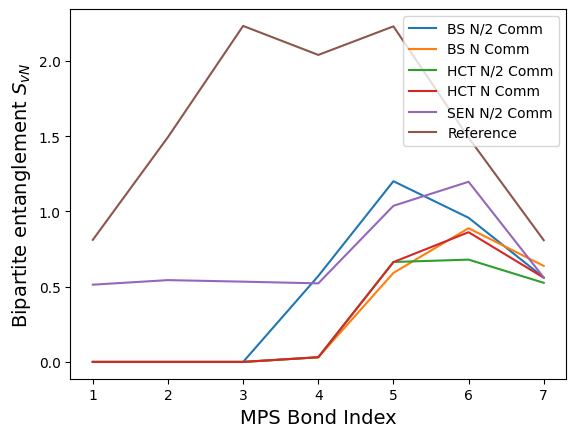

In [ ]:
#run and benchmark H8cube_3A


import pickle

import pandas as pd
from openfermion import count_qubits, jordan_wigner, get_sparse_operator, MolecularData
from quasisymmetries.bs.beam import find_commuting_symmetry_generators
from quasisymmetries.metrics import comm_sq_exp_fast, variance
from quasisymmetries.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod, bs_hct
from quasisymmetries.benchmark import BenchmarkData, benchmark_syms

directory = "./saved/hamiltonians/"

system= "H4chain_corr"

date="_JUNE28" #to keep track of outputs
cost_func_tag = '_nc_exp_cisd'
output_filename = "./saved/" + cost_func_tag + date
with open(output_filename, 'a') as f:
    print('\n\n' + system, file=f)

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=directory + system)

H, fci_e, fci_gs, cisd_e, cisd_gs = data
HQ = jordan_wigner(H)
n_qubits = count_qubits(H)
Hs = get_sparse_operator(HQ, n_qubits)

from quasisymmetries.sym import hct_mod
from quasisymmetries.bs.beam import BeamSearch_Symmetries

#define cost function
comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_group_var_func = lambda s_list: (-1)*var_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

cf_dict = {'Comm': sym_group_score_func, 'Var' : sym_group_var_func, '1-norm': None}

#make symmetries
bw=16 # beam width for bs-hct and bs
sym_hct_N_2, eps = hct_mod(HQ, n_qubits//2, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
sym_hct_N, eps = hct_mod(HQ, n_qubits, use_coeffs_eps=True, sym_metric_func=sym_metric_func)

#bliss cost function
n_elec = molecule.n_electrons if system[:2] != 'N2' else molecule.n_electrons - 4 # 4 frozen for N2
print(n_elec)
print("Starting spin-restricted BLISS routine...")
H_bliss, bliss_info = lp_bliss_paper_real_pauli_1norm(
    H,
    n_electrons=n_elec,
    n_orb=n_qubits,
)
print("Pauli BLISS completed, Relative Pauli L1 reduction: {}".format(bliss_info["relative_pauli_l1_reduction"]))
HQ_bliss = jordan_wigner(H_bliss)
sym_hct_bliss, eps_bliss = hct_mod(HQ_bliss, n_qubits, sym_metric_func= sym_metric_func, use_coeffs_eps=True)

# seniority
print("Seniority symmetries:")
sym_sen = get_seniority_symmetries(n_qubits)
print(sym_sen)

#beam search
print("\nBeam Search ({}) with exact-symmetry seeding:".format(bw))
cost_function =  'Comm'
print(f'Starting cost function: {cost_function}')
sym_bs_N_2 = BeamSearch_Symmetries(
    HQ,
    target_rank=n_qubits//2,
    beam_width=bw,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    score_func= cf_dict[cost_function], # this function maximizes the cost function TODO invert this
    include_hct_symmetries = True,
    hct_n_sym = n_qubits//2,
    hct_use_coeffs_eps = True,
)

sym_bs_N = BeamSearch_Symmetries(
    HQ,
    target_rank=n_qubits,
    beam_width=bw,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    score_func= cf_dict[cost_function], # this function maximizes the cost function TODO invert this
    include_hct_symmetries = True,
    hct_n_sym = n_qubits,
    hct_use_coeffs_eps = True,
)

datasets = []
verbose = True
datasets.append(benchmark_syms(sym_bs_N_2, HQ, fci_gs, fci_e, 
                                n_qubits, N_2_sym=True, print_to_file=output_filename, 
                                tag="BS N/2" + f" {cost_function}", verbose = verbose))

bs_N_data, bs_N_processed_data = benchmark_syms(sym_bs_N, HQ, fci_gs, fci_e, 
                                n_qubits, N_2_sym=False, print_to_file=output_filename, 
                                tag="BS N" + f" {cost_function}",verbose = verbose, return_processed_data=True)

datasets.append(bs_N_data)

datasets.append(benchmark_syms(sym_hct_N_2, HQ, fci_gs, fci_e,
                                        n_qubits, N_2_sym=True, print_to_file=output_filename,
                                        tag="HCT N/2" + f" {cost_function}", verbose=verbose))

hct_N_data, hct_N_processed_data = benchmark_syms(sym_hct_N, HQ, fci_gs, fci_e,
                                n_qubits, N_2_sym=False, print_to_file=output_filename,
                                tag="HCT N" + f" {cost_function}", verbose=verbose, return_processed_data=True)

datasets.append(hct_N_data)

datasets.append(benchmark_syms(sym_sen, HQ, fci_gs, fci_e,
                                n_qubits, N_2_sym=True, print_to_file=output_filename,
                                tag="SEN N/2" + f" {cost_function}", verbose=verbose))

datasets.append(benchmark_syms(sym_hct_bliss, HQ, fci_gs, fci_e,
                                n_qubits, N_2_sym=False, print_to_file=output_filename,
                                tag=r"Pauli BLISS+HCT($n_q$)", verbose=verbose))


save_filename = output_filename + system + "_datasets"
BenchmarkData.save_datasets(datasets, save_filename)

#analysis
#entropy graphs
_ = BenchmarkData.plot_cut_entropies(datasets, fci_gs, output_filename + system + "_cutentropy.png")

#dmrg bds
#un rotated DMRG (as paulis)
compress_cutoff = 1e-20
import quimb.tensor as qtn
from quasisymmetries.tn import find_dmrg_conv_bd_quimb
gs_mps = qtn.MatrixProductState.from_dense(fci_gs, cutoff = compress_cutoff)     
dmrg_bd, _ = find_dmrg_conv_bd_quimb(HQ, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                    reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                    noise = 1e0, bsz=2, guess_mps = gs_mps, seed=0)

cols = ["system"] + ["Original"] + [data.tag for data in datasets]
bd_rows.append(dict(zip(cols, [system] + [dmrg_bd] + [data.dmrg_bd for data in datasets])))
df = pd.DataFrame(bd_rows)
df.to_csv(output_filename + "_dmrg_bd.csv", index=False)


#fiedler reordering for symmetries
def do_fiedler_analysis(syms, HQ, gs, n_qubits, log_base=np.e, verbose=True, write_to_file=False, filename=None):
    ent_reord, H_reord, psi_reord, fiedler_info = do_fiedler_reordering(HQ, gs, n_qubits=n_qubits, verbose=verbose, log_base=log_base)

    syms_reordered = [syms[i] for i in fiedler_info["ordering"]]
    if write_to_file:
        with open(output_filename, 'a') as f:
            print("\nReordered symmetries:\n", file=f)
            for i, sym in enumerate(syms_reordered):
                print("Site {}: {}".format(i+1, sym), file=f)  

        with open(output_filename, 'a') as f:
            print("\nEntanglement after Fiedler reordering:\n", file=f)
            for i, e in enumerate(ent_reord):
                print("{}|{}: {}".format(i+1, i+2, e), file=f)
    #reorder bond dimension

    if verbose:
        print("\nReordered symmetries:\n")
        for i, sym in enumerate(syms_reordered):
            print("Site {}: {}".format(i+1, sym))  
        
        print("\nEntanglement after Fiedler reordering:\n")
        for i, e in enumerate(ent_reord):
            print("{}|{}: {}".format(i+1, i+2, e))


    gs_rot_mps = qtn.MatrixProductState.from_dense(psi_reord, cutoff = 1e-20)     
    dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_reord, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                        reps=1, verbose=False, compress_cutoff = 1e-20, sweep_tol = 1e-6,
                        noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)
    print("Rotated, permuted reordered BD:", dmrg_bd)

with open(output_filename, 'a') as f:
    print("DMRG bond dimension for convergence: {} (before reordering: {})".format(dmrg_bd, data[1].dmrg_bd), file=f)

In [2]:
HQ

NameError: name 'HQ' is not defined

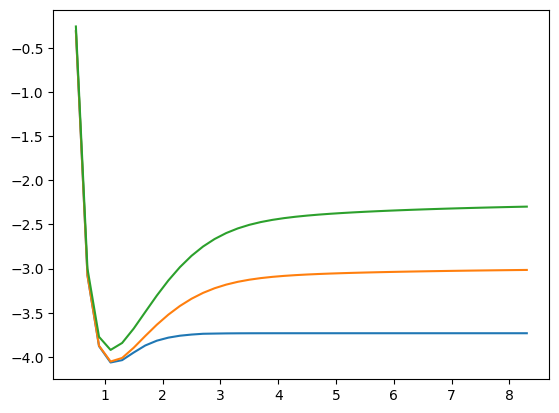

In [270]:
import matplotlib.pyplot as plt

plt.plot(bl_list, fci_energies)
plt.plot(bl_list, cisd_energies_pyscf)
plt.plot(bl_list, hf_energies)

In [ ]:
from quasisymmetries.benchmark import BenchmarkData

import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits
from quasisymmetries.mpo import build_qc_mpo_from_openfermion_molecule

directory = "./saved/hamiltonians/"
system = "N2frozen_corr"

is_n2 = True if system[:2] == 'N2' else False
        
filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)
n_qubits = count_qubits(H)

data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))
print("Importing {} symmetries:".format(data[1].tag))
syms = data[1].symmetries
print(syms)

from quasisymmetries.metrics import get_entropies_at_cuts, z_
gs_ent = get_entropies_at_cuts(fci_gs, n_qubits, 'e')
bs_ent, H_perm, gs_rot = get_permuted_bipartite_entanglement(syms, HQ, n_qubits, fci_e, fci_gs, return_state=True, log_base='e', verbose=True)


Importing BS N Comm symmetries:
[1.0 [Z0 Z3 Z4 Z7 Z9 Z10 Z12 Z15], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13 Z15], 1.0 [Z2 Z3 Z10 Z11 Z12 Z13 Z14 Z15], 1.0 [Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13], 1.0 [Z3], 1.0 [Z1 Z3 Z5 Z15], 1.0 [Z2 Z3], 1.0 [Z1], 1.0 [Z0], 1.0 [Z5], 1.0 [Z4], 1.0 [Z6 Z10], 1.0 [Z7 Z11], 1.0 [Y7 Z8 X9 X11 Z12 Y13], 1.0 [Z6], 1.0 [Z8]]
Symmetries rotated to Z on qubits:  [0, 1, 2, 6, 3, 7, 10, 5, 4, 15, 14, 8, 9, 11, 12, 13]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 4
4 -> 8
5 -> 7
6 -> 3
7 -> 5
8 -> 11
9 -> 12
10 -> 6
11 -> 13
12 -> 14
13 -> 15
14 -> 10
15 -> 9
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : 6.661338147750933e-16
2 | 3 : -4.440892098500629e-16
3 | 4 : -5.329070518200794e-15
4 | 5 : -7.105427357601078e-15
5 | 6 : 0.0402677673385021
6 | 7 : 0.08411981652013749
7 | 8 : 0.0912508243887236
8 | 9 : 0.12158412650556778
9 | 10 : 0.14222721580388975
10 | 11 : 0.19657628096748095
11 | 12 : 0.18390123990471172
12 | 13 : 0.3820629020155

In [224]:
from fcidump_pyblock2 import run_pyblock2_dmrg_from_fcidump

result = run_pyblock2_dmrg_from_fcidump(
    "../Fe2S2_10e10o/fe2s2_10e10o",
    max_bond_dim=500,
    n_sweeps=50,
    n_threads=4,
    seed=1,
)

print(result["energy"])

symmetrize error =  0.0
integral cutoff error =  0.0
mpo terms =       6150

Build MPO | Nsites =    10 | Nterms =       6150 | Algorithm = FastBIP | Cutoff = 1.00e-20
 Site =     0 /    10 .. Mmpo =    14 DW = 0.00e+00 NNZ =       14 SPT = 0.0000 Tmvc = 0.001 T = 0.010
 Site =     1 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =      179 SPT = 0.6956 Tmvc = 0.001 T = 0.004
 Site =     2 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      346 SPT = 0.8713 Tmvc = 0.001 T = 0.004
 Site =     3 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =      573 SPT = 0.9048 Tmvc = 0.001 T = 0.004
 Site =     4 /    10 .. Mmpo =   132 DW = 0.00e+00 NNZ =      803 SPT = 0.9353 Tmvc = 0.001 T = 0.003
 Site =     5 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =     2791 SPT = 0.7751 Tmvc = 0.001 T = 0.005
 Site =     6 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      573 SPT = 0.9048 Tmvc = 0.000 T = 0.003
 Site =     7 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =      349 SPT = 0.8702 Tmvc = 0.000 T = 0.001
 Site = 

In [237]:
from fcidump_openfermion import (
    molecular_data_from_fcidump,
    fermion_operator_from_fcidump,
)

fcidump_path = "../Fe2S2_10e10o/fe2s2_10e10o"

mol = molecular_data_from_fcidump(fcidump_path)
fermion_op = fermion_operator_from_fcidump(fcidump_path)

print(mol.n_orbitals, mol.n_qubits, mol.n_electrons)
#print(fermion_op)
from openfermion import jordan_wigner
HQ = jordan_wigner(fermion_op)
from quasisymmetries.sym import hct_mod

hct_syms, eps = hct_mod(HQ, 20, use_coeffs_eps=False, num_intervals=1000)

10 20 10
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13 Z15 Z17 Z19]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12 Z14 Z16 Z18]  added at threshold 0.0 with metric value  0.0
1.0 [Z13]  added at threshold 0.13137371254060526 with metric value  9.459147176339073
1.0 [Z12]  added at threshold 0.13137371254060526 with metric value  9.459147176339073
1.0 [Z15]  added at threshold 0.13137371254060526 with metric value  9.473987245821242
1.0 [Z14]  added at threshold 0.13137371254060526 with metric value  9.473987245821242
1.0 [Z18]  added at threshold 0.13137371254060526 with metric value  9.528438269071312
1.0 [Z19]  added at threshold 0.13137371254060526 with metric value  9.528438269071314
1.0 [Z7]  added at threshold 0.13137371254060526 with metric value  9.539345288322725
1.0 [Z6]  added at threshold 0.13137371254060526 with metric value  9.539345288322725
1.0 [Z5]  added at threshold 0.13137371254060526 with metric value  9.57570914524836
1.0 [Z4]  added at threshold 0.13137

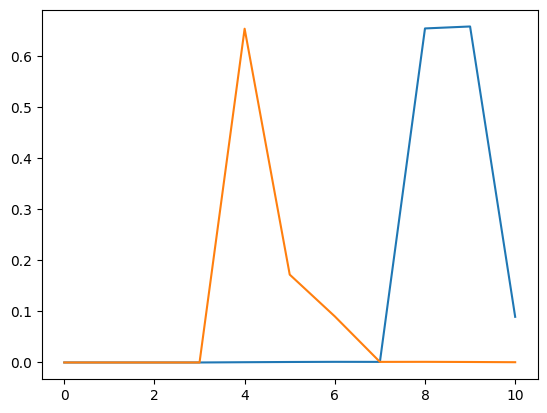

In [201]:
import numpy as np

arr1 = np.array([
    5.551115123125736e-15,
    5.551115123125736e-15,
    5.551115123125736e-15,
    5.551115123125736e-15,
    0.0005152412854547677,
    0.0009653361991050379,
    0.0012669827456232947,
    0.0011645506613509311,
    0.6541454696083271,
    0.6579883717181625,
    0.08940573097154775,
])

arr2 = np.array([
    5.995204332975791e-15,
    5.995204332975791e-15,
    5.995204332975791e-15,
    5.995204332975791e-15,
    0.6535969995233348,
    0.1720877056939767,
    0.09024534231987026,
    0.0011645506613509303,
    0.0012669827456237397,
    0.0009653361991050386,
    0.0005152412854547844,
])

import matplotlib.pyplot as plt
plt.plot(arr1)
plt.plot(arr2)

In [4]:
### testing iqcc generators
from quasisymmetries.qcc import IterativeQCC
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits
from quasisymmetries.mpo import build_qc_mpo_from_openfermion_molecule
import numpy as np

directory = "./saved/hamiltonians/"
system = "H2O_corr"

is_n2 = True if system[:2] == 'N2' else False
        
filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)
n_qubits = count_qubits(H)

from quasisymmetries.state_utils import get_hf_occ
import tequila as tq

occ = get_hf_occ(mol.n_electrons, mol.n_orbitals, as_str=False)
Hq= tq.QubitHamiltonian.from_openfermion(HQ)
iQCC =IterativeQCC(Hq, ref_occs=np.array(occ))

iQCC.do_iteration(15, maxiter=500)
generators = iQCC.generators

for gen in generators:
    print(gen)

assert False

#load symmetries
from quasisymmetries.benchmark import BenchmarkData
from quasisymmetries.metrics import get_permuted_bipartite_entanglement
data = BenchmarkData.load_datasets('./saved/results/MAY27/_nc_exp_cisd_MAY27{}_datasets'.format(system))
import numpy as np
print("Importing {} symmetries:".format(data[1].tag))
syms = data[1].symmetries
log_base = np.e
ents_rotated, H_perm, gs_rot = get_permuted_bipartite_entanglement(syms, HQ, n_qubits, fci_e, fci_gs, return_state=True, log_base=log_base, verbose=True)
Hq_perm= tq.QubitHamiltonian.from_openfermion(H_perm)
occ_rot = [int(a) for a in significant_determinants(gs_rot, 1e-2)[0][0]]
iQCC_trans =IterativeQCC(Hq_perm, ref_occs=np.array(occ_rot))

iQCC_trans.do_iteration(15, maxiter=500)
generators_trans = iQCC_trans.generators

for gen in generators_trans:
    print(gen)
#transform Hamiltonian


#solve iqcc for transformed Hamiltonian





Gradient partitions:
[0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1.] : 0.21110844200145135
[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0.] : 0.20838286117061486
[0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0.] : 0.1860393015277925
[0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1.] : 0.1860393015277925
[0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0.] : 0.1008271847173204
[0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1.] : 0.1008271847173204
[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1.] : 0.09094615185023125
[0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.] : 0.0880149969069395
[0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1.] : 0.08521211681047208
[0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0.] : 0.08521211681047208
[0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.] : 0.0817328103535966
[0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0.] : 0.08162870080976564
[0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0.] : 0.02537657861471998
[0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1.] : 0.02347726003116107
[1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.] : 0.018449120745

KeyboardInterrupt: 

In [7]:
from openfermion import FermionOperator
jordan_wigner(FermionOperator('11^ 10^ 9 8') + FermionOperator('8^ 9^ 10 11'))

(-0.125+0j) [X8 X9 X10 X11] +
(0.125+0j) [X8 X9 Y10 Y11] +
(-0.125+0j) [X8 Y9 X10 Y11] +
(-0.125+0j) [X8 Y9 Y10 X11] +
(-0.125+0j) [Y8 X9 X10 Y11] +
(-0.125+0j) [Y8 X9 Y10 X11] +
(0.125+0j) [Y8 Y9 X10 X11] +
(-0.125+0j) [Y8 Y9 Y10 Y11]

In [190]:
occ_rot = [int(a) for a in significant_determinants(gs_rot, 1e-2)[0][0]]
iQCC_trans =IterativeQCC(Hq_perm, ref_occs=np.array(occ_rot))

iQCC_trans.do_iteration(5)
generators_trans = iQCC_trans.generators

for gen in generators_trans:
    print(gen)


Gradient partitions:
[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0.] : 0.09493737708177817
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.] : 0.09493737708177817
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.] : 0.06901296920945472
[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.] : 0.018573332927860665
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] : 0.018573332927860665
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.] : 0.01549828244783065
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.] : 0.012873978245194002
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1.] : 0.012873978245194002
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.] : 0.012301739306494601
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] : 0.012301739306494601
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.] : 0.00976689621578271
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] : 0.009766896215782707
[0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.] : 0.009516177901071702
[0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0.] : 0.009516177901071702
[0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.] : 0.0095161779010717
[0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0.] : 0.0095161779010717
[0. 0. 0. 0

In [208]:
fci_e

np.float64(-1.8977806459898654)

In [72]:
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits
from quasisymmetries.mpo import build_qc_mpo_from_openfermion_molecule

directory = "./saved/hamiltonians/"
system = "H2O_corr"

is_n2 = True if system[:2] == 'N2' else False
        
filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)
mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)
n_qubits = count_qubits(H)
print(fci_e)

from quasisymmetries.tn import MPO_from_QubitOperator

ncore = 2 if is_n2 else 0
#fermionic space mpo
out = build_qc_mpo_from_openfermion_molecule(
    mol,
    ncore=ncore,       # e.g. N2/STO-3G frozen core
    iprint=0
)

driver = out["driver"]
mpo = out["mpo"]
print("Largest MPO bond dimension:", out["largest_mpo_bond_dim"])
#system_bond_sizes["fermionic"] = out["largest_mpo_bond_dim"]



# 4. Set DMRG parameters
# Bond dimensions and noise schedules
bond_dims = [30, 40, 50]
n_sweeps = 50
noises=[1e-2, 1e-2, 1e-3, 1e-3, 1e-4, 1e-4, 1e-5, 1e-5, 1e-6, 1e-6] + [0.0]*(n_sweeps - 10)
thrds=[1e-10] * n_sweeps

# 5. Run the DMRG sweep
for bd in bond_dims:
    ket = driver.get_random_mps(tag="KET", bond_dim=bd, nroots=1)
    energy = driver.dmrg(mpo, ket, n_sweeps=n_sweeps, noises=noises, thrds=thrds, dav_max_iter=50, iprint=1)
    print(energy)
    print(abs(energy - fci_e) <=1.6e-3)


-74.7537908684033

Detected MPO bond-dimension candidates:
  left_operator_names           : 53
  middle_operator_names         : 1
  right_operator_names          : 1

Largest detected MPO bond dimension: 53

OpenFermion -> PyBlock2 MPO summary:
  name                 : H2-O1_sto-3g_singlet
  total spatial orbs   : 7
  frozen core orbs     : []
  active orbitals      : [0, 1, 2, 3, 4, 5, 6]
  active space         : CAS(10e, 7o)
  spin target 2S       : 0
  ecore                : 4.191174080345
  scratch              : /var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/pyblock2_of_mpo_3cuixaau
Largest MPO bond dimension: 53

Sweep =    0 | Direction =  forward | Bond dimension =   30 | Noise =  1.00e-02 | Dav threshold =  1.00e-10
Time elapsed =      0.036 | E =    -123.6893163445 | DW = 8.99183e-08

Sweep =    1 | Direction = backward | Bond dimension =   30 | Noise =  1.00e-02 | Dav threshold =  1.00e-10
Time elapsed =      0.056 | E =    -123.6893163445 | DE = -1.63e-12 | DW = 5.00255

In [22]:
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits, get_sparse_operator, QubitOperator
from quasisymmetries.metrics import comm_sq_exp_fast

directory = "./saved/hamiltonians/"

system = 'N2frozen_eqm'

filename = directory+system 
with open(filename+".pkl", "rb") as f:
    data = pickle.load(f)

mol = MolecularData(filename=filename)
H, fci_e, fci_gs, cisd_e, cisd_gs = data

HQ = jordan_wigner(H)
n_qubits = count_qubits(H)

print(mol.orbital_energies)


Hs = get_sparse_operator(H)
print(comm_sq_exp_fast([QubitOperator('Y7 Z8 X9 X11 Z12 Y13', 1.0)], Hs, cisd_gs, n_qubits))
print(comm_sq_exp_fast([QubitOperator('Y4 X5 X14 Y15', 1.0)], Hs, cisd_gs, n_qubits))
#print(comm_sq_exp_fast([QubitOperator('Y7 X9 X11 Y13', 1.0)], Hs, cisd_gs, n_qubits))
#print(comm_sq_exp_fast([QubitOperator('X8 Y10 Y12 X14', 1.0)], Hs, cisd_gs, n_qubits))

/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_3378/2167680211.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


[-15.48822058 -15.48754967  -1.34941056  -0.73702747  -0.51365167
  -0.50734273  -0.50734273   0.2386207    0.2386207    0.90788255]
0.6195432721370748
4.501131668893594


In [21]:
print(comm_sq_exp_fast([QubitOperator('Z12 Z13', 1.0)], Hs, cisd_gs, n_qubits))
print(comm_sq_exp_fast([QubitOperator('Z8 Z9', 1.0)], Hs, cisd_gs, n_qubits))
print(comm_sq_exp_fast([QubitOperator('Z8 Z9 Z12 Z13', 1.0)], Hs, cisd_gs, n_qubits))

0.005688743151784178
0.005688743151784039
4.34458266766772e-06


In [47]:
from pyscf import tools

fcidump_fe2s2 = tools.fcidump.read('../Fe2S2_10e10o/fe2s2_10e10o')


Parsing ../Fe2S2_10e10o/fe2s2_10e10o


In [86]:
from openfermion import QubitOperator
from quasisymmetries.metrics import variance, comm_sq_exp_fast
from scipy.optimize import minimize

constraint = {
    "type": "ineq",
    "fun": lambda x: 1 - x[0]**2 - x[1]**2 - 1e-5
}

def cost(x):
    a, b = x[0], x[1]

    return variance([np.sqrt(1 - a**2 - b**2) * QubitOperator('Z3') + a*QubitOperator('X3') + b*QubitOperator('Y3')], psi_reord, n_qubits, False)

idx = 7
def cost2(x):
    a, b = x[0], x[1]

    print((1 - a**2 - b**2))
    return comm_sq_exp_fast([np.sqrt(1 - a**2 - b**2) * QubitOperator('Z{}'.format(idx)) + a*QubitOperator('X{}'.format(idx)) + b*QubitOperator('Y{}'.format(idx))], get_sparse_operator(H_perm_reord), psi_reord, n_qubits, False)


res = minimize(cost2, x0=[0, 0], method="SLSQP", constraints=[constraint])
print(res.x)
print(res.success)

1.0
0.9999999999999998
0.9999999999999998
0.9992234034056079
0.9992234042361234
0.9992234034056078
[-2.78674827e-02 -6.98491931e-09]
True


In [78]:
x = res.x
a, b = x[0], x[1]

S = np.sqrt(1 - a**2 - b**2) * QubitOperator('Z3') + a*QubitOperator('X3') + b*QubitOperator('Y3')
print(S)

0.017726768459158798 [X3] +
0.9998428684948427 [Z3]


In [77]:
print(res.fun)
print(cost2([0, 0]))

1.1205357890785155
1.1218063479440052


In [52]:
from quasisymmetries.fiedler import invert_ordering
perm_new = info["ordering"]
bs_syms_reord = [bs_syms[i] for i in perm_new]
print(bs_syms_reord)
bd_bs_perm = benchmark_syms(bs_syms_reord, HQ, fci_gs, fci_e, n_qubits)

[1.0 [Z0 Z3 Z4 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z2 Z3 Z6 Z7], 1.0 [Z0 Z5 Z6], 1.0 [Y0 Z1 Y2 Y4 Z5 Y6], 1.0 [X1 X2 X5 X6], 1.0 [Z7], 1.0 [Z0 Z3 Z5 Z6]]

Non commutative l1:  17.255086331503513
9/185 Terms in H found to commute with all symmetries.
Symmetries rotated to Z on qubits:  [0, 1, 2, 3, 4, 5, 7, 6]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 7
7 -> 6
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : 4.662936703425624e-15
2 | 3 : 4.662936703425624e-15
3 | 4 : 4.662936703425624e-15
4 | 5 : 0.6369942418032755
5 | 6 : 1.188606526136741
6 | 7 : 1.1263243746720197
7 | 8 : 0.6928791230323392
DMRG converged at bond dimension: 9


In [ ]:
### orbital rotation optimization with DMRG low bond dimension starting point

import copy
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize

from openfermion import FermionOperator, hermitian_conjugated, normal_ordered
from openfermion.transforms import get_interaction_operator, jordan_wigner


from quasisymmetries.tn import find_dmrg_conv_bd_quimb

import pickle
import quimb.tensor as qtn
import numpy as np
from openfermion import count_qubits, jordan_wigner, MolecularData, get_sparse_operator
from quasisymmetries.state_utils import get_hf_wfn, get_hf_occ
from quasisymmetries.metrics import get_permuted_bipartite_entanglement, comm_sq_exp_fast, get_entropies_at_cuts
from quasisymmetries.sym import get_seniority_symmetries, hct_mod
from quasisymmetries.bliss import lp_bliss_paper_real_pauli_1norm
from quasisymmetries.benchmark import benchmark_syms, BenchmarkData
import pandas as pd
from quasisymmetries.fiedler import fiedler_order_from_state, reorder_statevector_axes
from quasisymmetries.bs.beam import find_commuting_symmetry_generators

import numpy as np
from pyblock2.driver.core import DMRGDriver, SymmetryTypes
from quasisymmetries.tn import MPO_from_QubitOperator


def _pauli_dense_from_qubit_term(term, coeff, n_qubits):
    """
    Build a dense matrix for one OpenFermion QubitOperator term.

    term example:
        ((0, 'Z'), (3, 'X'))

    This returns:
        where, dense_operator_on_contiguous_support

    We use contiguous support because JW strings create long Z chains.
    """
    paulis = {
        "I": np.eye(2, dtype=complex),
        "X": np.array([[0, 1], [1, 0]], dtype=complex),
        "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
        "Z": np.array([[1, 0], [0, -1]], dtype=complex),
    }

    if len(term) == 0:
        return (), complex(coeff) * np.ones((1, 1), dtype=complex)

    sites = [i for i, _ in term]
    lo, hi = min(sites), max(sites)
    where = tuple(range(lo, hi + 1))

    op_map = {i: p for i, p in term}
    mat = np.array([[1.0 + 0.0j]])

    for site in where:
        mat = np.kron(mat, paulis[op_map.get(site, "I")])

    return where, complex(coeff) * mat
def local_expectation_compat(mps, mat, where):
    """
    Compute <mat_where> for a quimb MPS using the newer
    compute_local_expectation API.

    mat acts on the contiguous sites in `where`.
    """
    terms = {tuple(where): mat}

    try:
        return mps.compute_local_expectation(
            terms,
            normalized=True,
            return_all=False,
            method="canonical",
        )
    except TypeError:
        return mps.compute_local_expectation(
            terms,
            return_all=False,
            method="canonical",
        )


def quimb_expect_fermion_operator(
    mps,
    fop,
    n_qubits,
    cutoff=1e-12,
):
    """
    Compute <mps| fop |mps> by JW-transforming each FermionOperator term.
    """
    qop = jordan_wigner(normal_ordered(fop))
    total = 0.0 + 0.0j

    for qterm, coeff in qop.terms.items():
        if abs(coeff) < cutoff:
            continue

        where, mat = _pauli_dense_from_qubit_term(qterm, coeff, n_qubits)

        if where == ():
            total += mat[0, 0]
            continue

        total += local_expectation_compat(mps, mat, where)

    return total


def compute_rdms_from_quimb_mps(
    mps,
    n_orbs,
    cutoff=1e-12,
    verbose=False,
):
    gamma1 = np.zeros((n_orbs, n_orbs), dtype=complex)
    gamma2 = np.zeros((n_orbs, n_orbs, n_orbs, n_orbs), dtype=complex)

    for p in range(n_orbs):
        for q in range(n_orbs):
            op = FermionOperator(((p, 1), (q, 0)), 1.0)
            gamma1[p, q] = quimb_expect_fermion_operator(
                mps,
                op,
                n_orbs,
                cutoff=cutoff,
            )

    for p in range(n_orbs):
        if verbose:
            print(f"2-RDM p={p + 1}/{n_orbs}")

        for q in range(n_orbs):
            for r in range(n_orbs):
                for s in range(n_orbs):
                    op = FermionOperator(
                        ((p, 1), (q, 1), (r, 0), (s, 0)),
                        1.0,
                    )
                    gamma2[p, q, r, s] = quimb_expect_fermion_operator(
                        mps,
                        op,
                        n_orbs,
                        cutoff=cutoff,
                    )

    return gamma1, gamma2

def pack_kappa(K):
    """
    Pack upper-triangular entries of a real antisymmetric matrix K.
    """
    n = K.shape[0]
    return np.array([K[i, j] for i in range(n) for j in range(i + 1, n)])


def unpack_kappa(x, n):
    """
    Build real antisymmetric K from packed upper-triangular parameters.
    """
    K = np.zeros((n, n), dtype=float)
    k = 0
    for i in range(n):
        for j in range(i + 1, n):
            K[i, j] = x[k]
            K[j, i] = -x[k]
            k += 1
    return K

from openfermion import InteractionRDM

def interaction_energy(io, gamma1, gamma2):
    """
    Energy using OpenFermion's own InteractionRDM convention.

    gamma1[p, q] = <a†_p a_q>
    gamma2[p, q, r, s] = <a†_p a†_q a_r a_s>
    """
    rdm = InteractionRDM(
        one_body_tensor=gamma1,
        two_body_tensor=gamma2,
    )
    return float(np.real_if_close(rdm.expectation(io)).real)

import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize

from openfermion import normal_ordered
from openfermion.transforms import get_interaction_operator


def unpack_kappa(x, n):
    """
    Build real antisymmetric K from packed upper-triangular parameters.
    """
    K = np.zeros((n, n), dtype=float)

    k = 0
    for i in range(n):
        for j in range(i + 1, n):
            K[i, j] = x[k]
            K[j, i] = -x[k]
            k += 1

    return K


def rotate_one_rdm(gamma1, U):
    """
    Rotate 1-RDM.

    gamma1[p, q] = <a†_p a_q>

    Returns:
        gamma1_rot[p, q]
    """
    return np.einsum(
        "pa,ab,qb->pq",
        U,
        gamma1,
        U,
        optimize=True,
    )


def rotate_two_rdm(gamma2, U):
    """
    Rotate 2-RDM.

    gamma2[p, q, r, s] = <a†_p a†_q a_r a_s>

    Returns:
        gamma2_rot[p, q, r, s]
    """
    x = np.einsum("pa,abcd->pbcd", U, gamma2, optimize=True)
    x = np.einsum("qb,pbcd->pqcd", U, x, optimize=True)
    x = np.einsum("rc,pqcd->pqrd", U, x, optimize=True)
    x = np.einsum("sd,pqrd->pqrs", U, x, optimize=True)

    return x


def energy_from_rotated_rdms(
    h1,
    h2,
    ecore,
    gamma1,
    gamma2,
    U,
    use_transpose=False,
):
    """
    Evaluate energy by rotating the RDMs and contracting with fixed integrals.

    If the result does not match your validated Hamiltonian-rotation result,
    try use_transpose=True.
    """
    Ur = U.T if use_transpose else U

    gamma1_rot = rotate_one_rdm(gamma1, Ur)
    gamma2_rot = rotate_two_rdm(gamma2, Ur)

    e = ecore
    e += np.einsum("pq,pq->", h1, gamma1_rot, optimize=True)
    e += np.einsum("pqrs,pqrs->", h2, gamma2_rot, optimize=True)

    return float(np.real_if_close(e).real)

def optimize_orbital_rotation_rdm_scheme(
    fermion_hamiltonian,
    gamma1,
    gamma2,
    maxiter=200,
    gtol=1e-8,
    method="BFGS",
    n_random_starts=0,
    random_scale=1e-2,
    seed=None,
    use_transpose=False,
    callback=None,
    verbose=False,
):
    """
    Optimize U = exp(K), with K real antisymmetric, using fixed Hamiltonian
    tensors and rotated RDMs.

    Parameters
    ----------
    fermion_hamiltonian:
        OpenFermion FermionOperator convertible to InteractionOperator.

    gamma1:
        1-RDM, gamma1[p, q] = <a†_p a_q>.

    gamma2:
        2-RDM, gamma2[p, q, r, s] = <a†_p a†_q a_r a_s>.

    n_random_starts:
        Number of random starts in addition to the zero start.

    random_scale:
        Standard deviation for random K parameters.

    use_transpose:
        Switches U -> U.T in the RDM rotation. Use whichever validates
        against your original K=0 / Hamiltonian-rotation convention.

    Returns
    -------
    best:
        scipy OptimizeResult with extra fields:
            best.K
            best.U
            best.energy
            best.all_results
            best.h1
            best.h2
            best.ecore
    """
    io = get_interaction_operator(normal_ordered(fermion_hamiltonian))

    ecore = io.constant
    h1 = np.asarray(io.one_body_tensor)
    h2 = np.asarray(io.two_body_tensor)

    n_orbs = h1.shape[0]
    n_params = n_orbs * (n_orbs - 1) // 2

    gamma1 = np.asarray(gamma1)
    gamma2 = np.asarray(gamma2)

    rng = np.random.default_rng(seed)

    def objective(x):
        K = unpack_kappa(x, n_orbs)
        U = expm(K)

        return energy_from_rotated_rdms(
            h1=h1,
            h2=h2,
            ecore=ecore,
            gamma1=gamma1,
            gamma2=gamma2,
            U=U,
            use_transpose=use_transpose,
        )

    starts = [np.zeros(n_params, dtype=float)]

    for _ in range(n_random_starts):
        starts.append(rng.normal(0.0, random_scale, size=n_params))

    all_results = []

    for istart, x0 in enumerate(starts):
        if verbose:
            print(f"Starting optimization {istart + 1}/{len(starts)}")

        res = minimize(
            objective,
            x0,
            method=method,
            options={
                "maxiter": maxiter,
                "gtol": gtol,
            },
            callback=callback,
        )

        K_opt = unpack_kappa(res.x, n_orbs)
        U_opt = expm(K_opt)

        res.K = K_opt
        res.U = U_opt
        res.energy = float(res.fun)
        res.start_index = istart
        res.x0 = x0

        all_results.append(res)

        if verbose:
            print(
                f"  start={istart}, "
                f"success={res.success}, "
                f"energy={res.energy:.12f}"
            )

    best = min(all_results, key=lambda r: r.energy)

    best.all_results = all_results
    best.h1 = h1
    best.h2 = h2
    best.ecore = ecore

    return best

# def optimize_orbital_rotation_from_rdms(
#     fermion_hamiltonian,
#     gamma1,
#     gamma2,
#     maxiter=200,
#     gtol=1e-8,
#     method="BFGS",
#     n_random_starts=0,
#     random_scale=1e-2,
#     seed=None,
#     callback=None,
# ):
#     """
#     Optimize orbital rotation U = exp(K), K real antisymmetric,
#     for a fixed MPS represented only by its 1- and 2-RDMs.

#     Always runs one zero initialization. If n_random_starts > 0,
#     also runs that many random initial K matrices.

#     Parameters
#     ----------
#     n_random_starts:
#         Number of additional random initializations beyond the zero start.

#     random_scale:
#         Standard deviation of packed antisymmetric K parameters for random starts.

#     seed:
#         Random seed for reproducibility.

#     Returns
#     -------
#     best_result:
#         scipy.optimize.OptimizeResult with extra fields:
#             result.K
#             result.U
#             result.energy
#             result.all_results
#     """
#     io0 = get_interaction_operator(normal_ordered(fermion_hamiltonian))
#     n_orbs = io0.one_body_tensor.shape[0]
#     n_params = n_orbs * (n_orbs - 1) // 2

#     rng = np.random.default_rng(seed)

#     def objective(x):
#         K = unpack_kappa(x, n_orbs)
#         U = expm(K)

#         io = copy.deepcopy(io0)
#         io.rotate_basis(U)

#         return interaction_energy(io, gamma1, gamma2)

#     starts = [np.zeros(n_params, dtype=float)]

#     for _ in range(n_random_starts):
#         starts.append(rng.normal(loc=0.0, scale=random_scale, size=n_params))

#     all_results = []

#     for istart, x0 in enumerate(starts):
#         res = minimize(
#             objective,
#             x0,
#             method=method,
#             options={
#                 "maxiter": maxiter,
#                 "gtol": gtol,
#             },
#             callback=callback,
#         )

#         K_opt = unpack_kappa(res.x, n_orbs)
#         U_opt = expm(K_opt)

#         res.K = K_opt
#         res.U = U_opt
#         res.energy = res.fun
#         res.start_index = istart
#         res.x0 = x0

#         all_results.append(res)

#     best = min(all_results, key=lambda r: r.fun)
#     best.all_results = all_results

#     return best

def optimize_orbital_rotation_from_quimb_mps(
    fermion_hamiltonian,
    mps,
    n_orbs=None,
    rdm_cutoff=1e-12,
    maxiter=200,
    gtol=1e-8,
    method="BFGS",
    n_random_starts=0,
    random_scale=1e-2,
    seed=None,
    verbose=False,
):
    """
    End-to-end helper:

        FermionOperator + quimb MPS
            -> compute 1-/2-RDMs
            -> optimize U = exp(K)
            -> return OptimizeResult with U, K, energy, gamma1, gamma2

    Runs one zero start plus n_random_starts random starts.
    """
    io0 = get_interaction_operator(normal_ordered(fermion_hamiltonian))

    if n_orbs is None:
        n_orbs = io0.one_body_tensor.shape[0]

    gamma1, gamma2 = compute_rdms_from_quimb_mps(
        mps,
        n_orbs=n_orbs,
        cutoff=rdm_cutoff,
        verbose=verbose,
    )

    res = optimize_orbital_rotation_rdm_scheme(
        fermion_hamiltonian=fermion_hamiltonian,
        gamma1=gamma1,
        gamma2=gamma2,
        maxiter=maxiter,
        gtol=gtol,
        method=method,
        n_random_starts=n_random_starts,
        random_scale=random_scale,
        seed=seed,
        use_transpose=False,
        verbose=True,
    )

    res.gamma1 = gamma1
    res.gamma2 = gamma2

    return res

if __name__ == "__main__":


    directory = "./saved/hamiltonians/"
    system = 'H2O_corr'
        
    with open(directory+system+".pkl", "rb") as f:
        data = pickle.load(f)
    H, fci_e, fci_gs, cisd_e, cisd_gs = data
    HQ = jordan_wigner(H)
    n_qubits = count_qubits(HQ)

    #solve for initial state
    compress_cutoff = 1e-20
    verbose=False

    mpo = MPO_from_QubitOperator(HQ, max_bond = None, mpo_cutoff = compress_cutoff, 
                                 verbose = verbose, compression_freq = 20)
    seed = 0
    bd = 5
    reps =5
    bsz = 2
    n_sweeps = 50
    sweep_tol = 1e-6
    tol=1e-3
    states = []
    energies = []
    best_mps = None
    min_diff = 100

    print(f'Starting max bd = {bd}, {reps} reps')
    for r in range(reps):
        guess_mps = qtn.MPS_rand_state(n_qubits, bd)
        
        dmrg = qtn.DMRG(mpo, bd, bsz = bsz, cutoffs = compress_cutoff, p0 = guess_mps)
        dmrg.opts['local_eig_tol'] = 1e-3
        dmrg.opts['pempsriodic_compress_ham_eps'] = compress_cutoff
        dmrg.opts['periodic_compress_norm_eps'] = compress_cutoff
        dmrg_conv = dmrg.solve(tol=sweep_tol, bond_dims=bd , max_sweeps = n_sweeps, 
                        sweep_sequence = 'RL', verbosity = 0, 
                        suppress_warnings = False, cutoffs = compress_cutoff)

        diff = abs(dmrg.energy - fci_e)
        
        states.append(dmrg.state)
        energies.append(dmrg.energy)

    pairs = sorted(zip(energies, states)) 

    lowest_energy, psi = pairs[0]
    if abs(lowest_energy - fci_e) < 1.6e-3:
        print("DMRG converged at bond dimension: {}.\nReduce reference bond dimension".format(bd))

    print("Starting reference energy: ", lowest_energy)
    print("FCI energy: ", fci_e)
    res = optimize_orbital_rotation_from_quimb_mps(
        fermion_hamiltonian=H,
        mps=psi,
        maxiter=200,
        gtol=1e-7,
        n_random_starts=1,
        random_scale=0.05,
        seed=0,
        verbose=True,
    )

    print("Best start index:", res.start_index)
    print("Best energy:", res.energy)
    print("All energies:", [r.energy for r in res.all_results])

    io = get_interaction_operator(normal_ordered(H))

    E_rdm = interaction_energy(io, res.gamma1, res.gamma2)

    E_direct = quimb_expect_fermion_operator(
        psi,
        H,
        n_qubits=io.one_body_tensor.shape[0],
    )

    print("RDM energy:   ", E_rdm)
    print("Direct energy:", E_direct)
    print("Difference:   ", E_rdm - E_direct.real)

    U = res.U
    K = res.K

    import copy
    from openfermion import InteractionRDM

    io0 = get_interaction_operator(normal_ordered(H))
    rdm0 = InteractionRDM(res.gamma1, res.gamma2)

    x_test = np.random.default_rng(123).normal(
        0.0,
        1e-2,
        size=io0.one_body_tensor.shape[0] * (io0.one_body_tensor.shape[0] - 1) // 2,
    )

    K_test = unpack_kappa(x_test, io0.one_body_tensor.shape[0])
    U_test = expm(K_test)

    io_rot = copy.deepcopy(io0)
    io_rot.rotate_basis(U_test)

    E_ham_rot = float(np.real_if_close(rdm0.expectation(io_rot)).real)

    E_rdm_rot = energy_from_rotated_rdms(
        h1=io0.one_body_tensor,
        h2=io0.two_body_tensor,
        ecore=io0.constant,
        gamma1=res.gamma1,
        gamma2=res.gamma2,
        U=U_test,
        use_transpose=False,
    )

    print("Hamiltonian rotation:", E_ham_rot)
    print("RDM rotation U:      ", E_rdm_rot, "diff =", E_rdm_rot - E_ham_rot)
    
    ### (Pauli) DMRG bond dimension after optimization
    from openfermion import get_fermion_operator, jordan_wigner, get_ground_state, get_sparse_operator
    import quimb.tensor as qtn
    Hrot = get_fermion_operator(io_rot)
    HQ_rot = jordan_wigner(Hrot)
    e, gs_rot = get_ground_state(get_sparse_operator(HQ_rot, n_qubits))

    print("Rotated:")
    gs_rot_mps = qtn.MatrixProductState.from_dense(gs_rot, cutoff = compress_cutoff)  
    result = find_dmrg_conv_bd_quimb(HQ_rot, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                            reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                            noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)

    print("Unrotated:")
    gs_mps = qtn.MatrixProductState.from_dense(fci_gs, cutoff = compress_cutoff)  
    og_result = find_dmrg_conv_bd_quimb(HQ, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                            reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                            noise = 1e0, bsz=2, guess_mps = gs_mps, seed=0)

    

Starting max bd = 5, 5 reps
Starting reference energy:  (-74.73521064091759-2.670635712096373e-14j)
FCI energy:  -74.7537908684033
2-RDM p=1/14


KeyboardInterrupt: 

In [13]:
p, q, r, s = 0, 1, 2, 3
op = FermionOperator(
    ((p, 1), (q, 1), (r, 0), (s, 0)),
    1.0,
)
%timeit g = quimb_expect_fermion_operator(psi, op, 14)


33.6 ms ± 325 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [16]:
bd_bs = benchmark_syms(bs_syms, HQ, fci_gs, fci_e, n_qubits)

bd_bs_perm = benchmark_syms(bs_syms_reord, HQ, fci_gs, fci_e, n_qubits)


Non commutative l1:  133.22914375623424
42/1086 Terms in H found to commute with all symmetries.
Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 5, 12, 2, 8, 3, 7, 10, 9, 13, 11]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 6
3 -> 8
4 -> 2
5 -> 4
6 -> 3
7 -> 9
8 -> 7
9 -> 11
10 -> 10
11 -> 13
12 -> 5
13 -> 12
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : -2.224886941349556e-13
2 | 3 : -2.1360690993794858e-13
3 | 4 : -2.158273559872003e-13
4 | 5 : -2.1849189124630242e-13
5 | 6 : 0.0012622128756903809
6 | 7 : 0.5184650661999739
7 | 8 : 0.5184653046731587
8 | 9 : 0.5257755698831095
9 | 10 : 0.5257193949003405
10 | 11 : 0.5307430278117934
11 | 12 : 0.5298779395280634
12 | 13 : 0.579167500304401
13 | 14 : 0.4116710276292476


/Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


DMRG converged at bond dimension: 4

Non commutative l1:  133.22914375623427
42/1086 Terms in H found to commute with all symmetries.
Symmetries rotated to Z on qubits:  [5, 1, 0, 2, 6, 7, 8, 10, 9, 13, 11, 3, 4, 12]
Qubits permuted as:
0 -> 2
1 -> 1
2 -> 3
3 -> 11
4 -> 12
5 -> 0
6 -> 4
7 -> 5
8 -> 6
9 -> 8
10 -> 7
11 -> 10
12 -> 13
13 -> 9
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : 0.0012622128922692
2 | 3 : 0.0012624088765406279
3 | 4 : 0.0012625901649280541
4 | 5 : 0.010208608724786548
5 | 6 : 0.30314549529770546
6 | 7 : 0.7087418145328004
7 | 8 : 0.7169303049854893
8 | 9 : 0.7171841797793919
9 | 10 : 0.7097925442551065
10 | 11 : 0.4253672327281277
11 | 12 : 0.4253672330791005
12 | 13 : 0.4164367536533422
13 | 14 : 0.4152294393586605
DMRG converged at bond dimension: 6


In [ ]:
import quimb.tensor as qtn
from quasisymmetries.metrics import (
    entropy_pauli_syms,
    find_commuting_paulis,
    get_permuted_bipartite_entanglement,
    get_single_sector_energies,
    universal_grading,
)
from quasisymmetries.tn import find_dmrg_conv_bd_quimb

compress_cutoff = 1e-20
gs_rot_mps = qtn.MatrixProductState.from_dense(psi_reord, cutoff = compress_cutoff)     
dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm_new, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                    reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                    noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)
print(dmrg_bd)

DMRG converged at bond dimension: 5
5


In [ ]:
BS fiedler

H2O_corr -74.7537908684033
1 2 2.8293625933440125e-07
2 3 5.446539270622482e-07
3 4 0.012909176563931216
4 5 0.024705833287174128
5 6 0.026522491524455776
6 7 0.026213819710741604
7 8 0.9362470650995257
8 9 1.6563541680003826
9 10 2.43515317082286
10 11 2.276575239334996
11 12 2.4193970057306444
12 13 1.6332812798399563
13 14 0.9103519771392865

Reordered state:
1 2 0.0018209882802164928
2 3 0.0018209882802222566
3 4 0.9119425520029071
4 5 1.316218302215607
5 6 1.8892958162590667
6 7 1.2120337076795853
7 8 1.9238782124893723
8 9 1.351276331054086
9 10 0.9550168920877586
10 11 0.024705833287172862
11 12 0.012909176563930586
12 13 5.446539251401945e-07
13 14 2.829362596547437e-07
Adding HCT symmetries to the pool:
1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z7 Z13]  added at threshold 0.0252067961793301 with metric value  4.161505922709377
1.0 [Z5]  added at threshold 0.046509825381948124 with metric value  1.0384480445408846
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  4.703071548075912
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  4.703071548075912
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  2.4400408382449124
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  2.4400408382449132
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  8.277955369745932
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  8.277955369745932
1.0 [Z6]  added at threshold 0.8329684546459444 with metric value  7.6792252980433915
1.0 [Z7]  added at threshold 0.8329684546459444 with metric value  7.679225298043392
Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 5, 12, 2, 8, 3, 7, 10, 9, 13, 11]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 6
3 -> 8
4 -> 2
5 -> 4
6 -> 3
7 -> 9
8 -> 7
9 -> 11
10 -> 10
11 -> 13
12 -> 5
13 -> 12
Constructing unitary from factors and permutations...
Entropy of cuts (log base = 2):
1 | 2 : -3.209833356823619e-13
2 | 3 : -3.0816962966709385e-13
3 | 4 : -3.113730561709108e-13
4 | 5 : -3.152171679754912e-13
5 | 6 : 0.0018209882563047098
6 | 7 : 0.7479869798808705
7 | 8 : 0.7479873239249516
8 | 9 : 0.7585338072909307
9 | 10 : 0.7584527639218678
10 | 11 : 0.7657003342104678
11 | 12 : 0.7644522756335989
12 | 13 : 0.8355620805332167
13 | 14 : 0.593915750038379

Reordered state after BS determined rotation:
1 2 0.0018209882563024686
2 3 0.0018214389865948927
3 4 0.0018241377119234267
4 5 0.7496418995173335
5 6 1.0736255864907478
6 7 1.0830509214675843
7 8 1.0820691406050498
8 9 0.8355620805332157
9 10 0.695653058789528
10 11 -3.1457648267472783e-13
11 12 -3.16498538577018e-13
12 13 -3.1906127978007167e-13
13 14 -3.1906127978007167e-13

[4, 8, 6, 9, 11, 5, 7, 10, 13, 12, 0, 1, 2, 3]

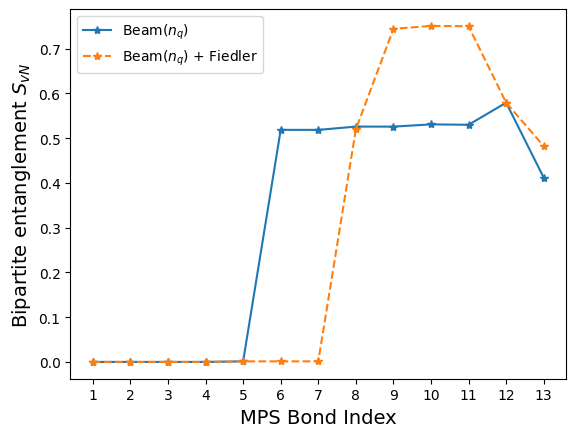

In [ ]:
### data BS vs BS Fiedler - June 11, 2026

import numpy as np
import matplotlib.pyplot as plt

originalThirdColumn = np.array([
  -3.209833356823619e-13,
  -3.0816962966709385e-13,
  -3.113730561709108e-13,
  -3.152171679754912e-13,
  0.0018209882563047098,
  0.7479869798808705,
  0.7479873239249516,
  0.7585338072909307,
  0.7584527639218678,
  0.7657003342104678,
  0.7644522756335989,
  0.8355620805332167,
  0.593915750038379
])

reorderedThirdColumn = np.array([
    -3.1457648267472783e-13,
  -3.16498538577018e-13,
  -3.1906127978007167e-13,
  -3.1906127978007167e-13,
  0.0018209882563024686,
  0.0018214389865948927,
  0.0018241377119234267,
  0.7496418995173335,
  1.0736255864907478,
  1.0830509214675843,
  1.0820691406050498,
  0.8355620805332157,
  0.695653058789528,
])
bs = np.log(2) * originalThirdColumn
bs_fiedler = np.log(2) * reorderedThirdColumn

n_qubits = len(originalThirdColumn) + 1
x = range(1, n_qubits)
plt.plot(x, bs, '-*', label=r"Beam($n_q$)")
plt.plot(x, bs_fiedler, '--*', label=r"Beam($n_q$) + Fiedler")

plt.legend()
plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
plt.xticks(x, x)
plt.savefig("./saved/h2o_corr_BS_fiedler.png", dpi=1000)


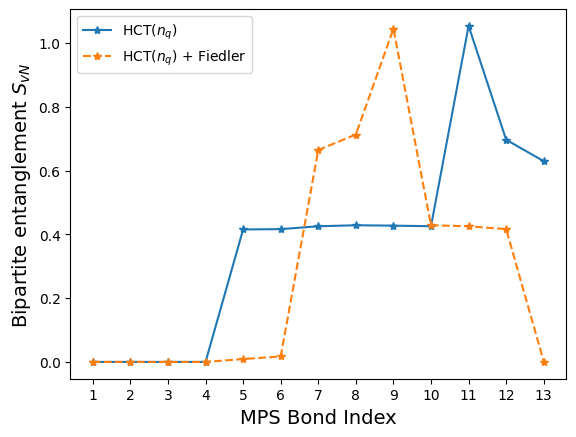

In [ ]:
### data HCT vs Fiedler HCT, June 11 2026
originalThirdColumn = np.array([
  -3.152171679754912e-13,
  -3.152171679754912e-13,
  -3.126544267724376e-13,
  -3.1713922387778143e-13,
  0.5990494451336734,
  0.6005431436837124,
  0.6134293020613942,
  0.6180219311738084,
  0.6163041680218909,
  0.6136178383972095,
  1.5195279001912199,
  1.004769623643585,
  0.9078590647263555
])

reorderedHCTThirdColumn = np.array([
  -3.16498538577018e-13,
  -3.177799091785448e-13,
  -3.1713922387778143e-13,
  -3.1713922387778143e-13,
  0.012909139714870864,
  0.024704355099440148,
  0.9585694022110491,
  1.0282414838759135,
  1.5067543908058099,
  0.6180219311738091,
  0.613429374550766,
  0.6005431436837125,
  0.00182098825630567
])

hct = np.log(2) * originalThirdColumn
hct_fiedler = np.log(2) * reorderedHCTThirdColumn

n_qubits = len(originalThirdColumn) + 1
x = range(1, n_qubits)

#plt.plot(x, bs, '-', label=r"Beam($n_q$)")
#plt.plot(x, bs_fiedler, '--', label=r"Beam($n_q$) + Fiedler")
plt.plot(x, hct, '-*', label=r"HCT($n_q$)")
plt.plot(x, hct_fiedler, '--*', label=r"HCT($n_q$) + Fiedler")

plt.legend()
plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
plt.xticks(x, x)
plt.savefig("./saved/h2o_corr_hct_fiedler.png", dpi=1000)

In [ ]:
# HCT fiedler

H2O_corr -74.7537908684033
1 2 2.8293625933440125e-07
2 3 5.446539270622482e-07
3 4 0.012909176563931216
4 5 0.024705833287174128
5 6 0.026522491524455776
6 7 0.026213819710741604
7 8 0.9362470650995257
8 9 1.6563541680003826
9 10 2.43515317082286
10 11 2.276575239334996
11 12 2.4193970057306444
12 13 1.6332812798399563
13 14 0.9103519771392865

Reordered state:
1 2 0.0018209882802164928
2 3 0.0018209882802222566
3 4 0.9119425520029071
4 5 1.316218302215607
5 6 1.8892958162590667
6 7 1.2120337076795853
7 8 1.9238782124893723
8 9 1.351276331054086
9 10 0.9550168920877586
10 11 0.024705833287172862
11 12 0.012909176563930586
12 13 5.446539251401945e-07
13 14 2.829362596547437e-07
1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z7 Z13]  added at threshold 0.0252067961793301 with metric value  4.161505922709377
1.0 [Z5]  added at threshold 0.046509825381948124 with metric value  1.0384480445408846
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  4.703071548075912
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  4.703071548075912
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  2.4400408382449124
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  2.4400408382449132
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  8.277955369745932
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  8.277955369745932
1.0 [Z6]  added at threshold 0.8329684546459444 with metric value  7.6792252980433915
1.0 [Z7]  added at threshold 0.8329684546459444 with metric value  7.679225298043392
Symmetries rotated to Z on qubits:  [0, 6, 1, 4, 7, 5, 9, 8, 2, 3, 10, 11, 12, 13]
Qubits permuted as:
0 -> 0
1 -> 2
2 -> 8
3 -> 9
4 -> 3
5 -> 5
6 -> 1
7 -> 4
8 -> 7
9 -> 6
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Constructing unitary from factors and permutations...
Entropy of cuts (log base = 2):
1 | 2 : -3.152171679754912e-13
2 | 3 : -3.152171679754912e-13
3 | 4 : -3.126544267724376e-13
4 | 5 : -3.1713922387778143e-13
5 | 6 : 0.5990494451336734
6 | 7 : 0.6005431436837124
7 | 8 : 0.6134293020613942
8 | 9 : 0.6180219311738084
9 | 10 : 0.6163041680218909
10 | 11 : 0.6136178383972095
11 | 12 : 1.5195279001912199
12 | 13 : 1.004769623643585
13 | 14 : 0.9078590647263555

Reordered state after HCT determined rotation:
10 11 -3.16498538577018e-13
11 12 -3.177799091785448e-13
12 13 -3.1713922387778143e-13
13 14 -3.1713922387778143e-13
1 2 0.012909139714870864
2 3 0.024704355099440148
3 4 0.9585694022110491
4 5 1.0282414838759135
5 6 1.5067543908058099
6 7 0.6180219311738091
7 8 0.613429374550766
8 9 0.6005431436837125
9 10 0.00182098825630567



In [11]:
from sympy import Matrix
M = info["mutual_information"]
M[np.abs(M)<1e-4] = 0
Matrix(M)

Matrix([
[0, 0, 0, 0,                    0,                    0,                   0,                   0,                    0,                    0,                    0,                    0,                  0,                  0],
[0, 0, 0, 0,                    0,                    0,                   0,                   0,                    0,                    0,                    0,                    0,                  0,                  0],
[0, 0, 0, 0,                    0,                    0,                   0,                   0,                    0,                    0,                    0,                    0,                  0,                  0],
[0, 0, 0, 0,                    0,                    0,                   0,                   0,                    0,                    0,                    0,                    0,                  0,                  0],
[0, 0, 0, 0,                    0, 0.000327289706582246,   0.586662791990033,  

In [34]:
#!/usr/bin/env python3
"""
Scan PyBlock2 DMRG bond dimensions for equilibrium H2O.

For each bond dimension M, run multiple random-start DMRG calculations and keep
the lowest energy. The minimum required M is defined as the smallest M whose
best energy is within ENERGY_TOL of a high-M reference energy.

No pyscf.dmrgscf is used.
"""

import os
import tempfile
from pathlib import Path

import numpy as np
from pyscf import gto, scf

from pyblock2._pyscf.ao2mo import integrals as itg
from pyblock2.driver.core import DMRGDriver, SymmetryTypes


# ============================================================
# User settings
# ============================================================

BASIS = "sto-3g"

# H2O/STO-3G with one frozen O 1s core gives CAS(8e, 6o).
NCORE = 2
NCAS = None

ENERGY_TOL = 1.6e-3  # Hartree

BOND_DIMS_TO_TEST = [2, 5, 10, 12, 14, 16, 18, 20, 30, 40, 50]#, 20, 30, 40, 60, 80]#, 120, 160, 240, 320]
M_REF = 600

# Multiple random starts per tested bond dimension.
N_RANDOM_RUNS = 10

# Optionally use more random starts for the reference.
N_REF_RANDOM_RUNS = 1

N_SWEEPS = 50
N_THREADS = int(os.environ.get("OMP_NUM_THREADS", "4"))
STACK_MEM = int(2 * 1024**3)

SYMM_TYPE = SymmetryTypes.SU2
IPRINT = 1

# Set to an integer for reproducible repeated scans.
# Set to None for non-reproducible random runs.
BASE_SEED = 12345


# ============================================================
# Geometry
# ============================================================

def h2o_equilibrium_geometry():
    """
    Equilibrium-like gas-phase H2O geometry:
        O-H distance = 0.9584 Angstrom
        H-O-H angle  = 104.45 degrees
    """
    r_oh = 2.1#0.9584
    theta = np.deg2rad(104.5)

    x = r_oh * np.sin(theta / 2.0)
    z = r_oh * np.cos(theta / 2.0)

    return f"""
    O   0.0000000000   0.0000000000   0.0000000000
    H   {x:.10f}       0.0000000000   {z:.10f}
    H  {-x:.10f}       0.0000000000   {z:.10f}
    """


# ============================================================
# PySCF
# ============================================================

def build_rhf_h2o():
    mol = gto.M(
        atom=h2o_equilibrium_geometry(),
        basis=BASIS,
        unit="Angstrom",
        charge=0,
        spin=0,
        symmetry="c2v",
        verbose=4,
        max_memory=8000,
    )

    mf = scf.RHF(mol)
    mf.conv_tol = 1.0e-12
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("RHF did not converge.")

    return mol, mf


# ============================================================
# PyBlock2 DMRG
# ============================================================

def make_sweep_schedule(max_bond_dim):
    """
    Basic finite-DMRG sweep schedule.

    You can make this more aggressive for larger bases/active spaces.
    """
    warmup_dim = max(4, min(max_bond_dim, max_bond_dim // 2))

    bond_dims = (
        [warmup_dim] * 4
        + [max_bond_dim] * 8
        + [max_bond_dim] * 4
    )

    noises = (
        [1.0e-4] * 4
        + [1.0e-5] * 4
        + [1.0e-6] * 4
        + [0.0] * 4
    )

    dav_thresholds = (
        [1.0e-9] * 4
        + [1.0e-10] * 8
        + [1.0e-11] * 4
    )

    n_sweeps = min(N_SWEEPS, len(bond_dims))

    return (
        bond_dims[:n_sweeps],
        noises[:n_sweeps],
        dav_thresholds[:n_sweeps],
        n_sweeps,
    )


def set_block2_random_seed(seed):
    """
    Try to seed Block2's RNG.

    PyBlock2/block2 versions differ slightly, so this uses a defensive import.
    The calculation still works if this fails; it just may not be reproducible.
    """
    if seed is None:
        return

    try:
        from block2 import Random
        Random.rand_seed(seed)
    except Exception:
        pass


def run_single_pyblock2_dmrg(
    ncas,
    n_elec,
    spin,
    ecore,
    h1e,
    g2e,
    orb_sym,
    max_bond_dim,
    scratch_dir,
    seed=None,
):
    """
    Run one PyBlock2 DMRG calculation from one random initial MPS.
    """
    set_block2_random_seed(seed)

    driver = DMRGDriver(
        scratch=str(scratch_dir),
        symm_type=SYMM_TYPE,
        n_threads=N_THREADS,
        stack_mem=STACK_MEM,
    )

    driver.initialize_system(
        n_sites=ncas,
        n_elec=n_elec,
        spin=spin,
        orb_sym=orb_sym,
    )

    mpo = driver.get_qc_mpo(
        h1e=h1e,
        g2e=g2e,
        ecore=ecore,
        iprint=IPRINT,
    )

    ket = driver.get_random_mps(
        tag=f"GS_M{max_bond_dim}_seed{seed}",
        bond_dim=max_bond_dim,
        nroots=1,
    )

    bond_dims, noises, thrds, n_sweeps = make_sweep_schedule(max_bond_dim)

    energy = driver.dmrg(
        mpo,
        ket,
        n_sweeps=n_sweeps,
        bond_dims=bond_dims,
        noises=noises,
        thrds=thrds,
        iprint=IPRINT,
    )

    return float(energy)


def seed_for_run(max_bond_dim, run_index, reference=False):
    """
    Deterministic seed schedule if BASE_SEED is not None.
    """
    if BASE_SEED is None:
        return None

    offset = 1_000_000 if reference else 0
    return BASE_SEED + offset + 10_000 * max_bond_dim + run_index


def run_replicates_at_bond_dim(
    ncas,
    n_elec,
    spin,
    ecore,
    h1e,
    g2e,
    orb_sym,
    max_bond_dim,
    n_runs,
    scratch_parent,
    reference=False,
):
    """
    Run several random-start DMRG calculations at a fixed M.

    Returns
    -------
    best_energy : float
        Lowest energy among random runs.
    all_energies : list[float]
        Energies from each run.
    """
    energies = []

    for run_idx in range(n_runs):
        seed = seed_for_run(max_bond_dim, run_idx, reference=reference)

        scratch = (
            Path(scratch_parent)
            / f"{'ref_' if reference else ''}M{max_bond_dim}"
            / f"run_{run_idx:03d}"
        )
        scratch.mkdir(parents=True, exist_ok=True)

        e = run_single_pyblock2_dmrg(
            ncas=ncas,
            n_elec=n_elec,
            spin=spin,
            ecore=ecore,
            h1e=h1e,
            g2e=g2e,
            orb_sym=orb_sym,
            max_bond_dim=max_bond_dim,
            scratch_dir=scratch,
            seed=seed,
        )

        energies.append(e)

        print(
            f"    run {run_idx + 1:2d}/{n_runs}, "
            f"seed={seed}, "
            f"E={e:.12f} Eh"
        )

    return min(energies), energies


# ============================================================
# Main
# ============================================================

def build_rhf_n2():
    """
    Build an RHF reference for N2 near equilibrium geometry.

    N-N distance: 1.0977 Angstrom
    Basis: controlled by global BASIS, e.g. BASIS = "sto-3g"
    """
    mol = gto.M(
        atom="""
        N   0.0000000000   0.0000000000  -1.1
        N   0.0000000000   0.0000000000   1.1
        """,
        basis=BASIS,
        unit="Angstrom",
        charge=0,
        spin=0,
        symmetry="d2h",
        verbose=4,
        max_memory=8000,
    )

    mf = scf.RHF(mol)
    mf.conv_tol = 1.0e-12
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("RHF did not converge.")

    return mol, mf

def main():
    print("\nBuilding H2O RHF reference...")
    mol, mf = build_rhf_n2()

    print("\nGenerating active-space integrals...")
    ncas, n_elec, spin, ecore, h1e, g2e, orb_sym = itg.get_rhf_integrals(
        mf,
        ncore=NCORE,
        ncas=NCAS,
        g2e_symm=8,
    )

    print("\n=== Calculation setup ===")
    print(f"Molecule              : H2O equilibrium geometry")
    print(f"Basis                 : {BASIS}")
    print(f"Frozen cores          : {NCORE}")
    print(f"Active space          : CAS({n_elec}e, {ncas}o)")
    print(f"Spin target           : {spin}")
    print(f"Symmetry mode         : SU2")
    print(f"Energy tolerance      : {ENERGY_TOL:.2e} Eh")
    print(f"Test bond dimensions  : {BOND_DIMS_TO_TEST}")
    print(f"Random runs per M     : {N_RANDOM_RUNS}")
    print(f"Reference M           : {M_REF}")
    print(f"Reference random runs : {N_REF_RANDOM_RUNS}")
    print(f"Base seed             : {BASE_SEED}")

    results = []

    with tempfile.TemporaryDirectory(prefix="h2o_pyblock2_replicates_") as tmp:
        tmp = Path(tmp)

        print("\nRunning reference calculations...")
        e_ref, ref_energies = run_replicates_at_bond_dim(
            ncas=ncas,
            n_elec=n_elec,
            spin=spin,
            ecore=ecore,
            h1e=h1e,
            g2e=g2e,
            orb_sym=orb_sym,
            max_bond_dim=M_REF,
            n_runs=N_REF_RANDOM_RUNS,
            scratch_parent=tmp,
            reference=True,
        )

        print("\nReference energies:")
        for i, e in enumerate(ref_energies):
            print(f"    ref run {i + 1:2d}: {e:.12f} Eh")
        print(f"Best reference energy: {e_ref:.12f} Eh")

        print("\n=== Bond-dimension scan ===")

        for M in BOND_DIMS_TO_TEST:
            if M >= M_REF:
                continue

            print(f"\nM = {M}")

            best_e, all_e = run_replicates_at_bond_dim(
                ncas=ncas,
                n_elec=n_elec,
                spin=spin,
                ecore=ecore,
                h1e=h1e,
                g2e=g2e,
                orb_sym=orb_sym,
                max_bond_dim=M,
                n_runs=N_RANDOM_RUNS,
                scratch_parent=tmp,
                reference=False,
            )

            mean_e = float(np.mean(all_e))
            std_e = float(np.std(all_e, ddof=1)) if len(all_e) > 1 else 0.0
            spread_e = float(max(all_e) - min(all_e))
            abs_err = abs(best_e - e_ref)

            results.append(
                {
                    "M": M,
                    "best": best_e,
                    "mean": mean_e,
                    "std": std_e,
                    "spread": spread_e,
                    "abs_err": abs_err,
                    "energies": all_e,
                }
            )

            print(
                f"  best E       = {best_e:.12f} Eh\n"
                f"  mean E       = {mean_e:.12f} Eh\n"
                f"  std E        = {std_e:.3e} Eh\n"
                f"  spread       = {spread_e:.3e} Eh\n"
                f"  |best-ref|   = {abs_err:.3e} Eh"
            )

    print("\n=== Summary ===")
    header = (
        f"{'M':>8s} "
        f"{'best E / Eh':>22s} "
        f"{'mean E / Eh':>22s} "
        f"{'std / Eh':>12s} "
        f"{'spread / Eh':>14s} "
        f"{'|best-ref| / Eh':>18s}"
    )
    print(header)
    print("-" * len(header))

    for row in results:
        print(
            f"{row['M']:8d} "
            f"{row['best']:22.12f} "
            f"{row['mean']:22.12f} "
            f"{row['std']:12.3e} "
            f"{row['spread']:14.3e} "
            f"{row['abs_err']:18.3e}"
        )

    converged = [row for row in results if row["abs_err"] <= ENERGY_TOL]

    print("\n=== Result ===")
    if converged:
        row = converged[0]
        print(f"Minimum converged bond dimension: M = {row['M']}")
        print(f"Best E(M)  = {row['best']:.12f} Eh")
        print(f"E_ref      = {e_ref:.12f} Eh")
        print(f"|dE|       = {row['abs_err']:.3e} Eh")
        print(f"Run spread = {row['spread']:.3e} Eh")
    else:
        print("No tested bond dimension met the requested tolerance.")
        print("Increase BOND_DIMS_TO_TEST and/or M_REF, or loosen ENERGY_TOL.")


if __name__ == "__main__":
    main()


Building H2O RHF reference...
System: uname_result(system='Darwin', node='Praveens-MacBook-Pro-4.local', release='25.5.0', version='Darwin Kernel Version 25.5.0: Mon Apr 27 20:38:56 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T6000', machine='arm64')  Threads 1
Python 3.9.15 (main, Nov  4 2022, 11:12:28) 
[Clang 12.0.0 ]
numpy 1.23.3  scipy 1.9.3
Date: Mon Jun  8 22:31:41 2026
PySCF version 2.1.1
PySCF path  /Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry D2h subgroup None
[INPUT] Mole.unit = Angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000  -1.100000000000 AA    0.000000000000   0.000000000000  -2.078698737022 Bohr   0.0
[INPUT] 

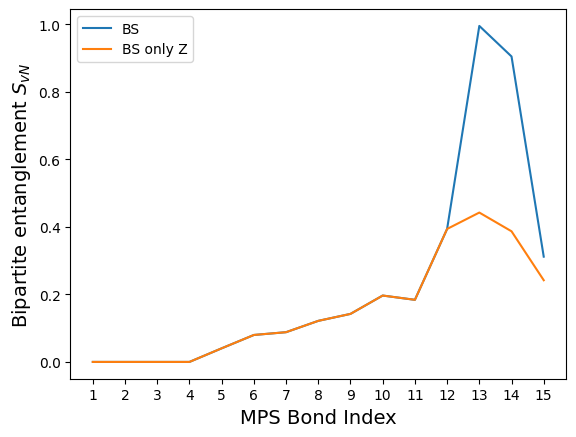

In [1]:
import numpy as np
import matplotlib.pyplot as plt

values_only_z = np.array([
    -6.6613381477510055e-15,
    -4.884981308350724e-15,
    -6.6613381477510055e-15,
    -7.105427357601078e-15,
    0.040267767338500834,
    0.07980672522545221,
    0.08804523035628367,
    0.12158412650556868,
    0.14222721580388992,
    0.1965762809674807,
    0.18390123990471086,
    0.3937625137212064,
    0.44230216936647065,
    0.3868201863350851,
    0.24189805921006693,
])

values_unmod = np.array([
    -6.6613381477510055e-15,
    -6.6613381477510055e-15,
    -5.329070518200794e-15,
    -5.773159728050864e-15,
    0.04026776733850147,
    0.07980672522545385,
    0.08804523035628387,
    0.121584126505568,
    0.14222721580389033,
    0.1965762809674818,
    0.18390123990471152,
    0.3937625137212073,
    0.9949889565175741,
    0.9045343693347089,
    0.31168396646158664,
])

fig, ax = plt.subplots()

n_qubits = len(values_unmod) + 1
x = range(1, n_qubits)
ax.plot(x, values_unmod, label="BS")
ax.plot(x, values_only_z, label="BS only Z")

ax.legend()
ax.set_xlabel("MPS Bond Index", fontsize=14)
ax.set_ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
ax.set_xticks(x, x)

In [ ]:
op = 
[
1.0 [Z0 Z3 Z4 Z7 Z9 Z10 Z12 Z15], 
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13 Z15], 
1.0 [Z2 Z3 Z10 Z11 Z12 Z13 Z14 Z15], 
1.0 [Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13], 
1.0 [Z3], 
1.0 [Z1], 
1.0 [Z2 Z3], 
1.0 [Z5 Z15], 
1.0 [Z0], 
1.0 [Z5], 
1.0 [Z4], 
1.0 [Z7 Z11], 
1.0 [Y7 Z8 X9 X11 Z12 Y13], 
1.0 [Z6], 
1.0 [Z6 Z10], 
1.0 [Z8]
]

op_only_z = 
[
1.0 [Z0 Z3 Z4 Z7 Z9 Z10 Z12 Z15], 
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13 Z15], 
1.0 [Z2 Z3 Z10 Z11 Z12 Z13 Z14 Z15], 
1.0 [Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13], 
1.0 [Z3], 
1.0 [Z1], 
1.0 [Z2 Z3], 
1.0 [Z5 Z15], 
1.0 [Z0], 
1.0 [Z5], 
1.0 [Z4], 
1.0 [Z7 Z11], 
1.0 [Z6 Z7], 
1.0 [Z6], 
1.0 [Z6 Z10], 
1.0 [Z8]
]

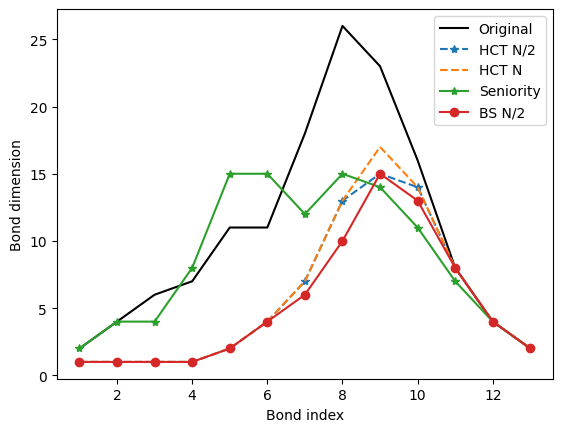

In [ ]:
#DATA h2o 2.1 10^-5 rel truncation, minimize |<cisd| [H, S]^2 |cisd>|
og_bd = [2, 4, 6, 7, 11, 11, 18, 26, 23, 16, 8, 4, 2]
hct_bd =  [1, 1, 1, 1, 2, 4, 7, 13, 15, 14, 8, 4, 2]
hct_bd_N = [1, 1, 1, 1, 2, 4, 7, 13, 17, 14, 8, 4, 2]
sen_bd = [2, 4, 4, 8, 15, 15, 12, 15, 14, 11, 7, 4, 2]
bs_bd = [1, 1, 1, 1, 2, 4, 6, 10, 15, 13, 8, 4, 2]

import matplotlib.pyplot as plt

plt.plot(range(1, len(og_bd)+1), og_bd, color='black',label="Original")
plt.plot(range(1, len(og_bd)+1), hct_bd, '*--', label="HCT N/2")
plt.plot(range(1, len(og_bd)+1), hct_bd_N, '--', label="HCT N")
plt.plot(range(1, len(og_bd)+1), sen_bd, '*-', label="Seniority")
plt.plot(range(1, len(bs_bd)+1), bs_bd, 'o-', label="BS N/2")
plt.legend()
plt.xlabel("Bond index")
plt.ylabel("Bond dimension")
plt.savefig('./saved/mps_bd_H2O2.1.png')

In [ ]:
from openfermion import QubitOperator
from copy import deepcopy
from quasisymmetries.tn import QO_to_block2_MPO, cleanup_block2_driver

mpo, driver = QO_to_block2_MPO(H_perm_sen, n_qubits)

n_sweeps =32
bd=20

for r in range(30):
    ket = driver.get_random_mps(tag="KET", bond_dim=bd, nroots=1) #nroots corresponds to number of MPS >1 for excited states
    energy = driver.dmrg(
        mpo,
        ket,
        n_sweeps=n_sweeps,
        bond_dims=None,
        noises= [1e-3]*4 + [1e-4]*4 + [1e-5]*4 + [1e-6]*4 + [0.0]*8,
        thrds= [1e-8, 1e-9] + [1e-10] * (n_sweeps-2),
        dav_max_iter=50,
        iprint=0,
    )

    print(abs(e - np.array(energy)))

cleanup_block2_driver(driver)


0.010045347502654067
0.010045346712217906
0.010045350160126532
0.010045348396133136
0.01004534912743793
0.010045346847974201
0.010045348503638252
0.0100453485982257
0.010045349177389085
0.010045347903655966
0.010045348966841061
0.010045346784821163
0.010045353546189517
0.010045348622128358
0.010045349865535513
0.01004535134606499
0.01004534884310715
0.010045348687640399
0.0249609826078796
0.010045348924464292
0.010045348581854796
0.024960982511686325
0.010045348578742619
0.010045345852887522
0.01004534858026318
0.02496098236679245
0.010045348661591902
0.013035815746633261
0.010045348636552376
0.010045348523604503


In [61]:
### sample code to test HCT and beam search

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator
from quasisymmetries.state_utils import get_cisd_gs, get_fci_state_openfermion
from quasisymmetries.op_utils import build_H_chain_for_R, h2o_geometry
from quasisymmetries.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod

from quasisymmetries.bs.utils import *
from quasisymmetries.bs.beam import *

# hct
from quasisymmetries.metrics import variance, comm_sq_exp_fast, find_commuting_paulis, universal_grading
from quasisymmetries.state_utils import get_hf_occ, get_hf_wfn

# bl = 1.6
# geometry = [
#     ('Li', (0.0, 0.0, -bl/2)),
#     ('H', (0.0, 0.0, bl/2))
# ]

bl = 1.0
geometry = [
    ('N', (0.0, 0.0, -bl/2)),
    ('N', (0.0, 0.0, bl/2))
]

#geometry = h2o_geometry(2.1, 104.5) 

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=False
)

# n_H = 4
# H, molecule =  build_H_chain_for_R(1.0, n_H)

# Get second-quantized electronic Hamiltonian and wavefunctions
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
#Hs = get_sparse_operator(HQ, n_qubits)

e, gs, gs_info = get_fci_state_openfermion(molecule)

In [ ]:
HCT N
Symmetries:
1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]
1.0 [Z4 Z5]
1.0 [Z6 Z7 Z12 Z13]
1.0 [Z0 Z2 Z4 Z8 Z10]
1.0 [Z4]
1.0 [Z1 Z3]
1.0 [Z0 Z2]
1.0 [Z0]
1.0 [Z1]
1.0 [Z8]
1.0 [Z9]
1.0 [Z6]
1.0 [Z7]
Non-commutator L1:  51.40054007547056
Entropy:  0
Commuting terms:  106
Cut entropies:
 -3.6775336263809316e-13
-3.6647199203656624e-13
-3.6775336263809316e-13
-3.6775336263809316e-13
0.599049445134329
0.6005431436843647
0.6134293020622013
0.6180219311743971
0.6163041680225164
0.6136178383978468
1.5195279001917943
1.0047696236429093
0.9078590647262086
DMRG conv BD:  5
Single sector energy:  0
SEN
Symmetries:
1.0 [Z0 Z1]
1.0 [Z2 Z3]
1.0 [Z4 Z5]
1.0 [Z6 Z7]
1.0 [Z8 Z9]
1.0 [Z10 Z11]
1.0 [Z12 Z13]
Non-commutator L1:  63.30185936485179
Entropy:  (0.7814150646552022-2.555809186351111e-18j)
Commuting terms:  190
Cut entropies:
 5.234350444970638e-07
0.02018572295475297
0.020185722954753037
0.769118545996088
0.7798151111726173
0.7749619493422348
0.7632535296661255
0.763253540343568
0.7667094888968597
0.7680429241592543
1.6379894737550869
1.830628480312921
0.9103519771387181
DMRG conv BD:  9
Single sector energy:  -74.72081064480749
QUAR
Symmetries:
1.0 [Z0 Z1 Z2 Z3]
1.0 [Z2 Z3 Z4 Z5]
1.0 [Z4 Z5 Z6 Z7]
1.0 [Z6 Z7 Z8 Z9]
1.0 [Z8 Z9 Z10 Z11]
1.0 [Z10 Z11 Z12 Z13]
Non-commutator L1:  71.13268287030385
Entropy:  (0.7814150646552023-2.555809186351111e-18j)
Commuting terms:  190
Cut entropies:
 0.02018620633206881
0.020185722954735443
0.7691185459960894
0.7814153434695645
0.7798151111725455
0.7749619493420926
0.7749619617050845
0.7783994247963572
0.7797677318998862
1.6583987493290728
2.257394704625883
1.6332812798400045
0.9103519771389526
DMRG conv BD:  9
Single sector energy:  -74.72081064480719
BS(16) N/2
Symmetries:
1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]
1.0 [Z4 Z5]
1.0 [Z6 Z7 Z12 Z13]
1.0 [Z5]
1.0 [Z6 Z7]
1.0 [Z0]
Non-commutator L1:  15.964154351852802
Entropy:  (0.7507020980748053-2.5343735906927702e-18j)
Commuting terms:  518
Cut entropies:
 -3.7416021564572795e-13
-3.6326856553274887e-13
-3.7736364214954537e-13
-3.7736364214954537e-13
0.0018209882562422743
0.7479869798799498
0.7479873239240317
0.7607246465581697
1.6424827017230375
2.4223001643877837
2.2541067895559914
1.8419905042853597
0.9103518503546209
DMRG conv BD:  8
Single sector energy:  -74.72606055846722
BS(16) N
Symmetries:
1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]
1.0 [Z4 Z5]
1.0 [Z6 Z7 Z12 Z13]
1.0 [Z5]
1.0 [Z6 Z7]
1.0 [Z0]
1.0 [Z8 Z9]
1.0 [Z1]
1.0 [Z2 Z5]
1.0 [Z10 Z11]
1.0 [Y6 X7 X12 Y13]
1.0 [X6 X7 X12 X13]
1.0 [X8 X9 X10 X11]
Non-commutator L1:  133.22914375623424
Entropy:  0
Commuting terms:  42
Cut entropies:
 -3.440480065098452e-13
-3.3443772699839373e-13
-3.402038947052646e-13
-3.472514330136625e-13
0.0018209882562750044
0.747986979881249
0.74798732392533
0.7585338072922764
0.7584527639232135
0.7657003342120489
0.7644522756347779
0.8355620805302035
0.5939157500356281

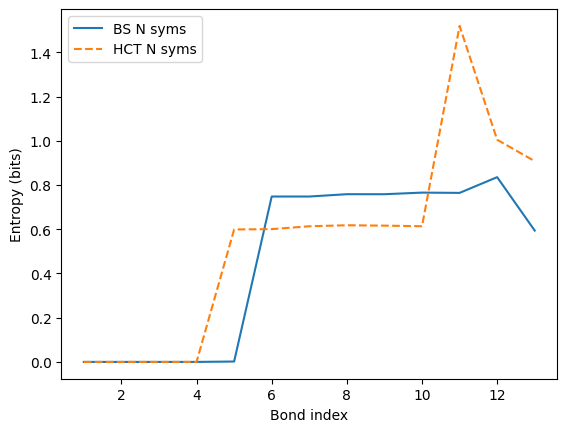

In [8]:
import matplotlib.pyplot as plt

bs_n = [
    -3.440480065098452e-13,
    -3.3443772699839373e-13,
    -3.402038947052646e-13,
    -3.472514330136625e-13,
    0.0018209882562750044,
    0.747986979881249,
    0.74798732392533,
    0.7585338072922764,
    0.7584527639232135,
    0.7657003342120489,
    0.7644522756347779,
    0.8355620805302035,
    0.5939157500356281,
]

hct_n = [
    -3.6775336263809316e-13,
    -3.6647199203656624e-13,
    -3.6775336263809316e-13,
    -3.6775336263809316e-13,
    0.599049445134329,
    0.6005431436843647,
    0.6134293020622013,
    0.6180219311743971,
    0.6163041680225164,
    0.6136178383978468,
    1.5195279001917943,
    1.0047696236429093,
    0.9078590647262086,
]

plt.plot(list(range(1, len(bs_n) + 1)), bs_n, '-', label="BS N syms")
plt.plot(range(1, len(bs_n) + 1), hct_n, '--', label="HCT N syms")
plt.xlabel("Bond index")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.show()

1.0 [Z0 Z3 Z4 Z7 Z9 Z10 Z12 Z15]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13 Z15]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z10 Z11 Z12 Z13 Z14 Z15]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z3 Z4 Z10 Z11 Z12 Z13 Z15]  added at threshold 0.022358606104779938 with metric value  5.409222224734672
1.0 [Z8 Z12]  added at threshold 0.024171905540073337 with metric value  6.645651106614256
1.0 [Z7 Z11]  added at threshold 0.024171905540073337 with metric value  6.645651106614257
1.0 [Z0 Z3 Z4 Z15]  added at threshold 0.03049452405358821 with metric value  12.307310449079395
1.0 [Z1]  added at threshold 0.034261227379439124 with metric value  6.498734145994908
1.0 [Z0]  added at threshold 0.03609596862046862 with metric value  6.498734145994908
1.0 [Z7 Z13]  added at threshold 0.03880851634968948 with metric value  7.80931072272413
1.0 [Z8]  added at thr

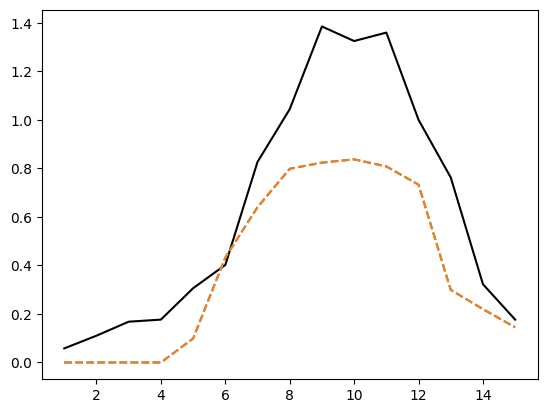

In [5]:
from __future__ import annotations
# benchmark scripts

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
import pickle

from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator, QubitOperator
from quasisymmetries.state_utils import get_cisd_gs, get_fci_state_openfermion
from quasisymmetries.op_utils import build_H_chain_for_R, h2o_geometry
from quasisymmetries.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod, bs_hct

from quasisymmetries.bs.utils import *
from quasisymmetries.bs.beam import *
import pprint

# hct
from quasisymmetries.state_utils import get_hf_occ, get_hf_wfn

from quasisymmetries.metrics import *
from quasisymmetries.tn import find_dmrg_conv_bd
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from quasisymmetries.metrics import *

directory = './saved/hamiltonians/'
system = 'N2frozen_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)
Hs = get_sparse_operator(HQ, n_qubits)

from quasisymmetries.op_utils import split_diagonal_paulis

def separate_H(HQ, list_syms, verbose=False, verify=True):
    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    H0 = sum(find_commuting_paulis(HQ_mod, list_syms, verbose)) + const
    V = HQ - H0

    #diagonal and non-diagonal commuting

    Z0, V0 = split_diagonal_paulis(H0)

    return Z0, V0, V

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

#sen_sym= get_seniority_symmetries(n_qubits)

hct_og_sym, _ = hct_mod(HQ, n_qubits, use_coeffs_eps=True)
hct_sym, _ = hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)

from quasisymmetries.metrics import get_entropies_at_cuts, get_ent
og_ent = get_entropies_at_cuts(fci_gs,n_qubits)

hct_og_ent, H_perm_hct_og = get_ent(hct_og_sym, HQ, n_qubits)
hct_ent, H_perm_hct = get_ent(hct_sym, HQ, n_qubits)

import matplotlib.pyplot as plt

b_idx = list(range(1, n_qubits))
plt.plot(b_idx, og_ent, color='black', label="Unmodified")

plt.plot(b_idx, hct_og_ent, '--', label="Original HCT(N)")
plt.plot(b_idx, hct_ent, '--', label="CISD cost HCT(N)")
plt.legend()
plt.xlabel("Bond Index")
plt.ylabel("Entropy (bits)")
plt.savefig("./saved/n2_hct_comp.png", dpi=500)


#Z0, V0, V = separate_H(HQ, list_sym)

# compare HCT OG and HCT cisd cost func BS-HCT

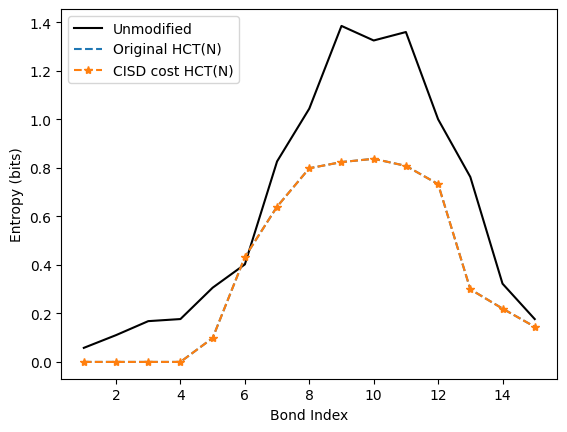

In [7]:
b_idx = list(range(1, n_qubits))
plt.plot(b_idx, og_ent, color='black', label="Unmodified")

plt.plot(b_idx, hct_og_ent, '--', label="Original HCT(N)")
plt.plot(b_idx, hct_ent, '--*', label="CISD cost HCT(N)")
plt.legend()
plt.xlabel("Bond Index")
plt.ylabel("Entropy (bits)")
plt.savefig("./saved/n2_hct_comp.png", dpi=500)

In [8]:
### May 26, testing new DMRG calculation stuff

from quasisymmetries.tn import find_dmrg_conv_bd_quimb

import pickle
import quimb.tensor as qtn
import numpy as np
from openfermion import count_qubits, jordan_wigner, MolecularData, get_sparse_operator
from quasisymmetries.state_utils import get_hf_wfn, get_hf_occ
from quasisymmetries.metrics import get_permuted_bipartite_entanglement, comm_sq_exp_fast
from quasisymmetries.sym import get_seniority_symmetries, hct_mod
from quasisymmetries.bliss import lp_bliss_paper_real_pauli_1norm

directory = "./saved/hamiltonians/"

systems = [
    'H2O_corr',]
'''
    'H4chain_corr',
    'H4chain_diss',
    'H4rect_corr',
    'H4rect_diss',
    'LiH_eqm',
    'LiH_corr',
    'H2O_eqm',
    'H2O_corr',
    'H2O_diss',
    'N2frozen_eqm',
    'N2frozen_corr',
    'N2frozen_diss'
]
'''

#options
verbose=True

outfile = "results_fci_guess.txt"

for system in systems:
    filename= system
    with open(directory+system+".pkl", "rb") as f:
        data = pickle.load(f)
    H, fci_e, fci_gs, cisd_e, cisd_gs = data
    HQ = jordan_wigner(H)
    molecule = MolecularData(filename=directory+system)
    n_qubits = count_qubits(HQ)
    Hs = get_sparse_operator(HQ, n_qubits)


    H_bliss, info = lp_bliss_paper_real_pauli_1norm(
        H,
        n_electrons=(molecule.n_electrons),
        n_orb=(molecule.n_orbitals * 2),
    )
    print("Pauli BLISS completed, Relative Pauli L1 reduction: {}".format(info["relative_pauli_l1_reduction"]))
    HQ_bliss = jordan_wigner(H_bliss)

    comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
    # comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
    # var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
    # var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

    sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
    sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

    # #sym and rotation
    sym_hct, eps = hct_mod(HQ, n_qubits, sym_metric_func= sym_metric_func, use_coeffs_eps=True)
    sym_hct_bliss, eps_bliss = hct_mod(HQ_bliss, n_qubits, sym_metric_func= sym_metric_func, use_coeffs_eps=True)

    # # list_sym = get_seniority_symmetries(8)
    ents, H_perm, U, gs_rot = get_permuted_bipartite_entanglement(sym_hct, HQ, n_qubits, fci_e, fci_gs, verbose, True, True, 'e', False)
    ents_bliss, H_perm_bliss, U_bliss, gs_rot_bliss = get_permuted_bipartite_entanglement(sym_hct_bliss, HQ, n_qubits, fci_e, fci_gs, verbose, True, True, 'e', False)

    compress_cutoff = 1e-20
    gs_rot_mps = qtn.MatrixProductState.from_dense(gs_rot, cutoff = compress_cutoff)     
    dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                            reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                            noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)
    
    print(dmrg_bd)

    gs_rot_bliss_mps = qtn.MatrixProductState.from_dense(gs_rot_bliss, cutoff = compress_cutoff)     
    dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm_bliss, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                            reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                            noise = 1e0, bsz=2, guess_mps = gs_rot_bliss_mps, seed=0)
    
    print(dmrg_bd)

1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z7 Z13]  added at threshold 0.0252067961793301 with metric value  0.182823017249101
1.0 [Z5]  added at threshold 0.046509825381948124 with metric value  1.1530909282284412e-28
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  0.003303473460916225
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  0.0018108717025034867
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  4.841677111176281e-05
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  9.984162050804155e-05
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  0.21706520455070824
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  0.217649599

/Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


DMRG converged at bond dimension: 4
4
DMRG converged at bond dimension: 6
6


In [39]:
directory = "./saved/hamiltonians/"

systems = [
    'H2O_corr',]
'''
    'H4chain_corr',
    'H4chain_diss',
    'H4rect_corr',
    'H4rect_diss',
    'LiH_eqm',
    'LiH_corr',
    'H2O_eqm',
    'H2O_corr',
    'H2O_diss',
    'N2frozen_eqm',
    'N2frozen_corr',
    'N2frozen_diss'
]
'''

#options
verbose=True

for system in systems:
    filename= system
    with open(directory+system+".pkl", "rb") as f:
        data = pickle.load(f)
    H, fci_e, fci_gs, cisd_e, cisd_gs = data
    HQ = jordan_wigner(H)
    molecule = MolecularData(filename=directory+system)
    n_qubits = count_qubits(HQ)
    Hs = get_sparse_operator(HQ, n_qubits)

    print(molecule.orbital_energies)

[-20.31138224  -1.12691038  -0.41031595  -0.28179825  -0.26177949
   0.09438368   0.10644668]


In [70]:
print(system[:2])
n_elec = molecule.n_electrons if 'N2' is not 'N2' else molecule.n_electrons - 4
n_elec

H2


<>:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_68454/1181893051.py:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  n_elec = molecule.n_electrons if 'N2' is not 'N2' else molecule.n_electrons - 4


6

In [14]:
ents_bs, H_perm, U, gs_rot = get_permuted_bipartite_entanglement(sym_bs, HQ, n_qubits, fci_e, fci_gs, verbose, True, True, 'e', False)
ents_bs_bliss, H_perm_bliss, U_bliss, gs_rot_bliss = get_permuted_bipartite_entanglement(sym_bs_bliss, HQ, n_qubits, fci_e, fci_gs, verbose, True, True, 'e', False)

compress_cutoff = 1e-20
gs_rot_mps = qtn.MatrixProductState.from_dense(gs_rot, cutoff = compress_cutoff)     
dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                        reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                        noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)

print(dmrg_bd)

gs_rot_bliss_mps = qtn.MatrixProductState.from_dense(gs_rot_bliss, cutoff = compress_cutoff)     
dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm_bliss, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                        reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                        noise = 1e0, bsz=2, guess_mps = gs_rot_bliss_mps, seed=0)

print(dmrg_bd)

Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 5, 12, 2, 8, 3, 7, 10, 9, 13, 11]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 6
3 -> 8
4 -> 2
5 -> 4
6 -> 3
7 -> 9
8 -> 7
9 -> 11
10 -> 10
11 -> 13
12 -> 5
13 -> 12
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : -2.224886941349556e-13
2 | 3 : -2.1360690993794858e-13
3 | 4 : -2.158273559872003e-13
4 | 5 : -2.1849189124630242e-13
5 | 6 : 0.0012622128756903809
6 | 7 : 0.5184650661999739
7 | 8 : 0.5184653046731587
8 | 9 : 0.5257755698831095
9 | 10 : 0.5257193949003405
10 | 11 : 0.5307430278117934
11 | 12 : 0.5298779395280634
12 | 13 : 0.579167500304401
13 | 14 : 0.4116710276292476
Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 5, 12, 2, 8, 3, 7, 10, 9, 11, 13]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 6
3 -> 8
4 -> 2
5 -> 4
6 -> 3
7 -> 9
8 -> 7
9 -> 11
10 -> 10
11 -> 12
12 -> 5
13 -> 13
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : -2.224886941349556e-13

In [12]:
#sym_group_score_func(sym_hct_bliss)

### check pool before and after bliss
from quasisymmetries.bs.beam import find_commuting_symmetry_generators

sym_bs = find_commuting_symmetry_generators(
            HQ,
            target_rank=n_qubits,
            beam_width=16,
            heavy_core_fraction=1,
            include_pairwise_products=True,
            pairwise_seed_terms=12,
            seed_with_exact_symmetries=True,
            score_func= sym_group_score_func, # this function maximizes the cost function TODO invert this
            include_hct_symmetries = True,
            hct_n_sym = n_qubits,
            hct_use_coeffs_eps = True,
        )

for sym in sym_bs:
    print(sym)


sym_bs_bliss = find_commuting_symmetry_generators(
            HQ_bliss,
            target_rank=n_qubits,
            beam_width=16,
            heavy_core_fraction=1,
            include_pairwise_products=True,
            pairwise_seed_terms=12,
            seed_with_exact_symmetries=True,
            score_func= sym_group_score_func, # this function maximizes the cost function TODO invert this
            include_hct_symmetries = True,
            hct_n_sym = n_qubits,
            hct_use_coeffs_eps = True,
        )

for sym in sym_bs_bliss:
    print(sym)



Adding HCT symmetries to the pool:
1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z7 Z13]  added at threshold 0.0252067961793301 with metric value  4.161505922709377
1.0 [Z5]  added at threshold 0.046509825381948124 with metric value  1.0384480445408846
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  4.703071548075912
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  4.703071548075912
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  2.4400408382449124
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  2.4400408382449132
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  8.277955369745932
1.0 [Z9]  added at threshold 0.4613455216244923 with metric va

[-20.31138224  -1.12691038  -0.41031595  -0.28179825  -0.26177949
   0.09438368   0.10644668]


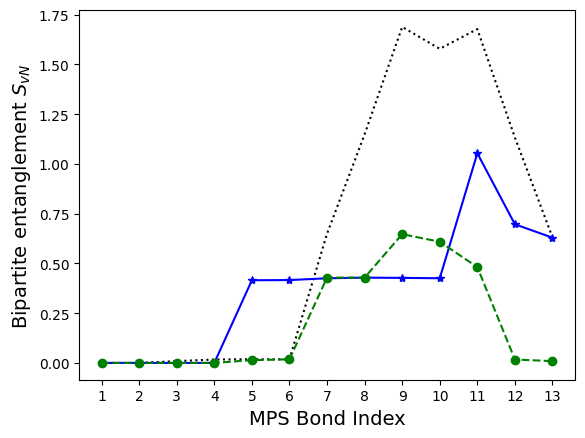

In [51]:
#H2O HCT, HCT + bliss plot data

import matplotlib.pyplot as plt
from quasisymmetries.metrics import get_entropies_at_cuts
import numpy as np

ent_hct = np.array([
    -2.1849189124630242e-13,
    -2.1849189124630242e-13,
    -2.16715534406901e-13,
    -2.1982415887585347e-13,
    0.41522943391040534,
    0.4162647868489714,
    0.4251967911967105,
    0.4283801591173378,
    0.4271894964317164,
    0.4253274746263139,
    1.053256479799718,
    0.6964532317408284,
    0.6292799510608622,
])
ent_hct_bliss = np.array([
    -2.2293278334480598e-13,
    -2.16715534406901e-13,
    -2.1360690993794858e-13,
    -2.1760371282660172e-13,
    0.013991997183807954,
    0.018173867127594216,
    0.4285181580580533,
    0.4283801591173372,
    0.6468689876182694,
    0.608737450568645,
    0.4814473675829811,
    0.01712375408472869,
    0.00894793441873885,
])

directory = "./saved/hamiltonians/"
system = 'H2O_corr'

for system in systems:
    filename= system
    with open(directory+system+".pkl", "rb") as f:
        data = pickle.load(f)
    H, fci_e, fci_gs, cisd_e, cisd_gs = data
    HQ = jordan_wigner(H)
    molecule = MolecularData(filename=directory+system)
    n_qubits = count_qubits(HQ)
    print(molecule.orbital_energies)

gs_ent = get_entropies_at_cuts(fci_gs, n_qubits, log_base='e')

x = range(1, n_qubits)
plt.plot()

# tags = [r'HCT($n_q$)', r'Pauli BLISS+HCT($n_q$)', r'BS($n_q$)', r'Pauli BLISS+BS($n_q$)']
# datasets = [ents, ents_bliss]
# for tag, data in zip(tags, datasets):
#     n_qubits = len(data) + 1
#     x = range(1, n_qubits)
#     ax.plot(x, data, label=tag)



plt.plot(x, gs_ent, ':', color="black", label="Reference")
plt.plot(x, ent_hct, '-*', color="blue", label=r"HCT($n_q$)")
plt.plot(x, ent_hct_bliss, '--o', color="green", label=r"HCT($n_q$)+BLISS")

#plt.legend()
plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
plt.xticks(x, x)

filename = "./saved/H2O_corr_hct_n_bliss.pdf"
if filename is not None: plt.savefig(filename, dpi=1000, bbox_inches="tight")

In [15]:
### diagonal vs non-diagonal symmetry test

from quasisymmetries.bs.beam import build_candidate_pool_hct
from quasisymmetries.bs.utils import exact_pauli_symmetry_basis, qubit_operator_terms, mask_to_qubit_operator

### May 26, testing new DMRG calculation stuff

from quasisymmetries.tn import find_dmrg_conv_bd_quimb

import pickle
import quimb.tensor as qtn
import numpy as np
from openfermion import count_qubits, jordan_wigner, MolecularData, get_sparse_operator
from quasisymmetries.state_utils import get_hf_wfn, get_hf_occ
from quasisymmetries.metrics import get_permuted_bipartite_entanglement, comm_sq_exp_fast
from quasisymmetries.sym import get_seniority_symmetries, hct_mod
from quasisymmetries.bliss import lp_bliss_paper_real_pauli_1norm

directory = "./saved/hamiltonians/"

#options
verbose=True

outfile = "./saved/n2_pool_test.txt"
system = "H4chain_corr"

filename= system
with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
HQ = jordan_wigner(H)
molecule = MolecularData(filename=directory+system)
n_qubits = count_qubits(HQ)
Hs = get_sparse_operator(HQ, n_qubits)


# H_bliss, info = lp_bliss_paper_real_pauli_1norm(
#     H,
#     n_electrons=(molecule.n_electrons),
#     n_orb=(molecule.n_orbitals * 2),
# )
# print("Pauli BLISS completed, Relative Pauli L1 reduction: {}".format(info["relative_pauli_l1_reduction"]))
# HQ_bliss = jordan_wigner(H_bliss)

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
# comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
# var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
# var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized

hamiltonian=HQ
beam_width = 16
max_candidates_from_terms = 256
hct_n_sym = n_qubits
hct_use_coeffs_eps: bool = True
include_pairwise_products = False
pairwise_seed_terms = 12
max_pauli_weight=None
max_exact_symmetry_seeds = None
score_func = sym_group_score_func

only_diagonal_terms = True

seed_generators = None

exact_syms = exact_pauli_symmetry_basis(hamiltonian, n_qubits=n_qubits)
if max_exact_symmetry_seeds is not None:
    exact_syms = exact_syms[:max_exact_symmetry_seeds]
seed_generators = exact_syms

#build candidate pool
n_qubits, terms = qubit_operator_terms(hamiltonian, n_qubits)

def filter_diagonal_terms(terms, verbose=True):
    #filter diagonal terms only
    
    terms_filtered = []
    for term in terms:
        x, z = term.mask
        if x == 0:
            terms_filtered.append(term)

    if verbose: print("{}/{} terms retained".format(len(terms_filtered), len(terms)))
    return terms_filtered

if only_diagonal_terms:
    terms = filter_diagonal_terms(terms, True)

candidate_pool = build_candidate_pool_hct(
    terms,
    n_qubits,
    max_candidates_from_terms=max_candidates_from_terms,
    include_pairwise_products=include_pairwise_products,
    pairwise_seed_terms=pairwise_seed_terms,
    max_pauli_weight=max_pauli_weight,
    include_hct_symmetries = False,
    hct_n_sym = hct_n_sym,
    hct_use_coeffs_eps = hct_use_coeffs_eps,
)

36/184 terms retained


In [7]:
from quasisymmetries.bs.beam import beam_search_symmetries, local_swap_refine

target_rank=n_qubits
heavy_core_fraction=0.95
do_local_refine=True
local_refine_passes=10

syms = beam_search_symmetries(
    hamiltonian,
    candidate_pool,
    target_rank=target_rank,
    n_qubits=n_qubits,
    beam_width=beam_width,
    heavy_core_fraction=heavy_core_fraction,
    initial_generators=seed_generators,
    score_func=score_func
)

if do_local_refine:
    syms = local_swap_refine(
        hamiltonian,
        syms,
        candidate_pool,
        n_qubits=n_qubits,
        max_passes=local_refine_passes,
        score_func=score_func
    )

print(syms)




KeyboardInterrupt: 

In [ ]:
from quasisymmetries.benchmark import benchmark_syms

data_n2_og =  benchmark_syms(syms, HQ, fci_gs, fci_e, n_qubits, False, True, tag="N2 BS unmodified", print_to_file=outfile)


168

In [65]:
#construct all pairs and then filter out

vals = []
for term in candidate_pool_bliss_og[:1000]:
    op = mask_to_qubit_operator(term, n_qubits)
    vals.append(sym_group_score_func([op]))

np.average(vals)

-314.1354609136567

In [42]:
from openfermion import QubitOperator, commutator, expectation, get_sparse_operator
comm = get_sparse_operator(commutator(HQ, QubitOperator('X0 Y1 Y2 X3')), n_qubits)

expectation(comm @ comm, cisd_gs)

(-2771.366855502445+0j)

In [30]:
term_count = 0
for term, term_bliss in zip(candidate_pool, candidate_pool_bliss):
    if term not in candidate_pool:
        term_count +=1
    print(mask_to_qubit_operator(term, n_qubits), mask_to_qubit_operator(term_bliss, n_qubits))

print(term_count)

1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13] 1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13]
1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12] 1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12]
1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11] 1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11]
1.0 [Z4 Z5] 1.0 [Z4 Z5]
1.0 [Z7 Z13] 1.0 [Z8 Z9 Z10 Z11]
1.0 [Z5] 1.0 [Z7 Z9 Z11 Z13]
1.0 [Z1 Z3] 1.0 [Z7 Z13]
1.0 [Z0 Z2] 1.0 [Z5]
1.0 [Z0] 1.0 [X6 X7 X8 X9 Y10 Y11 Y12 Y13]
1.0 [Z1] 1.0 [X6 X7 Y12 Y13]
1.0 [Z8] 1.0 [Z6 Z13]
1.0 [Z9] 1.0 [Z8 Z11]
1.0 [Z6] 1.0 [Z0]
1.0 [Z7] 1.0 [Z1]
1.0 [Z3] 1.0 [Z0 Z1]
1.0 [Z2] 1.0 [Z3]
1.0 [Z4] 1.0 [Z2]
1.0 [Z0 Z1] 1.0 [Y0 Y2]
1.0 [Z10] 1.0 [X0 X2]
1.0 [Z11] 1.0 [Z0 Y1 Z2 Y3]
1.0 [Z12] 1.0 [Z0 X1 Z2 X3]
1.0 [Z13] 1.0 [Y1 Z2 Y3]
1.0 [Y6 Z7 Z8 Z9 Z10 Z11 Y12] 1.0 [X1 Z2 X3]
1.0 [X6 Z7 Z8 Z9 Z10 Z11 X12] 1.0 [Y0 Z1 Y2]
1.0 [Y7 Z8 Z9 Z10 Z11 Z12 Y13] 1.0 [X0 Z1 X2]
1.0 [X7 Z8 Z9 Z10 Z11 Z12 X13] 1.0 [Z12 Z13]
1.0 [Y9 Z10 Y11] 1.0 [Z10 Z11]
1.0 [X9 Z10 X11] 1.0 [Y8 Z9 Y10]
1.0 [Y8 Z9 Y10] 1.0 [X8 Z9 X10]
1.0 [X8 Z9 X10] 1.0 [Y9 Z10 Y11]
1.0 [Z0 Z5] 1.0 [X9 Z10 X11]
1.0 [Z1 Z4] 1

In [34]:
len(candidate_pool)

350

In [ ]:
HQ_bliss = jordan_wigner(H_bliss)
from quasisymmetries.sym import hct_mod
hct_mod(HQ_bliss, )

-28.998757937920686 [] +
-23.041727957039974 [0^ 0] +
0.3886066922207244 [0^ 2] +
-0.012348024865559255 [0^ 8] +
0.03265083777390192 [0^ 10] +
-3.4688609437433144 [1^ 0^ 1 0] +
-0.44396408462012216 [1^ 0^ 2 1] +
0.44396408462012216 [1^ 0^ 3 0] +
-0.0728068293299454 [1^ 0^ 3 2] +
-0.025823315372607566 [1^ 0^ 5 4] +
-0.012514717824306847 [1^ 0^ 7 6] +
0.03487094021544134 [1^ 0^ 8 1] +
-0.0061028125904045265 [1^ 0^ 8 3] +
-0.03487094021544134 [1^ 0^ 9 0] +
0.0061028125904045265 [1^ 0^ 9 2] +
-0.012617162508683118 [1^ 0^ 9 8] +
-0.039710102168664455 [1^ 0^ 10 1] +
0.006487196329063555 [1^ 0^ 10 3] +
0.012380987005437025 [1^ 0^ 10 9] +
0.039710102168664455 [1^ 0^ 11 0] +
-0.006487196329063555 [1^ 0^ 11 2] +
-0.012380987005437025 [1^ 0^ 11 8] +
-0.014378397477692118 [1^ 0^ 11 10] +
0.012971722809918193 [1^ 0^ 12 7] +
-0.012971722809918193 [1^ 0^ 13 6] +
-0.01344612242783328 [1^ 0^ 13 12] +
-22.99149397263224 [1^ 1] +
0.3886066922207244 [1^ 3] +
-0.012348024865559255 [1^ 9] +
0.03265083777390

In [3]:
from openfermion import expectation, get_sparse_operator
expectation(get_sparse_operator(H_bliss), fci_gs)

(-74.75379086840229+6.661338147750939e-16j)

In [10]:
list_sym = sym_bs_N_2
ents, H_perm, U, gs_rot = get_permuted_bipartite_entanglement(list_sym, HQ, n_qubits, fci_e, fci_gs, verbose, True, True, 'e', False)
compress_cutoff = 1e-20
gs_rot_mps = qtn.MatrixProductState.from_dense(gs_rot, cutoff = compress_cutoff)     
dmrg_bd, _ = find_dmrg_conv_bd_quimb(H_perm, n_qubits, fci_e, tol=1.6e-3, n_sweeps=100, 
                        reps=1, verbose=False, compress_cutoff = compress_cutoff, sweep_tol = 1e-6,
                        noise = 1e0, bsz=2, guess_mps = gs_rot_mps, seed=0)

print(dmrg_bd)

Symmetries rotated to Z on qubits:  [0, 1, 2, 4, 7, 3, 5, 6]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 5
4 -> 3
5 -> 6
6 -> 7
7 -> 4
Constructing unitary from factors and permutations...
Entropy of cuts (log base = e):
1 | 2 : 2.664535259100365e-15
2 | 3 : 2.664535259100365e-15
3 | 4 : 2.664535259100365e-15
4 | 5 : 0.0009281818317911666
5 | 6 : 0.04967103249735368
6 | 7 : 0.1502870849254157
7 | 8 : 0.03163640395079528
DMRG converged at bond dimension: 3
3


In [14]:
from quasisymmetries.benchmark import BenchmarkData

datasets = BenchmarkData.load_datasets('./saved/_nc_exp_cisd_MAY26H4chain_eqm_datasets.pkl')
datasets[0]

BenchmarkData(tag='BS N/2 Comm', symmetries=[1.0 [Z0 Z3 Z4 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z2 Z4 Z7]], non_commuting_l1=2.751893695360219, num_commuting_terms=97, sym_entropy=(0.0018269971553134781+1.6108936630030902e-17j), cut_entropies=[1.1102230246251548e-15, 1.1102230246251548e-15, 1.1102230246251548e-15, 0.0009281818317898349, 0.14953201376474365, 0.07510299872047868, 0.04898761392934749], dmrg_bd=3, single_sector_e=-2.1801803719926)

In [ ]:
n2 corr 
bs n:
Cut entropies:
 -4.884981308350724e-15
-6.217248937900934e-15
-5.329070518200794e-15
-6.6613381477510055e-15

0.040267767338502125
0.08411981652013767
0.09125082438872247

0.12158412650556699

0.14222721580388994
0.1965762809674815
0.18390123990471094

0.3820629020155069

0.4704099721489574
0.8289362328895433
0.6903029422198314

hct n
Cut entropies:
 -2.6645352591003863e-15
-6.6613381477510055e-15
-5.329070518200794e-15
-7.105427357601078e-15

0.06830330005501811
0.2995298900734087
0.44353923649133814

0.5531992438907007

0.5708036139777047
0.5801896293014017
0.5599938122903597

0.5079068603677719

0.20737699959718903
0.1523498764736202
0.10036561251401009

In [ ]:
h2o corr:
bs n
-2.1893598045615276e-13
-2.1804780203645206e-13
-2.1893598045615276e-13
-2.1938006966600313e-13

0.0012622128756903813
0.0012625252124437078
0.001264395911971906
0.5193988305366181

0.5267127744243192

0.530662559581486
0.5298779395280634
0.5791675003044007
0.4116710276292471

hct n
Cut entropies:
 -2.1893598045615276e-13
-2.1893598045615276e-13
-2.1938006966600313e-13
-2.1982415887585347e-13

0.415229433910405
0.41626478684897145
0.42519679119671094
0.4283801591173372

0.42718949643171766

0.425327474626314
1.0532564797997181
0.696453231740828
0.6292799510608622

In [9]:
from quasisymmetries.bs.beam import find_commuting_symmetry_generators
from quasisymmetries.metrics import comm_sq_exp_fast, variance

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized

sym_bs_N_2 = find_commuting_symmetry_generators(
            HQ,
            target_rank=n_qubits,
            beam_width=16,
            heavy_core_fraction=0.95, #only for default cost function - redundant
            include_pairwise_products=True,
            pairwise_seed_terms=24,
            seed_with_exact_symmetries=True,
            score_func= sym_group_score_func,# this function maximizes the cost function TODO invert this
            include_hct_symmetries = True,
            hct_n_sym = None,
            hct_use_coeffs_eps = True,
        )

print(sym_bs_N_2)

Adding HCT symmetries to the pool:
1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.0343664981694758 with metric value  2.751893695360219
1.0 [Z0 Z3 Z6 Z7]  added at threshold 0.037060909590136235 with metric value  2.8346485537020962
1.0 [Z0 Z3]  added at threshold 0.0392231447304135 with metric value  3.2586954409144724
1.0 [Z0]  added at threshold 0.04011593093922328 with metric value  2.330096655128073
1.0 [Z6]  added at threshold 0.07516355473839434 with metric value  2.4023342355217254
[1.0 [Z0 Z3 Z4 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z2 Z4 Z7], 1.0 [Z7], 1.0 [Z0 Z5 Z6 Z7], 1.0 [Z0 Z7], 1.0 [Z6]]


In [ ]:

### orbital optimized hct
from quasisymmetries.orbital_rotation import RealOrbitalRotation
from openfermion import expectation
import numpy as np

# 1) optimize orbitals for a certain set of symmetries oo-hct
# 2) find optimal symmetries at each iteration


def variance_of_operator(Op, State):
    """
    computes the variance of a Hermitian operator <psi|H^2|psi> - <psi|H|psi>^2
    """
    first  = expectation(Op@Op, State)
    second = expectation(Op, State) ** 2
    return first - second

def variance_of_pauli(Op, state):
    exp = expectation(Op, state)
    return 1 - exp**2

def variance_of_projector(proj, state):
    exp = expectation(proj, state)
    return exp - exp**2

#find symmetries
from optimparallel import minimize_parallel
from scipy.optimize import minimize
from quasisymmetries.metrics import construct_projectors, entropy_pauli_sym

x0 = np.zeros(RealOrbitalRotation.num_params(n_qubits)) #np.random.rand(RealOrbitalRotation.num_params(n_qubits)) # 

sym_ops_sen = get_seniority_symmetries(n_qubits)
sym_ops_quar = get_quartic_symmetries(n_qubits)

### multiple tries
n_trials = 10

def minimize_variance(sym_ops, ref_state, n_qubits, n_trials=1, parallel=False):
    """
    Minimize variance metric wrt to ref_state by optimizing orbital rotation applied onto the state

    """
    sym_ops_sparse = [get_sparse_operator(op, n_qubits) for op in sym_ops]
    print("Symmetries: ", sym_ops)

    def call_back(params):
        print(cost(params, sym_ops_sparse, ref_state, n_qubits))
    def cost(params, symmetry_ops, state, n_qubits): # orb params, symmetries, ref_state to calculate variance at

        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state

        return sum([variance_of_pauli(sym, rot_state) for sym in symmetry_ops])
    
    def entropy(params, sym_ops, state, n_qubits):
        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state
        projectors = construct_projectors(sym_ops)
        projs = [get_sparse_operator(ps, n_qubits) for ps in projectors]

        return entropy_pauli_sym(projs, rot_state, n_qubits)

    x0 = [np.zeros(RealOrbitalRotation.num_params(n_qubits))]
    print("Zero init values")

    min_result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

    for n in range(n_trials):
        x0 = np.random.rand(RealOrbitalRotation.num_params(n_qubits))
        print("Random Trial {}:".format(n))
        result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

        if abs(result.fun) < abs(min_result.fun):
            min_result = result
    
    print(entropy(min_result.x, sym_ops, ref_state, n_qubits))

    return min_result

result_quar = minimize_variance(sym_ops_sen, gs, n_qubits, 5)

In [4]:
### May 15, testing orbital optimization for maximizing diagonal contributions
from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
import pickle

def make_zvv_dict(sym_ops, obt, tbt, n_qubits):
    zvv_dict = {}
    for i in range(n_qubits):
        for j in range(n_qubits):
            zvv_dict[(i, j)] = (separate_H(jordan_wigner(Eij(i, j)), sym_ops, False, True))

            for k in range(n_qubits):
                for l in range(n_qubits):
                    zvv_dict[(i, j, k, l)] = (separate_H(jordan_wigner(Eij(i, j)*Eij(k, l)), sym_ops, False, True))
    return zvv_dict

def minimize_off_diag(sym_ops, alpha, beta, obt, tbt, fci_gs, n_qubits, n_trials=1, parallel=False, verify=True, zvv_dict=None):
    """
    Minimize off diagonal l1 norm re-weighted
    min_U alpha * l1(V0) + beta * l1(V)

    """
    print("Symmetries: ", sym_ops)
    print("alpha:{} beta:{}".format(alpha, beta))

    #prep split dictionary
    if zvv_dict is None:
        zvv_dict = make_zvv_dict(sym_ops, obt, tbt, n_qubits)
        print("Prepared partition dictionary. Proceeding to optimization...")
    else:
        print("Loading provided partition dictionary.")

    def call_back(params):
        print(cost(params))
    
    def cost(params): # orb params, symmetries, ref_state to calculate variance at
        
        orb_rot = RealOrbitalRotation(n_qubits, params)
        U = orb_rot.get_mat_rep()
        # rotate Hamiltonian
        obt_rot = rotate_chem_obt(obt, U)
        tbt_rot = rotate_chem_tbt(tbt, U)
        #find V, V0
        Z0, V0, V = 0, 0, 0
        for i in range(n_qubits):
            for j in range(n_qubits):
                z0, v0, v = zvv_dict[(i, j)]
                Z0 += obt_rot[i, j] * z0
                V0 += obt_rot[i, j] * v0
                V += obt_rot[i, j] * v

                for k in range(n_qubits):
                    for l in range(n_qubits):
                        z0, v0, v = zvv_dict[(i, j, k, l)] # cached split paulis
                        Z0 += tbt_rot[i, j, k, l] * z0
                        V0 += tbt_rot[i, j, k, l] * v0
                        V += tbt_rot[i, j, k, l] * v

        return alpha * l1norm(V0) + beta * l1norm(V)
    
    x0 = [np.zeros(RealOrbitalRotation.num_params(n_qubits))]
    print("Zero init values")

    min_result = minimize(cost, x0, args=(), callback=call_back)

    for n in range(n_trials):
        x0 = np.random.rand(RealOrbitalRotation.num_params(n_qubits))
        print("Random Trial {}:".format(n))
        result = minimize(cost, x0, args=(), callback=call_back)

        if abs(result.fun) < abs(min_result.fun):
            min_result = result
    
    print("Optimization completed, entropies:")
    ents_initial = get_entropies_at_cuts(fci_gs, n_qubits)
    print("Initial cut entropies:", ents_initial)

    Ufull = RealOrbitalRotation(n_qubits, min_result.x).get_exp_rep()
    rot_gs = Ufull @ fci_gs
    ents_final = get_entropies_at_cuts(rot_gs, n_qubits)

    print("Final cut entropies:", ents_final)
    #print(entropy(min_result.x, sym_ops, ref_state, n_qubits))

    return min_result

def separate_H(HQ, list_syms, verbose=False, verify=True):
    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    comm_paulis = find_commuting_paulis(HQ_mod, list_syms, verbose)
    if len(comm_paulis) == 0:
        Z0 = const
        V0 = 0
        V = HQ - Z0 - V0
    else:
        H0 = sum(comm_paulis) + const
        V = HQ - H0

        #diagonal and non-diagonal commuting
        Z0, V0 = split_diagonal_paulis(H0)

    return Z0, V0, V

from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm, get_ent, find_commuting_paulis, comm_sq_exp_fast
from quasisymmetries.sym import get_seniority_symmetries, hct_mod
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
from openfermion import MolecularData, get_sparse_operator, jordan_wigner, count_qubits, FermionOperator, QubitOperator
import numpy as np
from quasisymmetries.op_utils import split_diagonal_paulis

directory = './saved/hamiltonians/'
system = 'LiH_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)
n_qubits = count_qubits(HQ)

# make tbt for H
# constant, obt_spatial, tbt_chem_spatial = get_chem_tensors(molecule, True)
# obt, tbt = spatial_obt_to_spin_obt(obt_spatial), spatial_tbt_to_spin_tbt(tbt_chem_spatial)

alpha, beta = 1, 1
comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

list_sym = get_seniority_symmetries(n_qubits)
list_sym, _ = hct_mod(HQ, n_qubits//2, sym_metric_func=sym_metric_func, use_coeffs_eps=True)
#zvv_dict = make_zvv_dict(list_sym, obt, tbt_chem, n_qubits)
#res = minimize_off_diag(list_sym, alpha, beta, obt, tbt, fci_gs, n_qubits, 1, zvv_dict=zvv_dict)


1.0 [Z0 Z2 Z4 Z7 Z9 Z10]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z8 Z9]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z8 Z10]  added at threshold 0.00916067306526925 with metric value  0.0011390122850067526
1.0 [Z8]  added at threshold 0.009239325619757939 with metric value  0.0011390122850067539


In [ ]:
### saved rotation for h4corr hct_mod diagonal maximized May 15
from quasisymmetries.orbital_rotation import SpinRestrictedRealOrbitalRotation, RealOrbitalRotation
from quasisymmetries.metrics import l1norm, get_ent, find_commuting_paulis
from quasisymmetries.ferm_utils import Eij, rotate_chem_tbt, rotate_chem_obt, get_chem_tensors, spatial_obt_to_spin_obt, spatial_tbt_to_spin_tbt
from scipy.optimize import minimize
from openfermion import MolecularData, get_sparse_operator, jordan_wigner, count_qubits, FermionOperator, QubitOperator
import numpy as np
from quasisymmetries.op_utils import split_diagonal_paulis
import pickle
from openfermion import get_ground_state

def separate_H(HQ, list_syms, verbose=False, verify=True):
    const = HQ.constant
    HQ_mod = HQ - const
    HQ_mod.compress()

    comm_paulis = find_commuting_paulis(HQ_mod, list_syms, verbose)
    if len(comm_paulis) == 0:
        Z0 = const
        V0 = 0
        V = HQ - Z0 - V0
    else:
        H0 = sum(comm_paulis) + const
        V = HQ - H0

        #diagonal and non-diagonal commuting
        Z0, V0 = split_diagonal_paulis(H0)

    return Z0, V0, V

def chem_tbt_to_chem_ferm(tbt):

    op = FermionOperator()
    a, b, c, d = np.shape(tbt)

    for i in range(a):
        for j in range(b):
            for k in range(c):
                for l in range(d):
                    op += FermionOperator('{}^ {} {}^ {}'.format(i, j, k, l), tbt[i, j, k, l])

    return op

def chem_obt_to_chem_ferm(obt):

    op = FermionOperator()
    a, b = np.shape(obt)

    for i in range(a):
        for j in range(b):
            op += FermionOperator('{}^ {}'.format(i, j), obt[i, j])
    return op

directory = './saved/hamiltonians/'
system = 'H4chain_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)

# make tbt for H
constant, obt_spatial, tbt_chem_spatial = get_chem_tensors(molecule, True)
obt, tbt = spatial_obt_to_spin_obt(obt_spatial), spatial_tbt_to_spin_tbt(tbt_chem_spatial)

n_qubits =8
params = [ 0.61837505,  1.17172255,  0.2643808 ,  0.08079032, -0.09749917,
        0.3254483 , -0.22404456,  0.35402654,  0.61605878, -0.24096809,
        0.42509711, -0.78184038,  0.39343027,  0.61610518,  0.69076849,
        1.37989853,  0.30719579,  0.06516279,  0.57973124, -0.0687886 ,
        0.3470101 ,  0.61801633,  0.46046713, -0.58731702,  0.070558  ,
        1.41960495,  0.17196766,  0.98864271]
RO = RealOrbitalRotation(n_qubits, params)

syms = [QubitOperator('Z0 Z3 Z4 Z7'), QubitOperator('Z1 Z3 Z5 Z7'), QubitOperator('Z2 Z3 Z6 Z7'), QubitOperator('Z1 Z2 Z4 Z7')]
U = RO.get_mat_rep()
# rotate Hamiltonian
obt_rot = rotate_chem_obt(obt, U)
tbt_rot = rotate_chem_tbt(tbt, U)

HQ_rot = jordan_wigner(chem_obt_to_chem_ferm(obt_rot) + chem_tbt_to_chem_ferm(tbt_rot) + constant)

#verify that gs is the same

e_rot, gs_rot  = get_ground_state(get_sparse_operator(HQ_rot, n_qubits))
print(fci_e, e_rot)

ent, H_perm = get_ent(syms, HQ, n_qubits, True, log_base='e')
ent_rot, Hrot_perm = get_ent(syms, HQ_rot, n_qubits, True, log_base='e')

sym_rot = [QubitOperator('Z{}'.format(i), 1.0) for i in range(4)]

z, v0, v = separate_H(HQ, syms, True)
z_rot, v0_rot, v_rot = separate_H(HQ_rot, syms, True)

print(l1norm(z, True), l1norm(v0), l1norm(v))
print(l1norm(z_rot, True), l1norm(v0_rot), l1norm(v_rot))

from quasisymmetries.metrics import get_sector_projectors
from scipy.sparse import identity
ey = identity(1<<n_qubits)

p = get_sector_projectors(syms, [[1, 1, 1, 1]], n_qubits)[0]
q = ey - p

ep = np.linalg.eigh(p @ get_sparse_operator(z + v0, n_qubits).toarray() @ p)[0]
eq = np.linalg.eigh(q @ get_sparse_operator(z + v0, n_qubits).toarray() @ q)[0]
ep[0], eq[0]

-1.8977806459898654 -1.8977806623346225
Symmetries rotated to Z on qubits:  [0, 1, 2, 4]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 4
4 -> 3
5 -> 5
6 -> 6
7 -> 7
Entropy of cuts (bits):
1 | 2 : 8.88178419700124e-16
2 | 3 : 8.88178419700124e-16
3 | 4 : 8.88178419700124e-16
4 | 5 : 0.031013131132807903
5 | 6 : 0.6642281323466563
6 | 7 : 0.6799797416626233
7 | 8 : 0.525958137712987
Symmetries rotated to Z on qubits:  [0, 1, 2, 4]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 4
4 -> 3
5 -> 5
6 -> 6
7 -> 7
Entropy of cuts (bits):
1 | 2 : 0.394844792832272
2 | 3 : 0.5545765538173001
3 | 4 : 0.5532077518663695
4 | 5 : 1.1771369521909838
5 | 6 : 1.563116208632448
6 | 7 : 1.3353618258710493
7 | 8 : 0.6931269225401858
96/184 Terms in H found to commute with all symmetries.
56/418 Terms in H found to commute with all symmetries.
2.26976291308283 1.79953101258428 0.9279395979054512
2.2019813057432294 0.0002095730777551591 0.4485559880514094


In [19]:
from quasisymmetries.metrics import get_sector_projectors
from scipy.sparse import identity
ey = identity(1<<n_qubits)

p = get_sector_projectors(syms, [[1, 1, 1, 1]], n_qubits)[0]
q = ey - p

ep = np.linalg.eigh(p @ get_sparse_operator(z + v0, n_qubits).toarray() @ p)[0]
eq = np.linalg.eigh(q @ get_sparse_operator(z + v0, n_qubits).toarray() @ q)[0]
ep[0], eq[0]

(np.float64(-1.8957057519719558), np.float64(-1.8762261960700248))

(np.float64(-1.8400816452333644), np.float64(-1.6201941712095869))

In [41]:
from quasisymmetries.ferm_utils import chem_tbt_to_chem_ferm

def chem_obt_to_chem_ferm(obt):

    op = FermionOperator()
    a, b = np.shape(obt)

    for i in range(a):
        for j in range(b):
            
            op += FermionOperator('{}^ {}'.format(i, j), obt[i, j])

    return op

U= RealOrbitalRotation(n_qubits, res.x).get_mat_rep()
HQ_rot = jordan_wigner(chem_obt_to_chem_ferm(rotate_chem_obt(obt, U)) + chem_tbt_to_chem_ferm(rotate_chem_tbt(tbt, U)) + constant)
gs_rot_e, gs_rot = get_ground_state(get_sparse_operator(HQ_rot, n_qubits))
print(fci_e, gs_rot_e)

ents, HQ_perm = get_ent(list_sym, HQ, n_qubits)
ents_rot, HQ_rot_perm = get_ent(list_sym, HQ_rot, n_qubits)
print(ents)
print('\n')
print(ents_rot)

-1.8977806459898654 -1.8977806623388123
[1.6017132519074562e-15, 1.6017132519074562e-15, 1.6017132519074562e-15, 0.04474249048773984, 0.9582786325554606, 0.981003401201619, 0.7587971969937221]


[0.5696406247357801, 0.8000848443154079, 0.7981100809346429, 1.6982496433231093, 2.2551000035884434, 1.9265198842270812, 0.9999707738628287]


In [51]:
z, v0, v = separate_H(HQ, list_sym) # [QubitOperator('Z{}'.format(i)) for i in range(4)]
#print(v0)
print(l1norm(z), l1norm(v0), l1norm(v))

z, v0, v = separate_H(HQ_rot, list_sym)
#print(v0)
print(l1norm(z), l1norm(v0), l1norm(v))

z, v0, v = separate_H(HQ_rot_perm, [QubitOperator('Z{}'.format(i)) for i in range(len(list_sym))])
#print(v0)
print(l1norm(z), l1norm(v0), l1norm(v))


3.3251935951628986 1.79953101258428 0.9279395979054512
3.257411987826466 0.00020957307725718644 0.4485559873070822
1.055529310986926 2.2020922499167965 0.4485559873070822


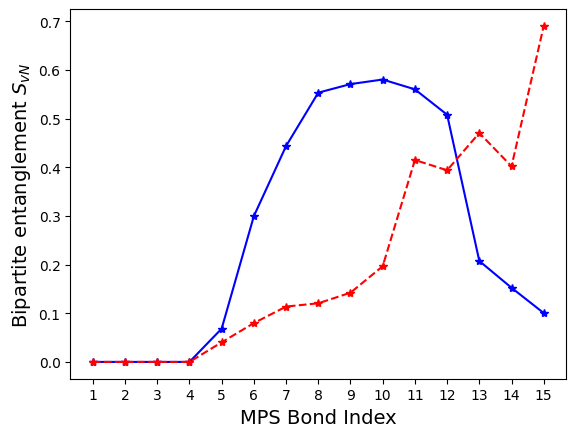

In [38]:
import numpy as np
#hct n
hct_ent = [
    1.0571307462589112e-14,
    1.6657817819837283e-14,
    -2.5627412030519412e-15,
    -8.328908909918858e-15,
    0.09854083226572155,
    0.43213028700684303,
    0.6398918569256081,
    0.7980978057845174,
    0.8234955432070084,
    0.8370367009682153,
    0.8079002959197132,
    0.7327547086859822,
    0.29918176891328463,
    0.21979441126852023,
    0.14479697144974482
    ]

#bs n
bs_ent = [
    1.4095076616785432e-14,
    0.0,
    -1.0891650112970843e-14,
    1.6017132519074562e-15,
    0.05809410824692772,
    0.11513676671234808,
    0.16398504871409558,
    0.17382084951906845,
    0.20519049891970756,
    0.2835996257081712,
    0.5984674790137731,
    0.5680792258334835,
    0.6786581340039235,
    0.579772786988739,
    0.9958966314516116
    ]

import matplotlib.pyplot as plt
x = list(range(1, 16))
plt.plot(x, np.log(2) * np.array(hct_ent), '-*', color="blue", label=r"HCT($n_q$)")
plt.plot(x, np.log(2) * np.array(bs_ent), '--*', color="red", label=r'BS($n_q$)')

plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)

plt.xticks(x, x)
#plt.legend()
plt.savefig('./saved/n2frozen_corr_cut_entropy_hct_bs_clean.pdf', dpi=1000)

In [ ]:
### testing weighted cost functions

def get_weights(n_sym, n_qubits):
    
    weights = [0]*n_sym
    for i in range(n_sym):
        if i < n_qubits//2:
            for j in range(i+1):
                weights[j] += 1
        else:
            for j in range(i, n_sym):
                weights[j] += 1
    return weights

def nc_agg_cost_function(list_sym, Hs, cisd_gs, n_qubits, verbose=False):
    """
    CISD non-commutator cost function specialized to reduce bi partite entanglement.
    
    """

    n_sym = len(list_sym)
    weights = get_weights(n_sym, n_qubits)
    if verbose: print("Weights: ", weights)

    weights = list(reversed(range(1, n_sym+1)))
    return comm_sq_exp_fast_weighted(list_sym, Hs, cisd_gs, n_qubits, weights=weights)

def comm_sq_exp_fast_weighted(sym_ops, H, state, n_qubits, verbose=False, weights = None):
    """
    Compute sum_k <state| ( i[H, S_k] )^2 |state> efficiently.

    Parameters
    ----------
    sym_ops : list[QubitOperator]
        Symmetry operators (Pauli products).
    H : sparse operator
        Hamiltonian.
    state : np.ndarray
        State vector.
    n_qubits : int

    Returns
    -------
    float or complex
    """
    if weights is None:
        weights = [1.0]*len(sym_ops)
    assert len(weights) == len(sym_ops), "Invalid number of weights for CISD non-commutator cost function."

    psi = np.asarray(state)

    # Reused for every symmetry operator
    Hpsi = H @ psi

    total = 0.0 + 0.0j
    for w, sym in zip(weights, sym_ops):
        S = get_sparse_operator(sym, n_qubits).tocsr()

        Spsi = S @ psi
        delta = 1j * ((H @ Spsi) - (S @ Hpsi))   # delta = i[H,S]|psi>

        # <psi| (i[H,S])^2 |psi> = || delta ||^2
        total += np.vdot(delta, delta) * w

    nc_exp = np.real_if_close(total)
    if verbose: print("Exp(non-commutator^2): ", nc_exp)
    return nc_exp


### May 19, 2026 BS experiments with cost function

from quasisymmetries.metrics import get_ent, variance, comm_sq_exp_fast
from quasisymmetries.sym import hct_mod
from quasisymmetries.bs.beam import find_commuting_symmetry_generators
import matplotlib.pyplot as plt
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits, get_sparse_operator

directory = './saved/hamiltonians/'
system = 'H2O_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)

H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)
Hs = get_sparse_operator(HQ, n_qubits)

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
score_func_new = lambda sym_list: (-1) * nc_agg_cost_function(sym_list, Hs, cisd_gs, n_qubits, verbose=False)

#BS options
n_sym = n_qubits
bw = 16

#bs_sym = find_commuting_symmetry_generators(HQ, score_func=score_func, target_rank=n_sym, beam_width=bw, heavy_core_fraction=0.95, include_pairwise_products=True, pairwise_seed_terms=12, seed_with_exact_symmetries=True)

bs_sym_new_linear = find_commuting_symmetry_generators(HQ, score_func=score_func_new, target_rank=n_sym, beam_width=bw, heavy_core_fraction=0.95, include_pairwise_products=True, pairwise_seed_terms=12, seed_with_exact_symmetries=True, do_local_refine=True)

#bs_ent, _ = get_ent(bs_sym, HQ, n_qubits, log_base='e')
print("BS: ", bs_ent)

#bs_ent_new, _ = get_ent(bs_sym_new_linear, HQ, n_qubits, log_base='e')
print("BS new: ", bs_ent_new)

bs_ent_new_linear, _ = get_ent(bs_sym_new_linear, HQ, n_qubits, log_base='e')
print("BS new linear: ", bs_ent_new_linear)

BS:  [-2.4602542225702547e-13, -2.313704783319629e-13, -2.393640841092697e-13, -2.4336088699792317e-13, 0.0012622128756678132, 0.5184650661993906, 0.5184653046725759, 0.5257755698812578, 0.5257193948984871, 0.5307430278096417, 0.5298779395264096, 0.5791675003050151, 0.41167102762978997]
BS new:  [-2.531308496146318e-13, 1.9611640915154283e-07, 0.009795450420633272, 0.5268790745263863, 0.5317314393990096, 0.7137719900081877, 0.6072938645962803, 0.7094468470304105, 0.7095942726489401, 0.7095952605136663, 0.709279956956167, 0.7012227468271431, 0.2862059613317301]
BS new linear:  [-2.708944180086483e-13, -2.589040093426871e-13, -2.611244553919391e-13, -2.686739719593962e-13, 0.00126221287564159, 0.5184650661996654, 0.5184653046728487, 0.5184670623095007, 0.5257193948994098, 0.5307430278107181, 0.5298779395272317, 0.6593110650192623, 0.38779571625276155]


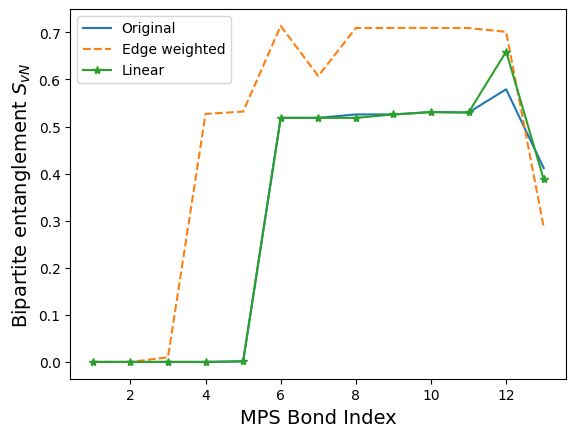

In [96]:
x = list(range(1, n_qubits))
plt.plot(x, bs_ent, label="Original")
plt.plot(x, bs_ent_new, '--', label="Edge weighted")
plt.plot(x, bs_ent_new_linear, '*-', label="Linear")

plt.xlabel("MPS Bond Index", fontsize=14)
plt.ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
plt.legend()
plt.show()

In [ ]:
from quasisymmetries.tn import *
from quasisymmetries.metrics import permute_sym_to_start
from openfermion import get_ground_state, get_sparse_operator
import numpy as np

get_permuted_bipartite_entanglement(sym_sen, HQ, n_qubits, fci_e, verbose=True, use_dmrg=False, log_base='e')

Symmetries rotated to Z on qubits:  [0, 2, 4, 6, 8, 10, 12]
Qubits permuted as:
0 -> 0
1 -> 7
2 -> 1
3 -> 8
4 -> 2
5 -> 9
6 -> 3
7 -> 10
8 -> 4
9 -> 11
10 -> 5
11 -> 12
12 -> 6
13 -> 13
Entropy of cuts (log base = e):
1 | 2 : 3.6281752352305436e-07
2 | 3 : 0.013991676953651342
3 | 4 : 0.01399167695365135
4 | 5 : 0.5331123516735568
5 | 6 : 0.5405266456673926
6 | 7 : 0.5371626902279336
7 | 8 : 0.5290470321398949
8 | 9 : 0.5290470395409336
9 | 10 : 0.5314425205368488
10 | 11 : 0.5323667874294374
11 | 12 : 1.1353677855201076
12 | 13 : 1.2688949697814822
13 | 14 : 0.6310079062706198


([3.6281752352305436e-07,
  0.013991676953651342,
  0.01399167695365135,
  0.5331123516735568,
  0.5405266456673926,
  0.5371626902279336,
  0.5290470321398949,
  0.5290470395409336,
  0.5314425205368488,
  0.5323667874294374,
  1.1353677855201076,
  1.2688949697814822,
  0.6310079062706198],
 -47.548678690230986 [] +
 0.11726474979980117 [X0 X1] +
 0.012330523065031941 [X0 X1 Z2 X7 X9] +
 -0.006294562960427263 [X0 X1 X3 Z4 Z5 X6 X7 X10] +
 0.0017126498843132458 [X0 X1 X3 Z4 Z5 Y6 X7 Y10 Z13] +
 -0.0017126498843132458 [X0 X1 X3 Z4 Z5 Y6 X7 Z10 Y13] +
 0.004581913076114019 [X0 X1 X3 Z4 Z5 Y6 Y7 X10 Z13] +
 -0.004375058174138093 [X0 X1 X3 Z4 Z5 Y6 Y7 Z10 X13] +
 -0.004581913076114019 [X0 X1 X3 Z4 Z5 Y6 Z7 X10 Y13] +
 0.004375058174138093 [X0 X1 X3 Z4 Z5 Y6 Z7 Y10 X13] +
 -0.006087708058451338 [X0 X1 Y3 Z4 Z5 Y6 X7 X13] +
 0.006110375626590941 [X0 X1 Z3 X7 X10] +
 -0.006256569198643058 [X0 X1 X4 X5 X7 X11] +
 0.0016670756939185958 [X0 X1 X4 Y5 X7 Y11 Z12] +
 -0.0016670756939185958 [X0 X1 

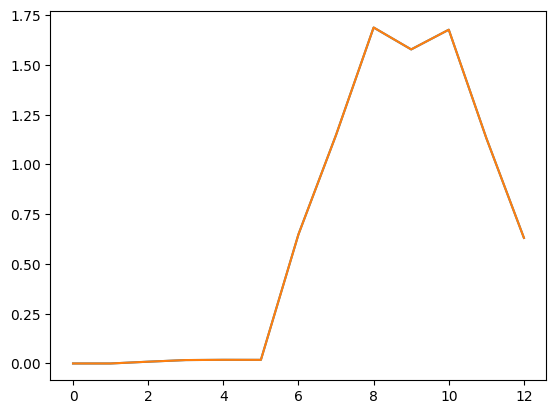

In [113]:
from quasisymmetries.metrics import get_entropies_at_cuts

ent_og = get_entropies_at_cuts(fci_gs, n_qubits, log_base='e')
plt.plot(ent_og)
plt.plot(driver.get_bipartite_entanglement(ket))

In [82]:
sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

hct_sym, _ = hct_mod(HQ, 4, sym_metric_func=sym_metric_func, use_coeffs_eps=True)

hct_sym

1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.020078393915634665 with metric value  0.06818276368593015


[1.0 [Z0 Z3 Z4 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z2 Z4 Z7]]

1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.020078393915634665 with metric value  0.06818276368593015
1.0 [Z1 Z3]  added at threshold 0.03861576966081301 with metric value  0.43288125054489696
1.0 [Z1]  added at threshold 0.04370932203524808 with metric value  0.31291682805699683
1.0 [Z0]  added at threshold 0.04370932203524808 with metric value  0.3129168280569969
1.0 [Z7]  added at threshold 0.04735193178193198 with metric value  0.31831017105633286
0
1
2
3
4
5
6
7


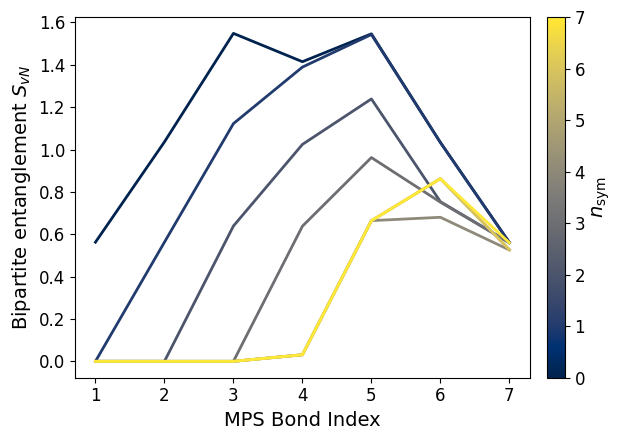

In [ ]:
### May 18, 2026 hct number of symmetry dependence:
from quasisymmetries.metrics import get_ent, variance, comm_sq_exp_fast
from quasisymmetries.sym import hct_mod
import matplotlib.pyplot as plt
import pickle
from openfermion import MolecularData, jordan_wigner, count_qubits, get_sparse_operator

directory = './saved/hamiltonians/'
system = 'H4chain_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)
Hs = get_sparse_operator(HQ, n_qubits)

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

hct_sym, _ = hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)

ent_dict = {}
n_sym_list = list(range(n_qubits))
for n_sym in n_sym_list:
    print(n_sym)
    sym_list = hct_sym[:n_sym]
    
    ent, _ = get_ent(sym_list, HQ, n_qubits, log_base='e')
    ent_dict[n_sym] = ent

import pandas as pd

# x values used in your plot
x = list(range(1, n_qubits))

# Make table:
# rows = MPS bond index
# columns = n_sym
ent_df = pd.DataFrame(ent_dict, index=x)

# Clean labels
ent_df.index.name = "MPS Bond Index"
ent_df.columns.name = "n_sym"

# Save as CSV
filename = './saved/{}_hct_nc_exp_cisd_entanglement_by_nsym'.format(system)
ent_df.to_csv(filename+'.csv')

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(6.5, 4.5))

cmap = LinearSegmentedColormap.from_list(
    "black_to_blue",
    ["#000000", "#0072B2"]  # black to color-blind friendly blue
)

# Color-blind friendly sequential colormap
cmap = plt.cm.cividis

# Normalize n_sym values onto the colormap
norm = mpl.colors.Normalize(
    vmin=min(n_sym_list),
    vmax=max(n_sym_list)
)

for n_sym, ent in ent_dict.items():
    ax.plot(
        x,
        ent,
        color=cmap(norm(n_sym)),
        linewidth=2
    )

ax.set_xlabel("MPS Bond Index", fontsize=14)
ax.set_ylabel(r"Bipartite entanglement $S_{vN}$", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x)

# Colorbar replacing the legend
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.03)
cbar.set_label(r"$n_{\mathrm{sym}}$", fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.tick_params(labelsize=12)
fig.tight_layout()

plt.savefig(filename+'.pdf', dpi=500)
plt.show()

In [13]:
hct_sym[:4]

ent, HQ_rot = get_ent(hct_sym[:4], HQ, n_qubits, log_base='e')

print(ent)

[6.661338147750933e-16, 6.661338147750933e-16, 6.661338147750933e-16, 0.031013131132808326, 0.6642281323466563, 0.6799797416626183, 0.5259581377129863]


In [ ]:
from openfermion import QubitOperator

directory = './saved/hamiltonians/'
system = 'H2O_corr'

with open(directory+system+".pkl", "rb") as f:
    data = pickle.load(f)
H, fci_e, fci_gs, cisd_e, cisd_gs = data
molecule = MolecularData(filename=directory+system)
HQ = jordan_wigner(H)
n_qubits = count_qubits(HQ)
Hs = get_sparse_operator(HQ, n_qubits)

comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

hct_sym, _ = hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)

ent, HQ_rot = get_ent(hct_sym[:n_qubits//2], HQ, n_qubits, log_base='e')
print(ent)

partitions = [
    set(range(n_qubits//2)),
    set(range(n_qubits//2, n_qubits)),
]

print("\n\n Original Hamiltonian:")
diag = diagnose_qubit_operator_partition_structure(
    HQ,
    partitions=partitions,
    include_term_records=True,
)

print("Pauli weight counts:")
print(diag.pauli_weight_counts)

print("Pauli weight |coeff| sums:")
print(diag.pauli_weight_abs_coeff_sums)

print("Cross-partition term count:")
print(diag.cross_partition_term_count)

print("Cross-partition |coeff| sum:")
print(diag.cross_partition_abs_coeff_sum)

print("Pairwise cross-partition counts:")
print(diag.partition_pair_term_counts)

print("\n\n Rotated Hamiltonian:")

diag = diagnose_qubit_operator_partition_structure(
    HQ_rot,
    partitions=partitions,
    include_term_records=True,
)

print("Pauli weight counts:")
print(diag.pauli_weight_counts)

print("Pauli weight |coeff| sums:")
print(diag.pauli_weight_abs_coeff_sums)

print("Cross-partition term count:")
print(diag.cross_partition_term_count)

print("Cross-partition |coeff| sum:")
print(diag.cross_partition_abs_coeff_sum)

print("Pairwise cross-partition counts:")
print(diag.partition_pair_term_counts)

1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7 Z12 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z8 Z10]  added at threshold 0.0252067961793301 with metric value  0.182823017249101
1.0 [Z4]  added at threshold 0.046509825381948124 with metric value  1.1530909282284412e-28
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  0.003303473460916225
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  0.0018108717025034867
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  4.841677111176281e-05
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  9.984162050804155e-05
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  0.21706520455070824
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  0.217649599575

In [19]:
from __future__ import annotations

from typing import Optional, Tuple

from openfermion import QubitOperator


def average_pauli_weight(
    hamiltonian: QubitOperator,
    coeff_abs_tol: float = 0.0,
    include_identity: bool = False,
) -> Tuple[float, float]:
    """
    Compute the unweighted and |coefficient|-weighted average Pauli weight
    of an OpenFermion QubitOperator.

    Parameters
    ----------
    hamiltonian:
        OpenFermion QubitOperator.

    coeff_abs_tol:
        Ignore terms with abs(coeff) <= coeff_abs_tol.

    include_identity:
        If True, include the identity term with Pauli weight 0.
        If False, exclude identity terms from both averages.

    Returns
    -------
    avg_weight:
        Arithmetic mean of Pauli weights over retained terms.

    abs_coeff_weighted_avg_weight:
        Mean Pauli weight weighted by abs(coeff).

    Notes
    -----
    Pauli weight is the number of non-identity factors in a Pauli product.
    """
    total_terms = 0
    total_weight = 0.0

    total_abs_coeff = 0.0
    total_abs_coeff_weighted_weight = 0.0

    for term, coeff in hamiltonian.terms.items():
        abs_coeff = abs(coeff)

        if abs_coeff <= coeff_abs_tol:
            continue

        weight = len(term)

        if weight == 0 and not include_identity:
            continue

        total_terms += 1
        total_weight += weight

        total_abs_coeff += abs_coeff
        total_abs_coeff_weighted_weight += abs_coeff * weight

    if total_terms == 0:
        return 0.0, 0.0

    avg_weight = total_weight / total_terms

    if total_abs_coeff == 0:
        abs_coeff_weighted_avg_weight = 0.0
    else:
        abs_coeff_weighted_avg_weight = (
            total_abs_coeff_weighted_weight / total_abs_coeff
        )

    return float(avg_weight), float(abs_coeff_weighted_avg_weight)


print(average_pauli_weight(HQ))
print(average_pauli_weight(HQ_rot))

(7.063594470046083, 2.2995244657786866)
(7.088479262672811, 4.5005942641507355)


In [22]:
for i in range(n_qubits):
    ent, z_rot = get_ent(hct_sym[:n_qubits//2], QubitOperator('Z{}'.format(i)), n_qubits)
    print(z_rot)

1.0 [Z0 Z4 Z5 X7 X9 X10]
1.0 [Z1 Z4 Z5 Z6 X8]
1.0 [X7]
1.0 [X8]
1.0 [Z2 Z5]
1.0 [Z5]
1.0 [Z3 Z4 X12]
1.0 [Z4 X13]
1.0 [X9]
1.0 [Z6 X11]
1.0 [X10]
1.0 [X11]
1.0 [X12]
1.0 [X13]


In [ ]:

print("\n\n Original Hamiltonian:")
diag = diagnose_qubit_operator_partition_structure(
    HQ,
    partitions=partitions,
    include_term_records=True,
)

print("Pauli weight counts:")
print(diag.pauli_weight_counts)

print("Pauli weight |coeff| sums:")
print(diag.pauli_weight_abs_coeff_sums)

print("Cross-partition term count:")
print(diag.cross_partition_term_count)

print("Cross-partition |coeff| sum:")
print(diag.cross_partition_abs_coeff_sum)

print("Pairwise cross-partition counts:")
print(diag.partition_pair_term_counts)

print("\n\n Rotated Hamiltonian:")

diag = diagnose_qubit_operator_partition_structure(
    HQ_rot,
    partitions=partitions,
    include_term_records=True,
)

print("Pauli weight counts:")
print(diag.pauli_weight_counts)

print("Pauli weight |coeff| sums:")
print(diag.pauli_weight_abs_coeff_sums)

print("Cross-partition term count:")
print(diag.cross_partition_term_count)

print("Cross-partition |coeff| sum:")
print(diag.cross_partition_abs_coeff_sum)

print("Pairwise cross-partition counts:")
print(diag.partition_pair_term_counts)

In [ ]:
### partition diagnostics

from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Dict, Iterable, List, Sequence, Set, Tuple, Any, Optional

import numpy as np
from openfermion import QubitOperator


@dataclass
class HamiltonianPartitionDiagnostics:
    n_terms: int
    total_abs_coeff: float

    pauli_weight_counts: Dict[int, int]
    pauli_weight_abs_coeff_sums: Dict[int, float]

    touched_partition_counts: Dict[int, int]
    touched_partition_abs_coeff_sums: Dict[int, float]

    cross_partition_term_count: int
    cross_partition_abs_coeff_sum: float
    cross_partition_l2_coeff_norm: float

    within_partition_term_counts: Dict[int, int]
    within_partition_abs_coeff_sums: Dict[int, float]

    partition_pair_term_counts: Dict[Tuple[int, int], int]
    partition_pair_abs_coeff_sums: Dict[Tuple[int, int], float]

    term_records: Optional[List[Dict[str, Any]]] = None


def _term_support(term: Tuple[Tuple[int, str], ...]) -> Set[int]:
    """
    Return the set of qubits on which a QubitOperator term acts nontrivially.
    """
    return {q for q, p in term if p != "I"}


def _validate_partitions(
    partitions: Sequence[Iterable[int]],
    n_qubits: Optional[int] = None,
) -> List[Set[int]]:
    """
    Validate and canonicalize a list of qubit-index sets.

    The partitions must be disjoint. They do not need to cover all qubits
    unless n_qubits is given, in which case uncovered qubits are allowed but
    reported implicitly as belonging to no partition.
    """
    part_sets = [set(p) for p in partitions]

    seen = set()
    for i, part in enumerate(part_sets):
        for q in part:
            if q < 0:
                raise ValueError(f"Negative qubit index {q} in partition {i}.")
            if q in seen:
                raise ValueError(f"Qubit {q} appears in more than one partition.")
            seen.add(q)

    if n_qubits is not None:
        for q in seen:
            if q >= n_qubits:
                raise ValueError(
                    f"Qubit {q} is outside n_qubits={n_qubits}."
                )

    return part_sets


def _infer_num_qubits_from_qubit_operator(op: QubitOperator) -> int:
    max_q = -1
    for term in op.terms:
        for q, _ in term:
            max_q = max(max_q, q)
    return max_q + 1


def diagnose_qubit_operator_partition_structure(
    hamiltonian: QubitOperator,
    partitions: Sequence[Iterable[int]],
    n_qubits: Optional[int] = None,
    coeff_abs_tol: float = 0.0,
    include_term_records: bool = False,
) -> HamiltonianPartitionDiagnostics:
    """
    Diagnose Pauli weight distribution and cross-partition structure of an
    OpenFermion QubitOperator.

    Parameters
    ----------
    hamiltonian:
        OpenFermion QubitOperator.

    partitions:
        A list of disjoint qubit-index sets. For a bipartition, use for example

            partitions = [{0, 1, 2}, {3, 4, 5}]

        For k-way partitioning, pass k sets.

    n_qubits:
        Optional total number of qubits. Used only for validation.

    coeff_abs_tol:
        Terms with abs(coeff) <= coeff_abs_tol are ignored.

    include_term_records:
        If True, return per-term diagnostic records. This can be useful for
        inspecting which terms cross partitions, but may be large.

    Returns
    -------
    HamiltonianPartitionDiagnostics

    Notes
    -----
    Pauli weight is the number of non-identity single-qubit Pauli factors.

    A term is cross-partition if it touches two or more specified partitions.
    A term that touches no specified partition, for example the identity term
    or a term on an uncovered qubit, is not counted as cross-partition.

    For k > 2 partitions, partition_pair_* counts every pair of partitions
    touched by a term. Thus a term touching three partitions contributes to
    three partition-pair counts.
    """
    if n_qubits is None:
        n_qubits = _infer_num_qubits_from_qubit_operator(hamiltonian)

    part_sets = _validate_partitions(partitions, n_qubits=n_qubits)

    qubit_to_partition: Dict[int, int] = {}
    for part_id, part in enumerate(part_sets):
        for q in part:
            qubit_to_partition[q] = part_id

    pauli_weight_counts = Counter()
    pauli_weight_abs_coeff_sums = defaultdict(float)

    touched_partition_counts = Counter()
    touched_partition_abs_coeff_sums = defaultdict(float)

    within_partition_term_counts = Counter()
    within_partition_abs_coeff_sums = defaultdict(float)

    partition_pair_term_counts = Counter()
    partition_pair_abs_coeff_sums = defaultdict(float)

    n_terms = 0
    total_abs_coeff = 0.0
    cross_partition_term_count = 0
    cross_partition_abs_coeff_sum = 0.0
    cross_partition_l2_coeff_norm_sq = 0.0

    term_records: Optional[List[Dict[str, Any]]]
    term_records = [] if include_term_records else None

    for term, coeff in hamiltonian.terms.items():
        abs_coeff = float(abs(coeff))
        if abs_coeff <= coeff_abs_tol:
            continue

        support = _term_support(term)
        weight = len(support)

        touched_parts = sorted(
            {
                qubit_to_partition[q]
                for q in support
                if q in qubit_to_partition
            }
        )
        n_touched = len(touched_parts)
        is_cross = n_touched >= 2

        n_terms += 1
        total_abs_coeff += abs_coeff

        pauli_weight_counts[weight] += 1
        pauli_weight_abs_coeff_sums[weight] += abs_coeff

        touched_partition_counts[n_touched] += 1
        touched_partition_abs_coeff_sums[n_touched] += abs_coeff

        if n_touched == 1:
            p = touched_parts[0]
            within_partition_term_counts[p] += 1
            within_partition_abs_coeff_sums[p] += abs_coeff

        if is_cross:
            cross_partition_term_count += 1
            cross_partition_abs_coeff_sum += abs_coeff
            cross_partition_l2_coeff_norm_sq += abs_coeff**2

            for a_i in range(len(touched_parts)):
                for b_i in range(a_i + 1, len(touched_parts)):
                    pair = (touched_parts[a_i], touched_parts[b_i])
                    partition_pair_term_counts[pair] += 1
                    partition_pair_abs_coeff_sums[pair] += abs_coeff

        if include_term_records:
            term_records.append(
                {
                    "term": term,
                    "coefficient": coeff,
                    "abs_coefficient": abs_coeff,
                    "support": tuple(sorted(support)),
                    "pauli_weight": weight,
                    "touched_partitions": tuple(touched_parts),
                    "n_touched_partitions": n_touched,
                    "is_cross_partition": is_cross,
                }
            )

    return HamiltonianPartitionDiagnostics(
        n_terms=n_terms,
        total_abs_coeff=total_abs_coeff,

        pauli_weight_counts=dict(sorted(pauli_weight_counts.items())),
        pauli_weight_abs_coeff_sums=dict(sorted(pauli_weight_abs_coeff_sums.items())),

        touched_partition_counts=dict(sorted(touched_partition_counts.items())),
        touched_partition_abs_coeff_sums=dict(
            sorted(touched_partition_abs_coeff_sums.items())
        ),

        cross_partition_term_count=cross_partition_term_count,
        cross_partition_abs_coeff_sum=cross_partition_abs_coeff_sum,
        cross_partition_l2_coeff_norm=float(np.sqrt(cross_partition_l2_coeff_norm_sq)),

        within_partition_term_counts=dict(sorted(within_partition_term_counts.items())),
        within_partition_abs_coeff_sums=dict(
            sorted(within_partition_abs_coeff_sums.items())
        ),

        partition_pair_term_counts=dict(sorted(partition_pair_term_counts.items())),
        partition_pair_abs_coeff_sums=dict(
            sorted(partition_pair_abs_coeff_sums.items())
        ),

        term_records=term_records,
    )

In [ ]:
for i in range(4):
    print(l1norm(commutator(HQ_rot_perm, QubitOperator('Z{}'.format(i)))))
    print(l1norm(commutator(HQ_rot, list_sym[i])))

# exact symmetries are no longer symmetries. Should instead do spin restricted orbital rotation - better, do exact symmetry preserving orbital rotations
# the approximate symmetry is worse off - indicating a possible bug?
# 

0.7189781205218583
0.7189781205218583
0.5918127921617891
0.5918127921617891
0.4477920599207637
0.4477920599207637
0.47698736263722913
0.5964838755369087


In [50]:
from quasisymmetries.clifford import check_same_spectrum
check_same_spectrum(HQ, HQ_rot_perm, n_qubits, atol=1e-5)

True

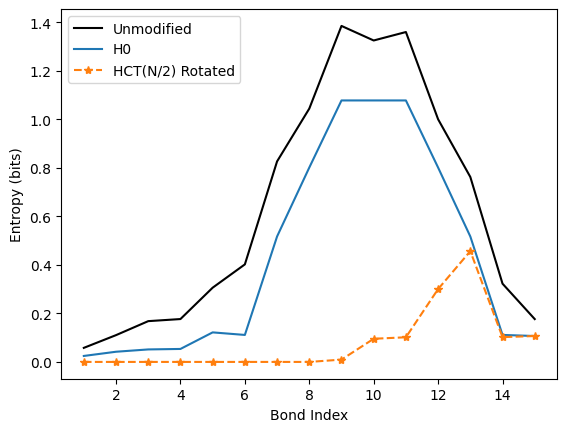

In [15]:
z, v0, v = separate_H(HQ, hct_og_sym[:n_qubits//2])
HQ_comm = z + v0
HQ_comm_s = get_sparse_operator(HQ_comm, n_qubits)

HQ_comm_gs_e, HQ_comm_gs = get_ground_state(HQ_comm_s, fci_gs)
HQ_comm_ent = get_entropies_at_cuts(HQ_comm_gs, n_qubits)

HQ_comm_perm_ent, H_comm_perm = get_ent(hct_og_sym[:n_qubits//2], HQ_comm, n_qubits)

b_idx = list(range(1, n_qubits))
plt.plot(b_idx, og_ent, color='black', label="Unmodified")

plt.plot(b_idx, HQ_comm_ent, '-', label="H0")
plt.plot(b_idx, HQ_comm_perm_ent, '--*', label="HCT(N/2) Rotated")
plt.legend()
plt.xlabel("Bond Index")
plt.ylabel("Entropy (bits)")
plt.savefig("./saved/n2_hct_parent_comp.png", dpi=500)

In [1]:
### sample code to test HCT and beam search

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator
from quasisymmetries.state_utils import get_cisd_gs, get_fci_state_openfermion
from quasisymmetries.op_utils import build_H_chain_for_R, h2o_geometry
from quasisymmetries.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod

from quasisymmetries.bs.utils import *
from quasisymmetries.bs.beam import *

# hct
from quasisymmetries.metrics import variance, comm_sq_exp_fast, find_commuting_paulis, universal_grading
from quasisymmetries.state_utils import get_hf_occ, get_hf_wfn

bl = 1.6
geometry = [
    ('Li', (0.0, 0.0, -bl/2)),
    ('H', (0.0, 0.0, bl/2))
]

# bl = 2.0
# geometry = [
#     ('N', (0.0, 0.0, -bl/2)),
#     ('N', (0.0, 0.0, bl/2))
# ]

geometry = h2o_geometry(2.1, 104.5) 

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=True
)

n_H = 4
H, molecule =  build_H_chain_for_R(1.0, n_H)

# Get second-quantized electronic Hamiltonian and wavefunctions
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)

e, gs, gs_info = get_fci_state_openfermion(molecule)
gs = gs.toarray()

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')

#pick your favorite metric functions (to lower):
comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_wfn, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_wfn, n_qubits)
var_fci = lambda s_list: variance(s_list, gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

n_sym = n_qubits//2
sym_hct, eps = hct_mod(HQ, n_sym, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
sym_sen = get_seniority_symmetries(n_qubits)
sym_quar = get_quartic_symmetries(n_qubits)

print("\nBeam Search with exact-symmetry seeding:")
sym_bs = find_commuting_symmetry_generators(
    HQ,
    target_rank=n_sym,
    beam_width=16,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    score_func= sym_group_score_func # this function maximizes the cost function TODO invert this
)
for s in sym_bs:
    print("  ", s)

assert False
# evaluate metrics
from quasisymmetries.metrics import universal_grading, entropy_pauli_syms, find_commuting_paulis, get_ent

print("Non-commutativity")
print("HCT:{}".format(universal_grading(sym_hct, HQ)))
print("Seniority:{}".format(universal_grading(sym_sen, HQ)))
print("Quartic:{}".format(universal_grading(sym_quar, HQ)))
print("BS:{}".format(universal_grading(sym_bs, HQ)))

print("Entropies:")
print("HCT: ", entropy_pauli_syms(sym_hct, gs, n_qubits))
print("Seniority: ", entropy_pauli_syms(sym_sen, gs, n_qubits))
print("Quartic: ", entropy_pauli_syms(sym_quar, gs, n_qubits))
print("BS: ", entropy_pauli_syms(sym_bs, gs, n_qubits))

print("HCT, SEN, QUARTIC, BS (non commuting terms)")
_ = find_commuting_paulis(HQ, sym_hct)
_ = find_commuting_paulis(HQ, sym_sen)
_ = find_commuting_paulis(HQ, sym_quar)
_ = find_commuting_paulis(HQ, sym_bs)

from quasisymmetries.tn import find_dmrg_conv_bd
from quasisymmetries.metrics import get_BO_energies

print("Minimum single sector energies:")
h2o_bo_e_hct = get_BO_energies(HQ, sym_hct, n_qubits)
print("HCT: ", min(h2o_bo_e_hct))

h2o_bo_e_sen = get_BO_energies(HQ, sym_sen, n_qubits)
print("Sen: ", min(h2o_bo_e_sen))

h2o_bo_e_bs = get_BO_energies(HQ, sym_bs, n_qubits)
print("BS: ", min(h2o_bo_e_bs))

best_bs_hct, tree = bs_hct(HQ, n_sym=n_sym, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
sym_bs_hct = best_bs_hct.syms
bs_hct_e = get_BO_energies(HQ, sym_bs_hct, n_qubits)
print("BS HCT: ", min(bs_hct_e))
bs_hct_ent, H_perm_bs_hct, gs_bs_hct = get_ent(sym_bs_hct, HQ, n_qubits, verbose=True, return_state=True)
bs_hct_bd = find_dmrg_conv_bd(H_perm_bs_hct, n_qubits, e, 20, n_sweeps=50, reps=20)
print("DMRG bd for convergence for BS-HCT: ", bs_hct_bd)


# max_bd=20
# og_bd = find_dmrg_conv_bd(HQ, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence for original Hamiltonian: ", og_bd)

# # bi-partite entanglement
# print("Sen")
# sen_ent, H_perm_sen, gs_sen = get_ent(sym_sen, HQ, n_qubits, verbose=True, return_state=True)
# sen_bd = find_dmrg_conv_bd(H_perm_sen, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", sen_bd)

# print("HCT N/2 syms")
# hct_ent, H_perm_hct, gs_hct = get_ent(sym_hct, HQ, n_qubits, verbose=True, return_state=True)
# hct_bd = find_dmrg_conv_bd(H_perm_hct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", hct_bd)

# print("BS N/2 syms")
# bs_ent, H_perm_bs, gs_bs = get_ent(sym_bs, HQ, n_qubits, verbose=True, return_state=True)
# bs_bd = find_dmrg_conv_bd(H_perm_bs, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", bs_bd)

/Users/praveenjayakumar/Jay Family Dropbox/praveen jayakumar/6.To-Fro Praveen/UToronto/codes backup/seniority/QuasiSymmetries/src/state_utils.py:405: ComplexWarning: Casting complex values to real discards the imaginary part
  wfs[iindx] = gs[iidx]


1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.02616133069920393 with metric value  0.0009667622051704246

Beam Search with exact-symmetry seeding:
   1.0 [Z0 Z3 Z4 Z7]
   1.0 [Z1 Z3 Z5 Z7]
   1.0 [Z2 Z3 Z6 Z7]
   1.0 [Z0 Z1 Z6 Z7]


AssertionError: 

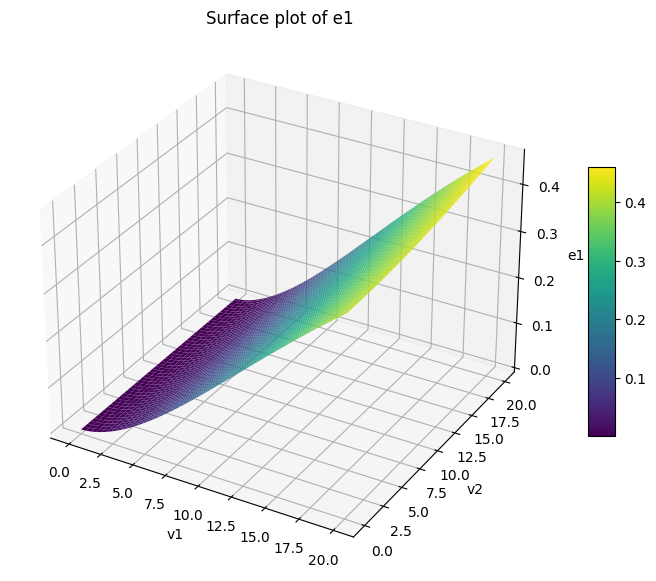

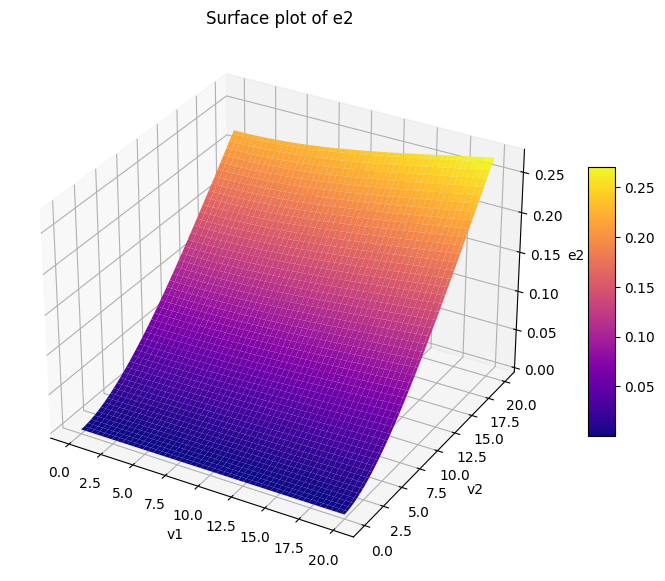

In [ ]:
#test example
from quasisymmetries.metrics import get_entropies_at_cuts

def test_example(v1, v2):
    a, b, c = 10, 20, 30
    H0 = QubitOperator('Z0', a) + QubitOperator('Z1', b) + QubitOperator('Z2', c)
    u, v = np.linalg.eigh(get_sparse_operator(H0).toarray())
    HQ = H0 + QubitOperator('X0 X1', v1) + QubitOperator('X1 X2', v2)
    gs_e, psi = get_ground_state(get_sparse_operator(HQ, 3))
    
    return get_entropies_at_cuts(psi, 3)

import numpy as np
import matplotlib.pyplot as plt


# Grid for v1 and v2 from 0 to 20
v1_vals = np.linspace(0, 20, 100)
v2_vals = np.linspace(0, 20, 100)

V1, V2 = np.meshgrid(v1_vals, v2_vals)

# Evaluate e1 and e2 over the grid
E1 = np.zeros_like(V1)
E2 = np.zeros_like(V2)

for i in range(V1.shape[0]):
    for j in range(V1.shape[1]):
        e1, e2 = test_example(V1[i, j], V2[i, j])
        E1[i, j] = e1
        E2[i, j] = e2


# Plot e1 surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(V1, V2, E1, cmap="viridis", edgecolor="none")

ax.set_title("Surface plot of e1")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.set_zlabel("e1")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()


# Plot e2 surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(V1, V2, E2, cmap="plasma", edgecolor="none")

ax.set_title("Surface plot of e2")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.set_zlabel("e2")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()

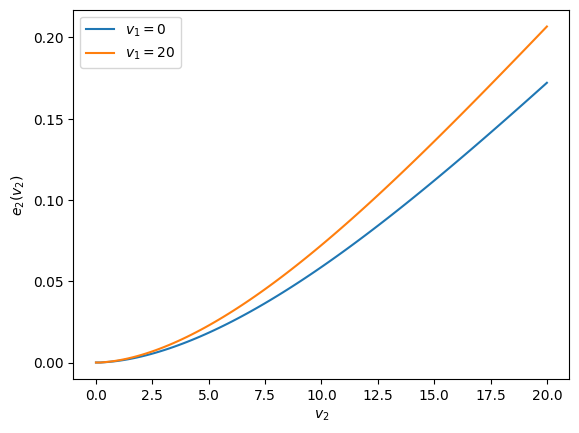

In [177]:
def test_example(v1, v2):
    a, b, c = 10, 20, 30
    H0 = QubitOperator('Z0 Z1', a) + QubitOperator('Z1', b) + QubitOperator('Z2', c)
    u, v = np.linalg.eigh(get_sparse_operator(H0).toarray())
    HQ = H0 + QubitOperator('X0', v1) + QubitOperator('X1 X2', v2)
    gs_e, psi = get_ground_state(get_sparse_operator(HQ, 3))
    
    return get_entropies_at_cuts(psi, 3)

v2_list = np.linspace(0, 20, 100)
e2_low = [test_example(0, v2)[1] for v2 in v2_list]
e2_high = [test_example(20, v2)[1] for v2 in v2_list]
plt.plot(v1_list, e2_low, label=r"$v_1 = 0$")
plt.plot(v1_list, e2_high, label=r"$v_1 = 20$")
plt.xlabel(r"$v_2$")
plt.ylabel(r"$e_2(v_2)$")
plt.legend()
#plt.savefig("./saved/toy_ent2_v2.png", dpi=300)

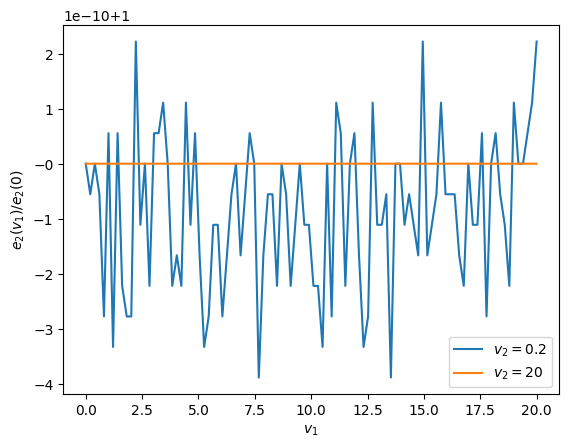

In [176]:
v1_list = np.linspace(0, 20, 100)
e2_low = [test_example(v1, 0.2)[1] for v1 in v1_list]
e2_high = [test_example(v1, 20)[1] for v1 in v1_list]
plt.plot(v1_list, e2_low/e2_low[0], label=r"$v_2=0.2$")
plt.plot(v1_list, e2_high/e2_high[0], label=r"$v_2=20$")
plt.xlabel(r"$v_1$")
plt.ylabel(r"$e_2(v_1)/e_2(0)$")
plt.legend()
#plt.savefig("./saved/toy_ent2_v1.png", dpi=300)

In [ ]:
### make Hamiltonian library
# save Hamiltonian molecule object, ferm op, fci e, fci, cisd e, cisd

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
import pickle as pkl

from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator
from quasisymmetries.state_utils import get_cisd_gs, get_fci_state_openfermion
from quasisymmetries.op_utils import build_H_chain_for_R, h2o_geometry
from quasisymmetries.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod

from quasisymmetries.bs.utils import *
from quasisymmetries.bs.beam import *

# hct
from quasisymmetries.metrics import variance, comm_sq_exp_fast, find_commuting_paulis, universal_grading
from quasisymmetries.state_utils import get_hf_occ, get_hf_wfn

'''
systems: H4 linear, H4 square, 
LiH, H2O, N2 (eqm, corr, diss)

'''

directory = "./saved/hamiltonians/"

systems = [
    'H4chain_eqm',
    'H4chain_corr',
    'H4chain_diss',
    'H4rect_corr',
    'H4rect_diss',
    'LiH_eqm',
    'LiH_corr',
    'H2O_eqm',
    'H2O_corr',
    'H2O_diss',
    'N2frozen_eqm',
    'N2frozen_corr',
    'N2frozen_diss'
]

bl = 1.6

geometry = h2o_geometry(2.1, 104.5) 

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=True
)

# n_H = 4
# H, molecule =  build_H_chain_for_R(1.0, n_H)

# Get second-quantized electronic Hamiltonian and wavefunctions
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)

e, gs, gs_info = get_fci_state_openfermion(molecule)
gs = gs.toarray()

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')


In [129]:
import pickle

# bl = 2.2
# geometry = [
#     ('N', (0.0, 0.0, -bl/2)),
#     ('N', (0.0, 0.0, bl/2))
# ]

def h4_rect_geometry(bla, blb):
    return [
        ('H', (-bla/2, -blb/2, 0.0)),
        ('H', (-bla/2, blb/2, 0.0)),
        ('H', (bla/2, -blb/2, 0.0)),
        ('H', (bla/2, blb/2, 0.0))
    ]

def h4_chain_geometry(bl):
    return [
        ('H', (-1.5*bl, 0.0, 0.0)),
        ('H', (-0.5*bl, 0.0, 0.0)),
        ('H', (0.5*bl, 0.0, 0.0)),
        ('H', (1.5*bl, 0.0, 0.0))
    ]

def lih_geometry(bl):
    return [
    ('Li', (0.0, 0.0, -bl/2)),
    ('H', (0.0, 0.0, bl/2))
]

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# fci_es = []
# cisd_es = []
geometry = lih_geometry(4.0)
# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=False
)

H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)
fci_e, fci_gs = get_ground_state(Hs)
hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')

print(bl, fci_e, abs(cisd_e - fci_e))

#H, (fci_e, fci_wfn), (cisd_e, cisd_wfn)
data = (H, fci_e, fci_gs, cisd_e, cisd_wfn)
directory = "./saved/hamiltonians/"
filename = "LIH_corr"
with open(directory+filename+".pkl", "wb") as f:
    pickle.dump(data, f)



molecule.filename = directory + filename
molecule.save()
print(fci_e, cisd_e)

/Users/praveenjayakumar/Jay Family Dropbox/praveen jayakumar/6.To-Fro Praveen/UToronto/codes backup/seniority/QuasiSymmetries/src/state_utils.py:356: ComplexWarning: Casting complex values to real discards the imaginary part
  elements_sum[iidx, jidx] += opspar[iindx, jindx]


5.5 -7.784278178715401 0.00014137851695572579
-7.784278178715401 -7.7841368001984454


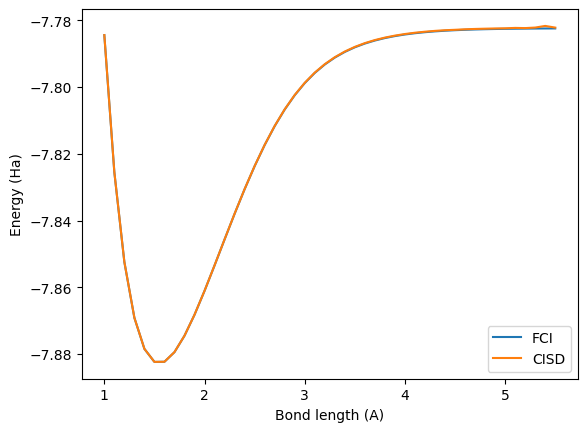

In [127]:
bls = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5]
plt.plot(bls, fci_es, label="FCI")
plt.plot(bls, cisd_es, label="CISD")
plt.xlabel("Bond length (A)")
plt.ylabel("Energy (Ha)")
plt.legend()
plt.savefig("./saved/lih_curve.png", dpi=300)

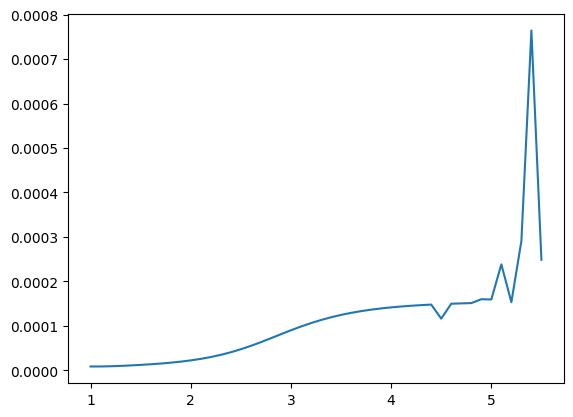

In [126]:
plt.plot(bls, np.abs(np.array(fci_es) - np.array(cisd_es)))

In [ ]:
data = (H, fci_e, fci_gs, cisd_e, cisd_wfn)
directory = "./saved/hamiltonians/"
filename = "N2frozen_eqm"
with open(directory+filename+".pkl", "wb") as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)

with open(directory+filename+".pkl", "rb") as f:
    data = pickle.load(f)

In [21]:
bshct_ent, H_perm_bshct, gs_bshct = get_ent(best_bs_hct_h2o.syms, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_bd = find_dmrg_conv_bd(H_perm_bshct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [4, 0, 1, 6, 5, 2, 3]
Qubits permuted as:
0 -> 1
1 -> 2
2 -> 5
3 -> 6
4 -> 0
5 -> 4
6 -> 3
7 -> 7
8 -> 8
9 -> 9
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.3315635639686685e-13
2 | 3 : -3.3315635639686685e-13
3 | 4 : -3.3123430049457656e-13
4 | 5 : -3.3443772699839373e-13
5 | 6 : 0.0018209882562897981
6 | 7 : 0.0018214388629736315
7 | 8 : 0.0018241377119056375
8 | 9 : 0.9112147671837455
9 | 10 : 1.77287569593224
10 | 11 : 2.2518853919820496
11 | 12 : 2.413754329614614
12 | 13 : 1.6302566081085466
13 | 14 : 0.9103503982875277
Bond dimension:  1
Energy difference: 0.4490013633525791
Energy difference: 0.3872114259063153
Energy difference: 0.5523827356531115
Energy difference: 0.32322391471583956
Energy difference: 0.5916234643429732
Energy difference: 2.171840962395706
Energy difference: 0.5226989094830117
Energy difference: 0.697641975384073
Energy difference: 0.714707484007107
Energy difference: 3.207236702463703
Energy dif

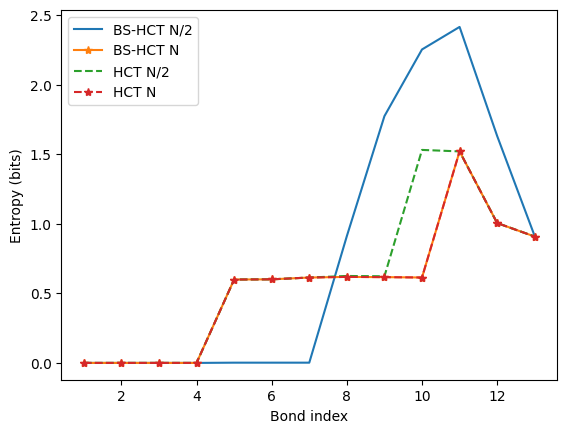

In [74]:
import matplotlib.pyplot as plt

plt.plot(range(1, n_qubits), bshct_ent, '-', label="BS-HCT N/2")
plt.plot(range(1, n_qubits), bshct_ent_N, '-*', label="BS-HCT N")
plt.plot(range(1, n_qubits), hct_ent, '--', label="HCT N/2")
plt.plot(range(1, n_qubits), hct_ent_N, '--*', label="HCT N")
plt.xlabel("Bond index")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.savefig("./saved/h2o2.1_entropy.png", dpi=300)

In [22]:
hct_ent, H_perm_hct, gs_hct = get_ent(sym_hct, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
hct_bd = find_dmrg_conv_bd(H_perm_hct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 7, 5, 9]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 7
3 -> 8
4 -> 2
5 -> 5
6 -> 3
7 -> 4
8 -> 9
9 -> 6
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.542989713220604e-13
2 | 3 : -3.382818388029743e-13
3 | 4 : -3.613465096304585e-13
4 | 5 : -3.6198719493122194e-13
5 | 6 : 0.5990494451345876
6 | 7 : 0.6005431436846267
7 | 8 : 0.6134293020631965
8 | 9 : 0.624671788307487
9 | 10 : 0.6223793460630306
10 | 11 : 1.5301146098001375
11 | 12 : 1.5195279001920878
12 | 13 : 1.0047696236431871
13 | 14 : 0.9078590647257538
Bond dimension:  1
Energy difference: 2.707558136136555
Energy difference: 2.7075581361365835
Energy difference: 1.948581343028394
Energy difference: 2.3092844981337066
Energy difference: 1.9909344459432248
Energy difference: 2.078848516446527
Energy difference: 1.2095611581859487
Energy difference: 0.9857103944094376
Energy difference: 1.011642196744205
Energy difference: 1.7882926794721214
Energy difference: 1.

In [30]:
bshct_ent_N, H_perm_bshct_N, gs_bshct_N = get_ent(best_bs_hct_h2o_N.syms, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_N_bd = find_dmrg_conv_bd(H_perm_bshct_N, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [4, 0, 1, 6, 7, 5, 9, 8, 2, 3, 10, 11, 12, 13]
Qubits permuted as:
0 -> 1
1 -> 2
2 -> 8
3 -> 9
4 -> 0
5 -> 5
6 -> 3
7 -> 4
8 -> 7
9 -> 6
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.453293771113721e-13
2 | 3 : -3.453293771113721e-13
3 | 4 : -3.453293771113721e-13
4 | 5 : -3.4597006241213556e-13
5 | 6 : 0.5990494451340407
6 | 7 : 0.6005431436840817
7 | 8 : 0.6134293020620548
8 | 9 : 0.6180219311741436
9 | 10 : 0.6163041680222977
10 | 11 : 0.6136178383976391
11 | 12 : 1.5195279001915898
12 | 13 : 1.004769623643144
13 | 14 : 0.9078590647261401
Bond dimension:  1
Energy difference: 0.991540974723577
Energy difference: 0.019665461255641503
Energy difference: 1.0395113781401193
Energy difference: 0.9748872910398063
Energy difference: 0.3256992482727412
Energy difference: 0.3285237178214402
Energy difference: 0.9759766238714889
Energy difference: 0.5028801695432605
Energy difference: 0.722748927781808
Energy difference: 0.369985215

In [64]:

sym_hct_N, eps = hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)
hct_ent_N, H_perm_hct_N, gs_hct_N = get_ent(sym_hct_N, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_N_bd = find_dmrg_conv_bd(H_perm_hct_N, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7 Z12 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z8 Z10]  added at threshold 0.0252067961793301 with metric value  0.182823017249101
1.0 [Z4]  added at threshold 0.046509825381948124 with metric value  1.1530909282284412e-28
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  0.003303473460916225
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  0.0018108717025034867
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  4.841677111176281e-05
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  9.984162050804155e-05
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  0.21706520455070824
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  0.217649599575

In [29]:
best_bs_hct_h2o_N = bs_hct(HQ, n_sym=n_qubits, use_coeffs_eps=True, sym_metric_func=sym_metric_func)

At threshold e: 0.0252067961793301, 4 new directions found!
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  5
1
Current directions:
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]]
At threshold e: 0.046509825381948124, 4 new directions found!
A

In [ ]:
get_ent(hct_sym_all[0], HQ, n_qubits, True)

1 | 2 : -1.8626003064142167e-11
2 | 3 : -1.862472169354059e-11
3 | 4 : -1.8589484001997263e-11
4 | 5 : -1.859012468729805e-11
5 | 6 : 9.325642496067277e-06
6 | 7 : 0.013589402709801978
7 | 8 : 1.0094913988656322
8 | 9 : 0.6529287340972989
9 | 10 : 0.6530999912165025
10 | 11 : 1.545561415894893
11 | 12 : 0.919929031119459
12 | 13 : 1.6216310804656038e-05
13 | 14 : 1.1549854420443874e-05


Symmetries rotated to Z on qubits:  [0, 1, 6, 10, 4, 8, 9, 5, 7, 13, 12, 11, 2, 3]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 12
3 -> 13
4 -> 4
5 -> 7
6 -> 2
7 -> 8
8 -> 5
9 -> 6
10 -> 3
11 -> 11
12 -> 10
13 -> 9
Entropy of cuts (bits):
1 | 2 : -2.419612106922354e-11
2 | 3 : -2.3943050375409497e-11
3 | 4 : -2.3883466642435577e-11
4 | 5 : -2.387962253063081e-11
5 | 6 : 9.325637147730104e-06
6 | 7 : 0.013589399064513268
7 | 8 : 1.009491396380082
8 | 9 : 0.6529287295561005
9 | 10 : 0.6530999866766254
10 | 11 : 1.5455614156570974
11 | 12 : 0.9199290292679513
12 | 13 : 1.6216304951232176e-05
13 | 14 : 1.1549848818426151e-05


([-2.419612106922354e-11,
  -2.3943050375409497e-11,
  -2.3883466642435577e-11,
  -2.387962253063081e-11,
  9.325637147730104e-06,
  0.013589399064513268,
  1.009491396380082,
  0.6529287295561005,
  0.6530999866766254,
  1.5455614156570974,
  0.9199290292679513,
  1.6216304951232176e-05,
  1.1549848818426151e-05],
 -47.56858591958542 [] +
 -0.00038330121110388026 [Z0 Z1 Z2 Z3 X4 X5 Z6 X10 Z11] +
 -2.3363266702903777e-05 [Z0 Z1 Z2 Z3 X4 X5 Z6 Z10] +
 -1.9586311709278803e-05 [Z0 Z1 Z2 X4 X5] +
 0.001599967787036542 [Z0 Z1 Z2 X4 X5 X6] +
 -9.198259972141156e-05 [Z0 Z1 Z2 X4 X5 X6 X7] +
 -0.0001118561470327116 [Z0 Z1 Z2 X4 X5 X6 X8] +
 7.311109362196401e-05 [Z0 Z1 Z2 X4 X5 X6 X12 X13] +
 -9.198259972141156e-05 [Z0 Z1 Z2 X4 X5 Y6 Y7 Z9 Z11] +
 -0.0001118561470327116 [Z0 Z1 Z2 X4 X5 Y6 Y8 Z9 Z11] +
 7.311109362196401e-05 [Z0 Z1 Z2 X4 X5 Y6 Z9 Z11 X12 Y13] +
 0.000249623031097642 [Z0 Z1 Z2 X4 X5 Y6 Z9 Z11 Y12] +
 5.38404778861476e-05 [Z0 Z1 Z2 X4 X5 Z6 Z7 Z9 Z11] +
 5.269788084831696e-05 [Z0

In [30]:
sym_hct_all, hct_all_eps = find_approx_symm(HQ, n_qubits)
ent_hct_all = get_ent(sym_hct_all, HQ, n_qubits)

sym_bs_all = find_commuting_symmetry_generators(
    HQ,
    target_rank=n_qubits,
    beam_width=16,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    #score_func=lambda s: -comm_sq_exp_fast(s, Hs, gs, n_qubits)# Change or remove as needed #variance(s, cisd_wfn, n_qubits) # 
)
ent_sym_bs_all = get_ent(sym_bs_all, HQ, n_qubits)

Added Pauli string: 1.0 [Z6 Z7 Z12 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z4 Z5] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z5] at threshold: 0.4802901640293906 with metric value: 1.0384480445408846
Added Pauli string: 1.0 [Z2] at threshold: 0.4802901640293906 with metric value: 5.332034886889228
Added Pauli string: 1.0 [Z3] at threshold: 0.4802901640293906 with metric value: 5.332034886889229
Added Pauli string: 1.0 [Z7] at threshold: 0.4802901640293906 with metric value: 7.679225298043392
Added Pauli string: 1.0 [Z13] at threshold: 0.4802901640293906 with metric value: 7.719717232749654
Added Pauli string: 1.0 [Z12] at threshold: 0.4802901640293906 with metric value: 7.719717232749655
Added Pauli string: 1.0 [Z9] at threshold: 0.4802901640293906 with me

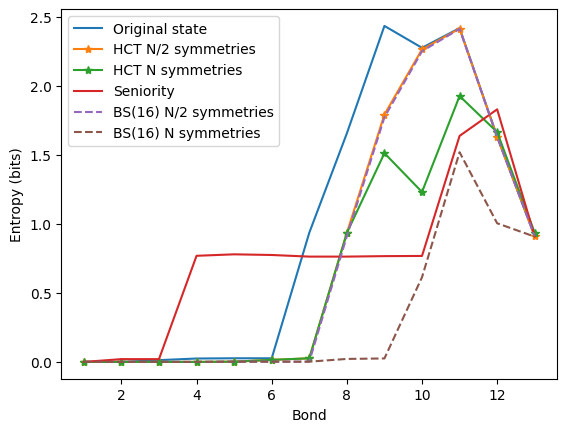

In [32]:
plt.plot(range(1, n_qubits), ent_og, label="Original state")
plt.plot(range(1, n_qubits), ent_hct[0], '-*', label="HCT N/2 symmetries")
plt.plot(range(1, n_qubits), ent_hct_all[0], '-*', label="HCT N symmetries")
plt.plot(range(1, n_qubits), ent_sen[0], label="Seniority")
plt.plot(range(1, n_qubits), ent_bs[0], '--', label="BS(16) N/2 symmetries")
plt.plot(range(1, n_qubits), ent_sym_bs_all[0], '--', label="BS(16) N symmetries")

plt.xlabel("Bond")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.savefig("./saved/bi_ent_h2o_2.1.png")

In [ ]:
sym_mapped_qubits = [4, 2]

n_qubits =6
n_sym = len(sym_mapped_qubits) #locations of symmetry qubits - should go to the beginning
perm = []
ns=0
nns =0
for i in range(n_qubits): #qubit count
    if i in sym_mapped_qubits: 
        assert ns < n_sym, "Too many symmetry indices!"
        perm.append(sym_mapped_qubits.index(i))
        ns +=1
    else:
        perm.append(n_sym + nns)
        nns += 1

print(perm)

from openfermion import QubitOperator
from quasisymmetries.clifford import permute_qubits_in_qubit_operator
QO = QubitOperator('X0 Y1 Z2 Z3 Z4', 1.0) +  QubitOperator('Y0 Z2', 2.0)
permute_qubits_in_qubit_operator(QO, perm)

[2, 3, 1, 4, 0, 5]


1.0 [Z0 Z1 X2 Y3 Z4] +
2.0 [Z1 Y2]

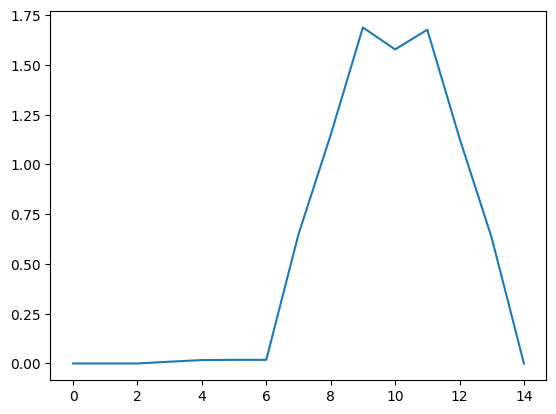

In [9]:
import numpy as np


def bipartite_von_neumann_entropy_from_state(
    psi: np.ndarray,
    n_qubits: int,
    cut: int,
    log_base: float = np.e,
    check_normalized: bool = True,
) -> float:
    """
    Entanglement entropy across the cut:
        A = qubits [0, ..., cut-1]
        B = qubits [cut, ..., n_qubits-1]

    Parameters
    ----------
    psi : np.ndarray
        Statevector of shape (2**n_qubits,).
    n_qubits : int
        Number of qubits.
    cut : int
        Size of subsystem A.
    log_base : float
        Use np.e for nats, 2 for bits.
    check_normalized : bool
        Whether to verify normalization.

    Returns
    -------
    float
        von Neumann entropy S(A) = -Tr(rho_A log rho_A).
    """
    psi = np.asarray(psi, dtype=complex).reshape(-1)

    if psi.shape[0] != 2**n_qubits:
        raise ValueError("Statevector length does not match n_qubits.")

    if not (0 <= cut <= n_qubits):
        raise ValueError("cut must satisfy 0 <= cut <= n_qubits.")

    if check_normalized:
        norm = np.vdot(psi, psi).real
        if not np.isclose(norm, 1.0, atol=1e-10):
            raise ValueError(f"Statevector is not normalized. Norm = {norm}")

    # Edge cuts: entropy is zero for empty/full subsystem.
    if cut == 0 or cut == n_qubits:
        return 0.0

    # Reshape into Schmidt matrix Psi_{a,b}
    psi_matrix = psi.reshape(2**cut, 2**(n_qubits - cut))

    # Singular values are Schmidt coefficients
    svals = np.linalg.svd(psi_matrix, compute_uv=False)
    probs = svals**2

    # Numerical cleanup
    probs = probs[probs > 1e-15]

    if log_base == np.e:
        logs = np.log(probs)
    elif log_base == 2:
        logs = np.log2(probs)
    else:
        logs = np.log(probs) / np.log(log_base)

    return float(-np.sum(probs * logs))


def bipartite_entropy_curve(
    psi: np.ndarray,
    n_qubits: int,
    log_base: float = np.e,
) -> np.ndarray:
    """
    Return S_vN(cut) for cut = 0, 1, ..., n_qubits.
    """
    return np.array([
        bipartite_von_neumann_entropy_from_state(
            psi=psi,
            n_qubits=n_qubits,
            cut=cut,
            log_base=log_base,
        )
        for cut in range(n_qubits + 1)
    ])

plt.plot(bipartite_entropy_curve(gs, n_qubits))

In [ ]:
res = build_symmetry_block_structure_with_packed_qubits(
    hamiltonian=HQ,
    symmetries=sym_hct,
    n_qubits=n_qubits,
)
res.clifford_result.mapped_qubits

[7, 3, 6, 5, 4, 0, 1, 2]

In [20]:
#non comm hf

from quasisymmetries.state_utils import get_hf_occ, get_hf_wfn, get_fci_state_from_molecule

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals)
hf_wfn = get_hf_wfn(hf_occ)

def comm_sq_exp(sym_ops, HQ, state, n_qubits):
    """
    sym_ops list[QubitOperator] (Pauli products)

    state np.array

    """
    HQs = get_sparse_operator(HQ, n_qubits)
    sym_s = [get_sparse_operator(sym, n_qubits) for sym in sym_ops]

    comms = [1.j*commutator(HQs, sym) for sym in sym_s]
    return np.sum([expectation(comm @ comm , state) for comm in comms])

comm_sq_exp(sym_hct, HQ, hf_wfn, n_qubits)

%timeit comm_sq_exp_hf(sym_hct, HQ, hf_occ)

806 ms ± 14 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
import numpy as np
from openfermion import commutator

def is_diagonal_pauli_term(term):
    """
    term: tuple like ((0, 'Z'), (3, 'Z'))
    Returns True iff term contains only Z operators (I is absent implicitly).
    """
    return all(pauli == 'Z' for _, pauli in term)

def pauli_z_eigenvalue_on_bitstring(term, bitstring):
    """
    Evaluate <b|P|b> for a diagonal Pauli term P on computational basis state |b>.

    Parameters
    ----------
    term : tuple
        OpenFermion Pauli term representation, e.g. ((0, 'Z'), (3, 'Z'))
    bitstring : sequence[int]
        Occupation / computational basis bits, length n_qubits, values 0 or 1

    Returns
    -------
    int
        ±1
    """
    eig = 1
    for q, pauli in term:
        if pauli != 'Z':
            return 0
        eig *= -1 if bitstring[q] else 1
    return eig

def comm_sq_exp_hf_single_sym(sym_op, HQ, bitstring):
    """
    Compute <HF| ( i[H, S] )^2 |HF> using symbolic Pauli algebra only.

    Parameters
    ----------
    sym_op : QubitOperator
        One Pauli-product symmetry operator S.
    HQ : QubitOperator
        Hamiltonian.
    bitstring : sequence[int]
        HF determinant in computational-basis / occupation representation.

    Returns
    -------
    float
    """
    C = 1j * commutator(HQ, sym_op)   # symbolic operator
    C2 = C * C                        # symbolic Pauli expansion

    total = 0.0 + 0.0j
    for term, coeff in C2.terms.items():
        if is_diagonal_pauli_term(term):
            total += coeff * pauli_z_eigenvalue_on_bitstring(term, bitstring)

    return float(np.real_if_close(total))

def comm_sq_exp_hf(sym_ops, HQ, bitstring):
    """
    Sum_k <HF| ( i[H, S_k] )^2 |HF>.
    """
    return sum(comm_sq_exp_hf_single_sym(sym, HQ, bitstring) for sym in sym_ops)

In [13]:
comm = 1.j*get_sparse_operator(commutator(HQ, syms[4]))
print("hey")
from openfermion import expectation
expectation(comm @ comm, hf_wfn)

hey


(0.4162019677952294+0j)

In [14]:
commutator(comm, comm)

<16384x16384 sparse matrix of type '<class 'numpy.complex128'>'
	with 0 stored elements in Compressed Sparse Column format>

In [89]:
#syms = sym_all[:4] + [QubitOperator('Z6', 1.0), QubitOperator('Z8', 1.0)]
print("HCT:\n{}\n{}".format(syms, universal_grading(syms, HQ)))

find_commuting_paulis(HQ, syms)

entropy_pauli_syms(syms, gs, n_qubits)

HCT:
[1.0 [Z0 Z2 Z5 Z6 Z9 Z10 Z13], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13], 1.0 [Z4 Z5 Z12 Z13], 1.0 [Z8 Z9], 1.0 [Z8], 1.0 [Z0], 1.0 [Z1]]
8.72264398733759
558/1086 Terms in H found to commuting with all symmetries.


(0.00970958823587644+3.520912706563328e-17j)

In [77]:
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
sym_all, eps = find_approx_symm(jordan_wigner(H), n_qubits)

Added Pauli string: Z8 Z9 at threshold: 0.0
Added Pauli string: Z6 Z7 at threshold: 0.0
Added Pauli string: Z1 Z3 Z5 Z7 Z9 Z11 at threshold: 0.0
Added Pauli string: Z0 Z2 Z4 Z7 Z9 Z10 at threshold: 0.0
Added Pauli string: Z11 at threshold: 0.041776477932657784
Added Pauli string: Z10 at threshold: 0.041776477932657784
Added Pauli string: Z9 at threshold: 0.041776477932657784
Added Pauli string: Z7 at threshold: 0.041776477932657784
Added Pauli string: Z5 at threshold: 0.041776477932657784
Added Pauli string: Z4 at threshold: 0.041776477932657784
Added Pauli string: Z3 at threshold: 0.041776477932657784
Added Pauli string: Z2 at threshold: 0.041776477932657784


In [31]:
i, j, a, b = 0, 1, 2, 3
print(QubitOperator('Z{} Z{} X{} X{}'.format(a, b, b, a)))

print(QubitOperator('Y{} Y{}'.format(a, b)))

(-1+0j) [Y2 Y3]
1.0 [Y2 Y3]


In [3]:
### orbital optimization with jax with seniority symmetries

from quasisymmetries.orbital_rotation import RealOrbitalRotation
import numpy as np
from openfermion import jordan_wigner, expectation, FermionOperator, get_sparse_operator


In [23]:
### to test rotations
from scipy.optimize import minimize
from quasisymmetries.ferm_utils import get_obt_expectation_from_rdms, get_chem_tbt_expectation_from_rdms, rotate_chem_obt, rotate_np_U, rotate_npnq_U, get_1_2_rdms

def cost(params, args):
    pq, rdms, n_qubits = args
    p, q = pq
    rdm_1, rdm_2 = rdms

    U = RealOrbitalRotation(n_qubits, params).get_mat_rep()
    exp_ref = np.real((1 - 2 * get_obt_expectation_from_rdms(rotate_np_U(p, U), rdm_1) 
               - 2 * get_obt_expectation_from_rdms(rotate_np_U(q, U), rdm_1) 
               + 4*get_chem_tbt_expectation_from_rdms(rotate_npnq_U(p, q, U), rdm_1, rdm_2)))
    return 1 - exp_ref**2

def cost_sum(params, args):
    rdms, n_qubits = args
    pq_list = [(2*p, 2*p+1) for p in range(n_qubits//2)]
    return np.sum([cost(params, [pq, rdms, n_qubits]) for pq in pq_list])

def minimize_something(cost_func, n_params, args, n_random_trials=1, parallel=False, print_callback=True):
    """
    Minimize a cost_func that accepts n_params parameters and arguments args

    """
    
    def call_back(params):
        print(cost_func(params, args))
    
    x0 = np.zeros(n_params)
    print("Zero init values: ", cost_func(x0, args))

    if print_callback:
        cb = call_back
    else:
        cb = None
    min_result = minimize(cost_func, x0, args=args, callback=cb)

    for n in range(n_random_trials):
        x0 = np.random.rand(n_params)
        print("Random Trial {}:".format(n+1))
        result = minimize(cost_func, x0, args=args, callback=cb)
        print("Minimum value: ", result.fun)

        if result.fun < min_result.fun:
            min_result = result
    
    print("Minimization complete, final cost func value: {}".format(min_result.fun))

    return min_result

#rdms = get_1_2_rdms(gs, n_qubits//2)
args = [rdms, n_qubits]
result = minimize_something(cost_sum, RealOrbitalRotation.num_params(n_qubits), args, 1, print_callback=False)

Zero init values:  0.0806425921800068
Random Trial 1:
Minimum value:  0.012294036798178754
Minimization complete, final cost func value: 0.00040062029848941805


In [ ]:
#save rdms
import pickle as pkl
mol ="h4"
desc = "linear1A"

mol = "lih"
desc = "1.60A"
with open("./saved/{}_{}_12rdms.pkl".format(mol, desc), "wb") as file:
    pkl.dump(rdms, file, pkl.HIGHEST_PROTOCOL)

# with open(",.saved/{}_{}_12rdms.pkl".format(mol, desc), "rb") as file:
#     rdms = pkl.load(file)

In [24]:
sym_sen_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_sen]
U = RealOrbitalRotation(n_qubits, result.x).get_exp_rep()
rotated_sym_sen_sparse = [U @ s @ U.T.conjugate() for s in sym_sen_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_sen_sparse]))

from quasisymmetries.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_sen_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.00040062029843368485+6.3428516621293604e-18j)


(0.0006457830330574557+2.280967978094365e-18j)

In [73]:
sym_bs_sparse = [get_sparse_operator(sym, n_qubits) for sym in syms]
U = RealOrbitalRotation(n_qubits, result.x).get_exp_rep()
rotated_sym_bs_sparse = [U @ s @ U.T.conjugate() for s in sym_bs_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_bs_sparse]))

from quasisymmetries.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_bs_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.006068022239659743+5.201701442697516e-18j)


(0.017921803591941877+8.71168933184308e-19j)

In [25]:
sym_quar_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_quar]
rotated_sym_quar_sparse = [U @ s @ U.T.conjugate() for s in sym_quar_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_quar_sparse]))

from quasisymmetries.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_quar_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.00041294445911810307+2.195783201381727e-18j)


(0.0006457830330571354+3.2456572784356335e-18j)

In [30]:
sym_hct = sym_all[:n_sym] 

sym_hct_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_hct]
rotated_sym_hct_sparse = [U @ s @ U.T.conjugate() for s in sym_hct_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_hct_sparse]))

from quasisymmetries.metrics import construct_projectors_sparse, entropy_pauli_sym

projs_hct = construct_projectors_sparse(rotated_sym_hct_sparse, n_qubits)
entropy_pauli_sym(projs_hct, gs, n_qubits)

(0.16711234554686627+7.521956973324997e-18j)


(0.14891424782451998+7.337035715258809e-19j)

In [29]:
entropy_pauli_syms(sym_hct, gs, n_qubits)

(0.23191903538034603-5.656118891089193e-19j)

In [107]:
sym_hct_all_approx = [sym_all[i] for i in range(len(sym_all)) if not np.isclose(eps[i], 0)]
sym_hct_all_approx[:n_sym]

[1.0 [Z4 Z5 Z6 Z7], 1.0 [Z5 Z7], 1.0 [Z6 Z7], 1.0 [Z3]]

In [99]:
sym_8 = [QubitOperator('Z0 Z1 Z2 Z3', 1.0), QubitOperator('Z2 Z3 Z4 Z5', 1.0), QubitOperator('Z4 Z5 Z6 Z7', 1.0), QubitOperator('Z8 Z9', 1.0), QubitOperator('Z10 Z11', 1.0)]
find_commuting_paulis(HQ, sym_8)

139/631 Terms in H found to commuting with all symmetries.


[(-4.135867179465941+0j) [],
 (1.0064988767016247+0j) [Z0],
 (1.0064988767016245+0j) [Z1],
 (-0.11846053917058846+0j) [Z2],
 (-0.11846053917058848+0j) [Z3],
 (-0.19809729981358296+0j) [Z4],
 (-0.19809729981358298+0j) [Z5],
 (-0.2304682262962337+0j) [Z6],
 (-0.23046822629623365+0j) [Z7],
 (-0.23046822629623354+0j) [Z8],
 (-0.23046822629623354+0j) [Z9],
 (-0.38500532493531847+0j) [Z10],
 (-0.38500532493531847+0j) [Z11],
 (0.4146416717111249+0j) [Z0 Z1],
 (0.0033343945470473+0j) [Y0 X1 X2 Y3],
 (-0.0033343945470473+0j) [Y0 Y1 X2 X3],
 (-0.0033343945470473+0j) [X0 X1 Y2 Y3],
 (0.0033343945470473+0j) [X0 Y1 Y2 X3],
 (0.005415561323476604+0j) [Y0 X1 X4 Y5],
 (-0.005415561323476604+0j) [Y0 Y1 X4 X5],
 (-0.005415561323476604+0j) [X0 X1 Y4 Y5],
 (0.005415561323476604+0j) [X0 Y1 Y4 X5],
 (0.0024544706892538383+0j) [Y0 X1 X6 Y7],
 (-0.0024544706892538383+0j) [Y0 Y1 X6 X7],
 (-0.0024544706892538383+0j) [X0 X1 Y6 Y7],
 (0.0024544706892538383+0j) [X0 Y1 Y6 X7],
 (0.002454470689253838+0j) [Y0 X1 X8 Y

In [49]:
sym_hct

def check_pauli_sym_equiv(sym_ops_1, sym_ops_2):
    """
    Check if sym op list is equivalent upto products
    Finds the null space of generator matrix to check if 

    """

    


    return

[1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z0 Z3 Z4 Z7], 1.0 [Z4 Z5 Z6 Z7]]

In [33]:
p = QubitOperator('X4 Z5 X6 Y10 Z11 Y12', 1.0)
def is_commuting(op1, op2, tol):
    
    comm = commutator(op1, op2)
    comm.compress()
    v = np.isclose(np.sum(np.abs(list(comm.terms.values()))), 0, rtol=tol)
    if not v:
        print(op1, op2)
    return v
[is_commuting(sym_op, p, 1e-5) for sym_op in sym_quar]

1.0 [Z2 Z3 Z4 Z5] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z6 Z7 Z8 Z9] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z8 Z9 Z10 Z11] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z0 Z1 Z12 Z13] 1.0 [X4 Z5 X6 Y10 Z11 Y12]


[True, False, True, False, False, True, False]

In [48]:
from openfermion import commutator
import numpy as np

for i in range(n_qubits//2):
    print(sym_sen[i])
    op = commutator(HQ, sym_quar[i])
    op.compress()
    print(len(op.terms.keys()))
    print(np.sum(np.abs(list(op.terms.values()))))

1.0 [Z0 Z1]
512
4.664423561045397
1.0 [Z2 Z3]
420
7.441657973140998
1.0 [Z4 Z5]
420
12.988906859244807
1.0 [Z6 Z7]
512
20.881601947700133
1.0 [Z8 Z9]
512
21.639267860769213
1.0 [Z10 Z11]
512
21.639267860769213
1.0 [Z12 Z13]
512
15.445385461108446


In [50]:
### orbital optimized hct
from quasisymmetries.orbital_rotation import RealOrbitalRotation
from openfermion import expectation
import numpy as np

# 1) optimize orbitals for a certain set of symmetries oo-hct
# 2) find optimal symmetries at each iteration


def variance_of_operator(Op, State):
    """
    computes the variance of a Hermitian operator <psi|H^2|psi> - <psi|H|psi>^2
    """
    first  = expectation(Op@Op, State)
    second = expectation(Op, State) ** 2
    return first - second

def variance_of_pauli(Op, state):
    exp = expectation(Op, state)
    return 1 - exp**2

def variance_of_projector(proj, state):
    exp = expectation(proj, state)
    return exp - exp**2

#find symmetries
from optimparallel import minimize_parallel
from scipy.optimize import minimize
from quasisymmetries.metrics import construct_projectors, entropy_pauli_sym

x0 = np.zeros(RealOrbitalRotation.num_params(n_qubits)) #np.random.rand(RealOrbitalRotation.num_params(n_qubits)) # 

sym_ops_sen = get_seniority_symmetries(n_qubits)
sym_ops_quar = get_quartic_symmetries(n_qubits)

### multiple tries
n_trials = 10

def minimize_variance(sym_ops, ref_state, n_qubits, n_trials=1, parallel=False):
    """
    Minimize variance metric wrt to ref_state by optimizing orbital rotation applied onto the state

    """
    sym_ops_sparse = [get_sparse_operator(op, n_qubits) for op in sym_ops]
    print("Symmetries: ", sym_ops)

    def call_back(params):
        print(cost(params, sym_ops_sparse, ref_state, n_qubits))
    def cost(params, symmetry_ops, state, n_qubits): # orb params, symmetries, ref_state to calculate variance at

        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state

        return sum([variance_of_pauli(sym, rot_state) for sym in symmetry_ops])
    
    def entropy(params, sym_ops, state, n_qubits):
        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state
        projectors = construct_projectors(sym_ops)
        projs = [get_sparse_operator(ps, n_qubits) for ps in projectors]

        return entropy_pauli_sym(projs, rot_state, n_qubits)

    x0 = [np.zeros(RealOrbitalRotation.num_params(n_qubits))]
    print("Zero init values")

    min_result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

    for n in range(n_trials):
        x0 = np.random.rand(RealOrbitalRotation.num_params(n_qubits))
        print("Random Trial {}:".format(n))
        result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

        if abs(result.fun) < abs(min_result.fun):
            min_result = result
    
    print(entropy(min_result.x, sym_ops, ref_state, n_qubits))

    return min_result

result_quar = minimize_variance(sym_ops_sen, gs, n_qubits, 5)
#optimize 

### prepare 1, 2, 3, 4 rdms

### optimize seniority and quartic symmetries with rdms


Symmetries:  [1.0 [Z0 Z1], 1.0 [Z2 Z3], 1.0 [Z4 Z5], 1.0 [Z6 Z7], 1.0 [Z8 Z9], 1.0 [Z10 Z11]]
Zero init values


/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_1026/2821648268.py:69: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  min_result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)
/Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:598: ComplexWarning: Casting complex values to real discards the imaginary part
  J_transposed[i] = df / dx


KeyboardInterrupt: 

In [55]:
sum([variance_of_pauli(get_sparse_operator(sym, n_qubits), gs) for sym in sym_ops_sen])/4

(0.01981008845502477-4.096067319161409e-18j)

In [ ]:
### test non-commutativity




In [46]:
from quasisymmetries.metrics import construct_projectors, entropy_pauli_sym

projectors = construct_projectors(sym_ops_all)
projs = [get_sparse_operator(ps, n_qubits) for ps in projectors]

x0 = np.zeros(RealOrbitalRotation.num_params(n_qubits))
init_var = cost(x0, sym_ops_sparse, gs, n_qubits)

RO = RealOrbitalRotation(n_qubits, res_sen.x)
rot_gs = RO.get_exp_rep() @ gs
print("H4, linear, 0.741 separation.")
print("Initial variance: {} optimized variance: {}".format(abs(init_var), res_sen.fun))
print("SEN, no rotation, entropy:", entropy_pauli_sym(projs, gs, n_qubits))
print("SEN, orbtial rotated (variance optimized), entropy:", entropy_pauli_sym(projs, rot_gs, n_qubits))

H4, linear, 0.741 separation.
Initial variance: 0.2996827311483172 optimized variance: 0.16011152001924855
SEN, no rotation, entropy: (0.13812266839111367+2.0599240917808444e-17j)
SEN, orbtial rotated (variance optimized), entropy: (0.17563594803293475+2.198619621182558e-18j)


In [34]:
abs(call_back(np.zeros(RealOrbitalRotation.num_params(n_qubits))))

(0.0005860957562389135-1.5091789182072975e-16j)


TypeError: bad operand type for abs(): 'NoneType'

In [19]:
call_back(np.zeros(RealOrbitalRotation.num_params(n_qubits)))

(0.0005860957562351388+5.812060870258301e-17j)


In [10]:
sym_ops_all

[1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z0 Z3 Z4 Z7], 1.0 [Z4 Z5 Z6 Z7]]

In [26]:
def print_h(H):
    st = ''
    for term, coeff in H.terms.items():
        print(term, coeff)

import numpy as np

def get_hf_occ(n_electrons, n_orbitals, spin_ord = 'udud', remove_qubit_loc = []):
    '''
    List slater determinant of HF
    '''
    hf = [1]*n_electrons + [0]*(2*n_orbitals - n_electrons)
    if spin_ord == 'uudd':
        hf = hf[::2] + hf[1::2]
    
    hf_f = []
    for i, a in enumerate(hf):
        if i not in remove_qubit_loc:
            hf_f.append(a)
    return hf_f

def get_hf_wfn(occ):
    wfn = [1.0]
    for i in occ:
        if i == 1:
            wfn = np.kron(wfn, [0, 1])
        else:
            wfn = np.kron(wfn, [1, 0])
    return wfn
    
from openfermion import FermionOperator, expectation, get_sparse_operator, jordan_wigner, commutator

exc = lambda p, q, r, s: (-1.j)*(FermionOperator('{}^ {}^ {} {}'.format(p, q, r, s)) - FermionOperator('{}^ {}^ {} {}'.format(s, r, q, p)))

def grad(G, H, state):
    return 1.j * expectation(commutator(G, H), state)

hf_state = get_hf_wfn([1, 1, 0, 0])
n_qubits = 4
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)

## check gradients
for p in range(4):
    for q in range(4):
        for r in range(4):
            for s in range(4):
                excitation = exc(p, q, r, s)
                Gs = get_sparse_operator(jordan_wigner(excitation), n_qubits)

                gradient = grad(Gs, Hs, hf_state)
                print((p, q, r, s), gradient)

(0, 0, 0, 0) 0j
(0, 0, 0, 1) 0j
(0, 0, 0, 2) 0j
(0, 0, 0, 3) 0j
(0, 0, 1, 0) 0j
(0, 0, 1, 1) 0j
(0, 0, 1, 2) 0j
(0, 0, 1, 3) 0j
(0, 0, 2, 0) 0j
(0, 0, 2, 1) 0j
(0, 0, 2, 2) 0j
(0, 0, 2, 3) 0j
(0, 0, 3, 0) 0j
(0, 0, 3, 1) 0j
(0, 0, 3, 2) 0j
(0, 0, 3, 3) 0j
(0, 1, 0, 0) 0j
(0, 1, 0, 1) 0j
(0, 1, 0, 2) 0j
(0, 1, 0, 3) 0j
(0, 1, 1, 0) 0j
(0, 1, 1, 1) 0j
(0, 1, 1, 2) 0j
(0, 1, 1, 3) 0j
(0, 1, 2, 0) 0j
(0, 1, 2, 1) 0j
(0, 1, 2, 2) 0j
(0, 1, 2, 3) (-0.36253283355545163+0j)
(0, 1, 3, 0) 0j
(0, 1, 3, 1) 0j
(0, 1, 3, 2) (0.36253283355545163+0j)
(0, 1, 3, 3) 0j
(0, 2, 0, 0) 0j
(0, 2, 0, 1) 0j
(0, 2, 0, 2) 0j
(0, 2, 0, 3) 0j
(0, 2, 1, 0) 0j
(0, 2, 1, 1) 0j
(0, 2, 1, 2) 0j
(0, 2, 1, 3) 0j
(0, 2, 2, 0) 0j
(0, 2, 2, 1) 0j
(0, 2, 2, 2) 0j
(0, 2, 2, 3) 0j
(0, 2, 3, 0) 0j
(0, 2, 3, 1) 0j
(0, 2, 3, 2) 0j
(0, 2, 3, 3) 0j
(0, 3, 0, 0) 0j
(0, 3, 0, 1) 0j
(0, 3, 0, 2) 0j
(0, 3, 0, 3) 0j
(0, 3, 1, 0) 0j
(0, 3, 1, 1) 0j
(0, 3, 1, 2) 0j
(0, 3, 1, 3) 0j
(0, 3, 2, 0) 0j
(0, 3, 2, 1) 0j
(0, 3, 2, 2) 0j
(0, 3, 2, 3

In [ ]:
### measurement cost
# Purpose: functions for calculating QWC and FC decompositions of a qubit Hamiltonian via sorted insertion decomposition

import numpy as np
from openfermion import (
    QubitOperator as Q,
)

import tequila as tq


def is_qwc_hamiltonian(H):
    """
    checks if H is a QWC Hamiltonian
    """
    for i, A in enumerate(H.terms.keys()):
        for j, B in enumerate(H.terms.keys()):
            if i > j:
                if not is_qubit_wise_commuting(A, B):
                    return False
    return True

def is_fc_hamiltonian(H):
    """
    checks if H is an FC Hamiltonian
    """
    for i, A in enumerate(H.terms.keys()):
        for j, B in enumerate(H.terms.keys()):
            if i > j:
                if not is_commuting(A, B):
                    return False
    return True

def abs_of_dict_value(x):
    """
    sub-routine used to sort Hamiltonian terms by absolute value of coefficients
    """
    return np.abs(x[1])

def inclusion_criterion(fragment, term, methodtag):
    """
    checks if term can be included in fragment 
    while preserving solvability characteristic, defined by methodtag, which is an element of {'fc', 'qwc'}
    """

    if methodtag == 'fc':
        for fragment_term, _ in fragment.terms.items():
            if not is_commuting(Q(fragment_term), Q(term)):
                return False
        return True
    
    elif methodtag == 'qwc':
        for fragment_term, _ in fragment.terms.items():
            if not is_qubit_wise_commuting(Q(fragment_term), Q(term)):
                return False
        return True
    
    elif methodtag == 'pauli':
        return False
    
    else:
        print("not implemented")
        return None

def sorted_insertion_decomposition(H, methodtag):
    """
    implements sorted insertion decomposition of H
    methodtag denotes solvability characteristic for fragments {'fc', 'qwc'}
    
    return is a list of QubitOperator
    returns None if H has a constant term --> it must be removed first 
    """
    
    if H.constant != 0.0:
        print("Constant term in H must be removed before sorted insertion decomposition")
        return None

    H.terms  = dict(sorted(H.terms.items(), key=abs_of_dict_value, reverse=True))
    
    decomp = [Q().zero()]
    for term, coef in H.terms.items():
        success = False
        for fragment in decomp:
            if fragment == Q().zero():
                fragment += coef * Q(term)
                success   = True
                break
            
            elif inclusion_criterion(fragment, term, methodtag):
                fragment += coef * Q(term)
                success   = True
                break
        
        if not success:
            decomp = decomp + [coef * Q(term)]
    
    return decomp

def convert_QubitOperator_to_BinaryHamiltonian(H):
    Htequila = tq.QubitHamiltonian.from_openfermion(H)
    Hbinary  = tq.grouping.binary_rep.BinaryHamiltonian.init_from_qubit_hamiltonian(Htequila, ignore_const=True)

    return Hbinary

def is_commuting(A, B):
    """
    checks if A and B commute. They can be QubitOperators or terms-tuples
    """
    if isinstance(A, tuple):
        A = Q(A)

    if isinstance(B, tuple):
        B = Q(B)

    return commutator(A, B) == Q().zero()

def is_qubit_wise_commuting(A, B):
    """
    checks if A and B qubit-wise-commute. They can be QubitOperators or terms-tuples
    """
    if isinstance(A, tuple):
        A = Q(A)

    if isinstance(B, tuple):
        B = Q(B)

    ps_dict = {}

    pw, _ = A.terms.copy().popitem()

    for ps in pw:
        ps_dict[ps[0]] = ps[1]

    pw, _ = B.terms.copy().popitem()
    for ps in pw:
        if ps[0] in ps_dict:
            if ps[1] != ps_dict[ps[0]]:
                return False

    return True

def variance_of_operator(Op, State):
    """
    computes the variance of a Hermitian operator <psi|H^2|psi> - <psi|H|psi>^2
    """
    first  = expectation(Op@Op, State)
    second = expectation(Op, State) ** 2
    return first - second

def variance_of_decomp(decomp, State, N):
    
    var_list = [variance_of_operator(get_sparse_operator(Op, N), State) for Op in decomp]

    print(var_list)
    var_list = np.array([x for x in var_list])
    print(np.sum((var_list)**(1/2)))
    return np.sum((var_list)**(1/2))**2

HQ = jordan_wigner(H)
HQ_m = HQ - HQ.constant
decomp  = sorted_insertion_decomposition(HQ_m, 'qwc')
gs = get_ground_state(get_sparse_operator(HQ))[1]
variance_of_decomp(decomp, gs, 4)

In [ ]:
from openfermion import QubitOperator
from copy import deepcopy

HQ =jordan_wigner(H)

CNOT = lambda i,j : 0.5*(1 + QubitOperator('Z{}'.format(i))) + 0.5*(1 - QubitOperator('Z{}'.format(i)))*QubitOperator('X{}'.format(j))
U = CNOT(0, 1)*CNOT(0, 2)*CNOT(1, 3)
Ud = CNOT(1, 3)*CNOT(0, 2)*CNOT(0, 1)

def reduce_term(term, fixed_z):
    coeff= 1
    mod_term = []
    for ops in term:
        break
    
    return QubitOperator(mod_term, coeff)

UHQ = U*HQ*Ud
UHQ.compress()
fixed_z = {1:1, 2:-1, 3:-1} #eigenvalues

def get_tapered_H(h, fixed_z):
    """
    Returns tapered H, with Z specified by fixed_z 
    """
    hq = deepcopy(h)
    hq.compress()

    n_qubits = count_qubits(hq)
    fixed_z_pos = list(fixed_z.keys())
    #assert n_qubits >= max(fixed_z_pos), "Too many qubits specified!"
    assert len(fixed_z_pos) == len(set(fixed_z_pos)), "Qubit specification not unique!"

    HQtap = 0
    for term, coeff in hq.terms.items():
        red_term=[]
        c = 1.0
        for t in term:
            pos = t[0]
            p_op = t[1]
            if pos in fixed_z.keys():
                assert p_op == 'Z', "Fixed Pauli in Operator is not diagonal!"
                c *= fixed_z[pos]
            else:
                n_before = len([p for p in fixed_z.keys() if p < pos]) #number of qubits before current pos specified
                red_term.append((pos - n_before, p_op))
        HQtap += QubitOperator(red_term, coeff * c)
    
    return HQtap

Ht = get_tapered_H(UHQ, fixed_z)

### reduced H2
print(Ht)
f = lambda theta: -0.32824743647709204 + 0.18126641677772587*np.sin(theta) + 0.7884587007590138*np.cos(theta)

from scipy.optimize import minimize

result = minimize(f, 1)
result.x

In [ ]:
Eijkl = lambda i, j, k, l: FermionOperator('{}^ {}^ {} {}'.format(i, j, k, l)) - FermionOperator('{}^ {}^ {} {}'.format(l, k, j, i))
tp = jordan_wigner(Eijkl(3, 2, 1, 0))
u = CNOT(3, 1)*CNOT(3, 2)*CNOT(1, 0)
ud = CNOT(1, 0)*CNOT(3, 2)*CNOT(3, 1)
u*tp*ud

p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
p1i= lambda i : 0.5*(1 - QubitOperator('Z{}'.format(i)))

p0i(0)*p1i(1)*p0i(2)*QubitOperator('Y3')

-0.125j [Z0 Z1 Z2 Y3] +
-0.125j [Z0 Z1 Y3] +
0.125j [Z0 Z2 Y3] +
0.125j [Z0 Y3] +
-0.125j [Z1 Z2 Y3] +
-0.125j [Z1 Y3] +
0.125j [Z2 Y3] +
0.125j [Y3]

In [35]:
def get_extended_symmetry(sym: QubitOperator, eig_val, ctrl_state, ctrl_qubit=0) -> QubitOperator:
    """
    Symmetry induced by sym on the extended state, of eigenvalue eig_val 
    ctrl_state \in \{0, 1\} determines which of the defining states the sym is a symmetry of

    """
    def insert_qubit_op_at_pos(op, op_insert, pos:int, inserted_nqubits=None):
        """
        Inserts op_insert at pos in op (as in tensor product)
        
        """
        

        if inserted_nqubits is None:
            inserted_nqubits = count_qubits(op_insert)
        assert inserted_nqubits >= count_qubits(op_insert), "Invalid number of qubits to be inserted!"

        shift_first_entry = lambda l, k: [(l0+k, l1) for l0, l1 in l]

        op_new = QubitOperator()
        for term, coeff in op.terms.items():
            terms_before = [t for t in term if t[0] < pos]
            terms_after = [t for t in term if t[0] >= pos]

            for term_insert, coeff_insert in op_insert.terms.items():
                op_new += QubitOperator(terms_before 
                                        + shift_first_entry(term_insert, pos) 
                                        + shift_first_entry(terms_after, pos+inserted_nqubits), 
                                        coeff*coeff_insert)
                
        return op_new

    p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
    p1i= lambda i : 0.5*(1 - QubitOperator('Z{}'.format(i)))

    if ctrl_state == 1:
        ext_op = insert_qubit_op_at_pos(sym, p1i(0), ctrl_qubit, 1)
        ext_op += eig_val*p0i(ctrl_qubit)
    else:
        ext_op = insert_qubit_op_at_pos(sym, p0i(0), ctrl_qubit, 1)
        ext_op += eig_val*p1i(ctrl_qubit)
    return ext_op

def construct_z2_projector(sym_list: list[QubitOperator], eig_vals: list[int] = None):
    """
    Construct projectors to z2 symmetry subspace defined by sym_list, eig_vals

    """
    if eig_vals is None:
        eig_vals = np.array([1]*len(sym_list))

    assert len(sym_list) == len(eig_vals), "Incorrect number of symmetries and eigenvalues specified!"
    if len(sym_list) == 0:
        return QubitOperator('', coefficient=1.0)

    sym, e = sym_list[0], eig_vals[0]
    projector = construct_z2_projector(sym_list=sym_list[1:], eig_vals=eig_vals[1:])
    
    return projector * (0.5 + 0.5 * e * sym)

from openfermion import QubitOperator

A = QubitOperator('X0 X1', 1.0)


Ae0 = get_extended_symmetry(A, -1, 0, 1)
Ae1 = get_extended_symmetry(A, 1, 1, 1)
o = Ae0*Ae1
o.compress()
print(o)

construct_z2_projector([A, o], [1, 1])


1.0 [X0 Z1 X3]


0.25 [] +
0.25 [X0 X1] +
0.25 [X0 Z1 X3] +
0.25j [Y1 X3]

In [48]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0,1,2,3,4])
G.add_edges_from([(0,1), (1,2)])

isolated = list(nx.isolates(G))
components = list(nx.connected_components(G))

print(isolated)     # [3, 4]
print(components)   # [{0,1,2}, {3}, {4}]

#find connected components of the quantum state
from seniority.src.circuits.circuits_csf import CSF
from seniority.src.circuits.circuits_pair_excitation import PairedExcitationRotation



def find_csf_connected_qubits(csf: CSF, quantum_qubits):

    #build graph
    G = nx.Graph()

    for pairexc in csf.get_excitations():
        G.add_edges_from(pairexc.get_excitations())
    
    components = list(nx.connected_components(G))

    return components

c = CSF([1/2, -1/2], [2, 3], 6, 6, [PairedExcitationRotation([[0, 1]], 0, 6), PairedExcitationRotation([[1, 2]], 0, 6)])

find_csf_connected_qubits(c)

[3, 4]
[{0, 1, 2}, {3}, {4}]


ModuleNotFoundError: No module named 'seniority'

In [ ]:

from openfermion import count_qubits
def insert_qubit_op_at_pos(op, op_insert, pos:int, inserted_nqubits=None):
    """
    Inserts op_insert at pos in op (as in tensor product)
    
    """
    if inserted_nqubits is None:
        inserted_nqubits = count_qubits(op_insert)
    assert inserted_nqubits >= count_qubits(op_insert), "Invalid number of qubits to be inserted!"
    op_new = QubitOperator()
    for term, coeff in op.terms.items():
        terms_before = [t for t in term if t[0] < pos]
        terms_after = [t for t in term if t[0] >= pos]

        for term_insert, coeff_insert in op_insert.terms.items():
            op_new += QubitOperator(terms_before 
                                    + shift_first_entry(term_insert, pos) 
                                    + shift_first_entry(terms_after, pos+inserted_nqubits), 
                                    coeff*coeff_insert)
            
    return op_new

p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
A = QubitOperator('X0 X1', 1.0)

insert_qubit_op_at_pos(A, p0i(0), 2, 1)

0.5 [X0 X1] +
0.5 [X0 X1 Z2]

In [9]:
from openfermion import FermionOperator, commutator, jordan_wigner

ni = lambda i: FermionOperator('{}^ {}'.format(i, i), 1.0)
ni_l = lambda l: sum([ni(i) for i in l])
def Z_l(l):
    op = QubitOperator(term='', coefficient=1)
    for i in l:
        op *= op * QubitOperator('Z{}'.format(i), 1.0)
    
    print(op)
    return op
il = [2, 3, 6, 7]
commutator(jordan_wigner(H), QubitOperator('Z2 Z3 Z6 Z7', 1.0))

0

In [3]:
# Requirements:
# pip install openfermion openfermionpyscf pyscf

from openfermionpyscf import run_pyscf
from openfermion import MolecularData, get_fermion_operator

# Geometry (Angstrom)
geometry = [
    ('O', (0.000000,  0.000000,  0.000000)),
    ('H', (0.000000, -0.757000,  0.587000)),
    ('H', (0.000000,  0.757000,  0.587000))
]

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=False
)

# Get second-quantized electronic Hamiltonian
molecular_hamiltonian = get_fermion_operator(molecule.get_molecular_hamiltonian())



In [ ]:
# study correlation between l1 norm/expectation values of symmetry commutator with the number of subspaces/l1 norm of the overlaps. more subspaces/uniformly distributed, higher l1 norm.
from openfermion import commutator, get_sparse_operator, expectation, get_ground_state, hermitian_conjugated

def construct_projectors(sym_list: list[QubitOperator]):
    """
    Construct projectors to all subspaces defined by Pauli symmetries sym_list

    """
    if len(sym_list) == 0:
        return [QubitOperator('', coefficient=1.0)]
    
    projectors = []

    sym = sym_list[0]
    projectors_rec = construct_projectors(sym_list=sym_list[1:])
    for proj in projectors_rec:
        projectors.append((0.5 + 0.5 * sym)*proj)
        projectors.append((0.5 - 0.5 * sym)*proj)
    return projectors

def l1norm(op: QubitOperator):
    return np.sum(np.abs(list(op.terms.values())))

def uni_grading(sym_ops, H):
    return sum([l1norm(commutator(sym, H)) for sym in sym_ops])

def state_grading(sym_ops, H, state, n_qubits):
    commutators = [commutator(sym, H) for sym in sym_ops]

    return np.sum([expectation(get_sparse_operator(hermitian_conjugated(comm) * comm, n_qubits), state) for comm in commutators])

def find_overlaps_l1(sym_ops, state, n_qubits):
    probs = find_overlaps(sym_ops, state, n_qubits)

    return np.sum(np.abs(np.sqrt(probs))), probs

def find_overlaps(sym_ops, state, n_qubits):
    """
    Find coefficients of state in different symmetry subspaces

    <\psi Pi_s \psi> for all s vectors

    """
    projs = construct_projectors(sym_ops)
    return [expectation(get_sparse_operator(proj, n_qubits), state) for proj in projs]

def entropy(probs):
    probs = np.array(probs)

    return np.sum(probs * np.log2(1/probs))

sym_ops =  sym_ops_all[:7]
n_qubits = 14
fci = h2o_gs[1]
#fci_e, fci = get_ground_state(get_sparse_operator(H, n_qubits))
# uni_hct = uni_grading(sym_ops, jordan_wigner(H))
# state_hct = state_grading(sym_ops, jordan_wigner(H), fci, n_qubits)

l1_hct, c = find_overlaps_l1(sym_ops, fci, n_qubits)

print(l1_hct)

<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_5945/3487690637.py:42: SyntaxWarning: invalid escape sequence '\p'
  <\psi Pi_s \psi> for all s vectors


1.350838694344637


In [19]:
l1_sen, c_sen = find_overlaps_l1([QubitOperator('Z{} Z{}'.format(2*i, 2*i+1)) for i in range(7)], fci, n_qubits)

print(l1_sen)
print(entropy(c_sen))

1.2107614591907592
(0.11767213184639913+0j)


In [19]:
from openfermion.chem import MolecularData
from pyscf import gto, scf, cc, ci

# Geometry
geometry = [
    ('N', (0.0, 0.0, 0.0)),
    ('N', (0.0, 0.0, 2.2))
]

basis = 'sto-3g'
multiplicity = 1   # still singlet
charge = 0

# OpenFermion molecule container
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Build PySCF molecule
mol = gto.M(
    atom=geometry,
    basis=basis,
    unit='Angstrom',
    spin=0,   # 2S = 0
    charge=charge
)

# ---- UHF reference ----
mf = scf.UHF(mol)
mf.conv_tol = 1e-10
mf.kernel()

print("UHF energy:", mf.e_tot)
print("<S^2>:", mf.spin_square()[0])

# ---- UHF-CCSD ----
mycc = cc.UCCSD(mf)
ecc_corr, t1, t2 = mycc.kernel()
ecc = mf.e_tot + ecc_corr

print("UHF-CCSD energy:", ecc)

# ---- UHF-CISD ----
myci = ci.UCISD(mf)
ecisd, _ = myci.kernel()

print("UHF-CISD energy:", ecisd)

# # Store in OpenFermion object if desired
# molecule.hf_energy = mf.e_tot
# molecule.ccsd_energy = ecc
# molecule.cisd_energy = ecisd


converged SCF energy = -106.751831266188  <S^2> = -1.7763568e-15  2S+1 = 1
UHF energy: -106.75183126618764
<S^2>: -1.7763568394002505e-15
UCCSD not converged
E(UCCSD) = -106.8634149701158  E_corr = -0.1115837039281224
UHF-CCSD energy: -106.86341497011576
E(UCISD) = -107.2372221766209  E_corr = -0.4853909104332881
UHF-CISD energy: -0.4853909104332881


In [7]:
print(fci_energy - cisd_energy - hf_energy)
from pyscf import cc

mycc = cc.CCSD(mf)
mycc.max_cycle = 1000          # default is ~50

# Optional: adjust convergence thresholds
mycc.conv_tol = 1e-7          # energy tolerance (default ~1e-7)
mycc.conv_tol_normt = 1e-6    # amplitude norm tolerance

# Optional: enable DIIS explicitly (usually on by default)
mycc.diis = True
mycc.diis_space = 8           # increase DIIS spac
ccsd_corr_energy, t1, t2 = mycc.kernel()
ccsd_energy = hf_energy + ccsd_corr_energy
print(fci_energy - ccsd_energy)

-0.23439033278111765

******** <class 'pyscf.cc.ccsd.CCSD'> ********
CC2 = 0
CCSD nocc = 7, nmo = 10
max_cycle = 1000
direct = 0
conv_tol = 1e-07
conv_tol_normt = 1e-06
diis_space = 8
diis_start_cycle = 0
diis_start_energy_diff = 1e+09
max_memory 4000 MB (current use 0 MB)
Init t2, MP2 energy = -107.983707905075  E_corr(MP2) -1.25783423485287
Init E_corr(CCSD) = -1.25783423485287
cycle = 1  E_corr(CCSD) = 0.992628107302489  dE = 2.25046234  norm(t1,t2) = 1.68844
cycle = 2  E_corr(CCSD) = -3.83443624755006  dE = -4.82706435  norm(t1,t2) = 3.9824
cycle = 3  E_corr(CCSD) = -1.57180397884897  dE = 2.26263227  norm(t1,t2) = 8.42459
cycle = 4  E_corr(CCSD) = -0.817722727817816  dE = 0.754081251  norm(t1,t2) = 1.94945
cycle = 5  E_corr(CCSD) = -0.646334410394293  dE = 0.171388317  norm(t1,t2) = 0.723474
cycle = 6  E_corr(CCSD) = -0.499470016916984  dE = 0.146864393  norm(t1,t2) = 0.377794
cycle = 7  E_corr(CCSD) = -0.509485516147837  dE = -0.0100154992  norm(t1,t2) = 0.153642
cycle = 8  E_cor

In [12]:
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf

# Geometry for N2 at 2.2 Å
geometry = [
    ('N', (0.0, 0.0, 0.0)),
    ('N', (0.0, 0.0, 2.2))
]

basis = 'sto-3g'
multiplicity = 1   # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF calculations via OpenFermion-PySCF
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_cisd=True,
    run_ccsd=True,
    run_fci=True
)

print("RHF energy  : {}, Error: {}".format(molecule.hf_energy, molecule.hf_energy - molecule.fci_energy))
print("CISD energy : {}, Error: {}".format(molecule.cisd_energy, molecule.cisd_energy - molecule.fci_energy))
print("CCSD energy : {}, Error: {}".format(molecule.ccsd_energy, molecule.ccsd_energy - molecule.fci_energy))
print("FCI energy : ", molecule.fci_energy)


RHF energy  : -106.75183126618768, Error: 0.6930272825666748
CISD energy : -107.22273315938487, Error: 0.22212538936948079
CCSD energy : -107.10565078096141, Error: 0.33920776779294215
FCI energy :  -107.44485854875435


/Users/praveenjayakumar/opt/anaconda3/envs/sen/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/praveenjayakumar/opt/anaconda3/envs/sen/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


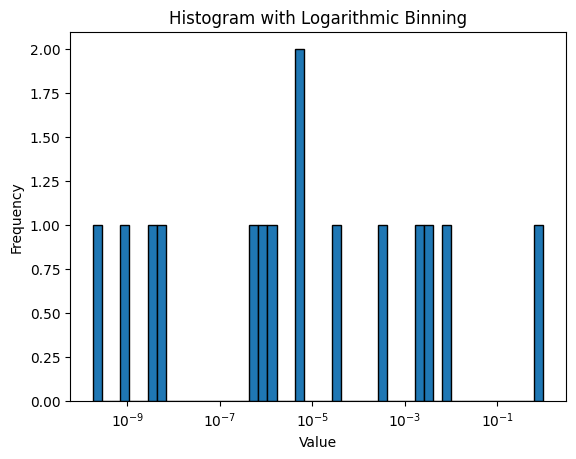

In [37]:
data = np.array(c_sen)
data = data[data > 1e-10]
bins = np.logspace(np.log10(data.min()),
                   np.log10(data.max()),
                   50)

# Plot histogram
plt.hist(data, bins=bins, edgecolor='black')

# Log scale for x-axis (important)
plt.xscale('log')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram with Logarithmic Binning')
plt.show()

In [15]:
HQ = jordan_wigner(H)
for op in sym_ops_all[:14]:
    print(op)
    print(uni_grading([op], HQ))
    probs = find_overlaps([op], fci, 14)
    print(probs, entropy(probs))



1.0 [Z8 Z9]
0.0
[np.complex128(0.999999999999996+0j), np.complex128(1.0471858146218168e-26+0j)] (5.7661677077705765e-15+0j)
1.0 [Z4 Z5 Z12 Z13]
0.0
[np.complex128(0.999999999999996+0j), np.complex128(2.432693728111516e-27+0j)] (5.766167707081891e-15+0j)
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]
0.0
[np.complex128(5.3279609881241306e-27+0j), np.complex128(0.999999999999996+0j)] (5.766167707331833e-15+0j)
1.0 [Z0 Z2 Z5 Z6 Z9 Z10 Z13]
0.0
[np.complex128(7.725180241889396e-27+0j), np.complex128(0.999999999999996+0j)] (5.766167707536918e-15+0j)
1.0 [Z13]
6.802891360112045
[np.complex128(0.9867277187435428+0j), np.complex128(0.013272281256453161+0j)] (0.10177873169697495+0j)
1.0 [Z12]
6.802891360112046
[np.complex128(0.9867277187435425+0j), np.complex128(0.01327228125645348+0j)] (0.1017787316969771+0j)
1.0 [Z11]
8.755568499484163
[np.complex128(0.9867795258835833+0j), np.complex128(0.013220474116412678+0j)] (0.10145654200378104+0j)
1.0 [Z10]
8.755568499484163
[np.complex128(0.9867795258835835+0j), np.com

In [ ]:
#useful functions
from openfermion import commutator
def find_meas_cost(H, symmetries, gs, tol):

    #find significant coeffs and wfn parts

    #find fragments of reduced Hamiltonians and their variances

    #find opt cost

    return

def is_commuting(A, B, tol=1e-5):
    return np.sum(np.abs(commutator(A, B).terms.values())) < tol

def find_clifford_to_Z0(S: QubitOperator):
    """
    Clifford that transforms S to Z0
    
    """
    Z0 = QubitOperator('Z0', 1.0)

    if not is_commuting(S, Z0):
        return (Z0 + S)/np.sqrt(2)

    else:
        #find common anti-commuting operator
        return

In [17]:
sym_ops =  sym_ops_all[:n_qubits//2]
projs = construct_projectors(sym_ops)
projs_sparse = [get_sparse_operator(proj, n_qubits) for proj in projs]
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)
min([get_ground_state(proj @ Hs @ proj)[0] for proj in projs_sparse])

np.float64(-3.1418504961498717)

In [19]:
sym_ops

[1.0 [Z2 Z3 Z6 Z7 Z10 Z11],
 1.0 [Z1 Z3 Z5 Z7 Z9 Z11],
 1.0 [Z0 Z3 Z4 Z7 Z8 Z11],
 1.0 [Z6 Z7 Z8 Z9 Z10 Z11],
 1.0 [Z7 Z9 Z11],
 1.0 [Z4 Z5 Z8 Z9 Z10 Z11]]

In [18]:
sen_syms = [QubitOperator('Z{} Z{}'.format(2*i, 2*i+1), 1) for i in range(n_H)]
projs = construct_projectors(sen_syms)
projs_sparse = [get_sparse_operator(proj, n_qubits) for proj in projs]
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)
min([get_ground_state(proj @ Hs @ proj)[0] for proj in projs_sparse])

np.float64(-3.170861321033622)

In [10]:
projs = construct_projectors(sym_ops_all[:4])
l1_hct, c = find_overlaps_l1(sym_ops_all[:4], fci, n_qubits)
print(l1_hct)
min([get_ground_state(get_sparse_operator(proj * jordan_wigner(H) * proj, n_qubits))[0] for proj in projs])

1.0120323563836673


np.float64(-2.1662150951072685)

In [ ]:
sen_syms = [QubitOperator('Z{} Z{}'.format(2*i, 2*i+1), 1) for i in range(n_H)]
l1_sen, c2 = find_overlaps_l1(sen_syms, fci, n_qubits) #actual goodness
uni_sen = uni_grading(sen_syms, jordan_wigner(H)) #proxy
state_sen = state_grading(sen_syms, jordan_wigner(H), fci, n_qubits) #better proxy
#to check of proxy is positively correlated to actual goodness of symmetries

#doesn't seem very well correlated (test with sym_ops_all[3:7])

print(uni_sen, state_sen, l1_sen)
#np.sort(c2)

11.59420492739591 (1.0572039413412453-1.0408340855860843e-17j) 1.1452346603817158
